<a href="https://colab.research.google.com/github/jejenfel/MACA/blob/main/source_code/MACA_Validation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SENTENCE EMBEDDING

In [ ]:
import pandas as pd
import os # Added for file path checks and directory creation
import zipfile # Added for zip file operations

# Mount Google Drive (if not already mounted)
from google.colab import drive
drive.mount('/content/drive')

# Define dataset paths
CURRICULUM_DATASET_PATH = '/content/drive/MyDrive/TA_Jennifer Felicia/DATASET/KURIKULUM/PROCESSED/'
TRACER_STUDY_DATASET_PATH = '/content/drive/MyDrive/TA_Jennifer Felicia/DATASET/TRACER STUDY/PROCESSED/'
PON_TIK_DICTIONARY_PATH = '/content/drive/MyDrive/TA_Jennifer Felicia/DATASET/Dictionary/PON_TIK/'

# --- Load visi_misi_cleaned.csv ---
df_visi_misi = pd.read_csv(CURRICULUM_DATASET_PATH + 'visi_misi/visi_misi_cleaned.csv')

# --- Load profil_lulusan_cleaned.csv ---
df_profil = pd.read_csv(CURRICULUM_DATASET_PATH + 'profil_lulusan/profil_lulusan_cleaned.csv')

# Combine all text_clean into a single corpus for each document
corpus_visi = ' '.join(df_visi_misi['text_clean'].astype(str))
corpus_profil = ' '.join(df_profil['text_clean'].astype(str))

print("Data loaded and corpus created (initial).")
print("Contoh corpus_visi (100 karakter pertama):", corpus_visi[:100], "...")
print("Contoh corpus_profil (100 karakter pertama):", corpus_profil[:100], "...")

Mounted at /content/drive
Data loaded and corpus created (initial).
Contoh corpus_visi (100 karakter pertama): menjadi program studi informatika unggulan dan pusat pengembangan ilmu pengetahuan teknologi berwawa ...
Contoh corpus_profil (100 karakter pertama): Sarjana Teknik Informatika yang memiliki jiwa dan semangat serta budaya kewirausahaan dengan memanfa ...


In [ ]:
import nltk
# Install NLTK if not already installed (though it's usually pre-installed in Colab)
try:
    # Attempt a basic NLTK import to check if it's available
    from nltk.corpus import stopwords
except ImportError:
    %pip install nltk
    import nltk

# Download necessary NLTK data
# This might take a moment if not already downloaded
# The LookupError indicates these should be downloaded directly.
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab') # Added to fix the LookupError

import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Initialize lemmatizer and stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('indonesian')) # Assuming Indonesian stopwords for context

def clean_text(text):
    if not isinstance(text, str): # Handle non-string types gracefully
        return ""
    text = text.lower()  # Lowercase
    text = re.sub(r'[^a-z\s]', '', text) # Remove punctuation and numbers
    tokens = word_tokenize(text)  # Tokenization
    # Remove stopwords and lemmatize
    cleaned_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(cleaned_tokens)

# Apply cleaning to relevant columns

# Clean Visi (first row)
df_visi_misi.loc[0, 'visi_clean'] = clean_text(df_visi_misi.loc[0, 'text_clean'])

# Clean Misi: apply clean_text to each 'misi' row individually
df_visi_misi.loc[df_visi_misi['kategori'] == 'misi', 'misi_clean'] = df_visi_misi[df_visi_misi['kategori'] == 'misi']['text_clean'].apply(clean_text)

df_profil['profil_clean'] = df_profil['text_clean'].apply(clean_text)

print("Preprocessing complete. Displaying first 5 rows of cleaned data:")
print("\nCleaned Visi:")
display(df_visi_misi[['text_clean', 'visi_clean']].head(1))
print("\nCleaned Misi (each misi row will have its own cleaned text):")
display(df_visi_misi[df_visi_misi['kategori'] == 'misi'][['text_clean', 'misi_clean']].head()) # Show head of misi rows
print("\nCleaned Profil Lulusan:")
display(df_profil[['text_clean', 'profil_clean']].head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Preprocessing complete. Displaying first 5 rows of cleaned data:

Cleaned Visi:


,text_clean,visi_clean
0,menjadi program studi informatika unggulan dan...,program studi informatika unggulan pusat penge...



Cleaned Misi (each misi row will have its own cleaned text):


,text_clean,misi_clean
1,1. menghasilkan lulusan dengan kompetensi yang...,menghasilkan lulusan kompetensi desain aplikas...



Cleaned Profil Lulusan:


,text_clean,profil_clean
0,Sarjana Teknik Informatika yang memiliki jiwa ...,sarjana teknik informatika memiliki jiwa seman...
1,Lulusan yang mengikuti dan memanfaatkan perkem...,lulusan mengikuti memanfaatkan perkembangan te...
2,Profesional unggul yang memiliki etika profesi...,profesional unggul memiliki etika profesi memi...
3,Lulusan yang ahli di bidang bisnis dan teknolo...,lulusan ahli bidang bisnis teknologi informasi...
4,Lulusan yang memiliki kompetensi berstandar na...,lulusan memiliki kompetensi berstandar nasiona...


In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np # Import numpy for array operations

# Initialize TF-IDF Vectorizer
# You might want to adjust parameters like max_features, ngram_range, stop_words, etc.,
# based on your specific needs. For now, a basic setup is used.
vectorizer = TfidfVectorizer()

print("Generating TF-IDF embeddings...")

# Prepare corpus for fitting the vectorizer
visi_text = df_visi_misi.loc[0, 'visi_clean']
misi_texts = df_visi_misi[df_visi_misi['kategori'] == 'misi']['misi_clean'].astype(str).tolist()
profil_texts = df_profil['profil_clean'].astype(str).tolist()

# Combine all texts to fit the vectorizer consistently across the entire corpus
all_texts = [visi_text] + misi_texts + profil_texts

# Fit the vectorizer on the combined corpus and transform
vectorizer.fit(all_texts)

# Generate TF-IDF for Visi
visi_tfidf = vectorizer.transform([visi_text])

# Generate TF-IDF for each Misi statement
misi_tfidf = vectorizer.transform(misi_texts)

# Generate TF-IDF for df_profil
df_profil_tfidf = vectorizer.transform(profil_texts)

print("TF-IDF Embeddings generated successfully.")
print(f"Shape of Visi TF-IDF: {visi_tfidf.shape}")
print(f"Shape of Misi TF-IDF: {misi_tfidf.shape}")
print(f"Shape of profil TF-IDF: {df_profil_tfidf.shape}")

# Convert sparse matrices to dense arrays for consistency with previous output type
visi_tfidf = visi_tfidf.toarray()
misi_tfidf = misi_tfidf.toarray()
df_profil_tfidf = df_profil_tfidf.toarray()

Generating TF-IDF embeddings...
TF-IDF Embeddings generated successfully.
Shape of Visi TF-IDF: (1, 101)
Shape of Misi TF-IDF: (1, 101)
Shape of profil TF-IDF: (5, 101)


In [ ]:
import pandas as pd
# Install sentence-transformers if not already installed
try:
    from sentence_transformers import SentenceTransformer
except ImportError:
    %pip install sentence-transformers
    from sentence_transformers import SentenceTransformer

# Load the Sentence Transformer model
model = SentenceTransformer('all-MiniLM-L6-v2')

print("Generating embeddings...")

# Generate single embedding for Visi (from the first row's 'visi_clean')
visi_text = df_visi_misi.loc[0, 'visi_clean']
visi_embeddings = model.encode([visi_text], show_progress_bar=True)

# Generate embeddings for each Misi statement
misi_embeddings = model.encode(df_visi_misi[df_visi_misi['kategori'] == 'misi']['misi_clean'].astype(str).tolist(), show_progress_bar=True)

# Generate embeddings for other dataframes as before
df_profil_clean_embeddings = model.encode(df_profil['profil_clean'].astype(str).tolist(), show_progress_bar=True)

print("Embeddings generated successfully.")
print(f"Shape of Visi embedding: {visi_embeddings.shape}")
print(f"Shape of Misi embeddings: {misi_embeddings.shape}") # Changed to misi_embeddings
print(f"Shape of profil_clean embeddings: {df_profil_clean_embeddings.shape}")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

Generating embeddings...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Embeddings generated successfully.
Shape of Visi embedding: (1, 384)
Shape of Misi embeddings: (1, 384)
Shape of profil_clean embeddings: (5, 384)


### Menghitung Cosine Similarity

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd

# --- TF-IDF Embeddings (using already generated embeddings from cell 9QHOKksV-fY5) ---
# Directly use the TF-IDF variables that were correctly generated.
v_tfidf_embeddings = visi_tfidf
m_tfidf_embeddings = misi_tfidf
p_tfidf_embeddings = df_profil_tfidf

print("TF-IDF Embeddings loaded successfully.")
print(f"Shape of TF-IDF Visi embedding: {v_tfidf_embeddings.shape}")
print(f"Shape of TF-IDF Misi embeddings: {m_tfidf_embeddings.shape}")
print(f"Shape of TF-IDF Profil embeddings: {p_tfidf_embeddings.shape}")

# --- Sentence Embeddings (using already generated embeddings from cell 8LijY1xH-jPw) ---
# These variables should now correctly hold the Sentence Embeddings from cell 8LijY1xH-jPw
s_visi_embeddings = visi_embeddings
s_misi_embeddings = misi_embeddings
s_profil_embeddings = df_profil_clean_embeddings

print("\nSentence Embeddings loaded successfully.")
print(f"Shape of Sentence Visi embedding: {s_visi_embeddings.shape}")
print(f"Shape of Sentence Misi embeddings: {s_misi_embeddings.shape}")
print(f"Shape of Sentence Profil embeddings: {s_profil_embeddings.shape}")


# --- Prepare combined Visi and Misi data ---
visi_row = df_visi_misi[df_visi_misi['kategori'] == 'visi'].iloc[0]
misi_rows = df_visi_misi[df_visi_misi['kategori'] == 'misi']

all_vm_texts = [visi_row['visi_clean']] + misi_rows['misi_clean'].astype(str).tolist()
all_vm_categories = [visi_row['kategori']] + misi_rows['kategori'].tolist()

# Combine TF-IDF embeddings for Visi and Misi
combined_tfidf_embeddings = np.vstack([v_tfidf_embeddings, m_tfidf_embeddings])

# Combine Sentence Embeddings for Visi and Misi
combined_sbert_embeddings = np.vstack([s_visi_embeddings, s_misi_embeddings])


# --- Calculate Cosine Similarity (TF-IDF) for combined Visi/Misi vs Profil ---
print("\nCalculating Cosine Similarity using TF-IDF Embeddings (Visi/Misi vs Profil Lulusan):")

combined_tfidf_similarity_matrix = cosine_similarity(combined_tfidf_embeddings, p_tfidf_embeddings)

# Create DataFrame for combined Visi/Misi TF-IDF vs Profil TF-IDF
profil_lulusan_texts = df_profil['profil_clean'].tolist()
profil_lulusan_codes = df_profil['kode_profil_lulusan'].tolist()

combined_vm_tfidf_data = []
for i, vm_text in enumerate(all_vm_texts):
    for j, profil_text in enumerate(profil_lulusan_texts):
        combined_vm_tfidf_data.append({
            'Kategori': all_vm_categories[i],
            'Statement Text': vm_text,
            'Kode Profil Lulusan': profil_lulusan_codes[j],
            'Profil Lulusan Text': profil_text,
            'TF-IDF Similarity': combined_tfidf_similarity_matrix[i, j].round(4)
        })
df_tfidf_vm_profil_sim = pd.DataFrame(combined_vm_tfidf_data)
print("  Cosine Similarity (TF-IDF) between Visi/Misi and each Profil Lulusan:")
display(df_tfidf_vm_profil_sim)

# Statistics for combined TF-IDF Visi/Misi vs Profil Lulusan
tfidf_vm_profil_scores = df_tfidf_vm_profil_sim['TF-IDF Similarity']
print(f"    Mean: {np.round(np.mean(tfidf_vm_profil_scores), 4)}")
print(f"    Median: {np.round(np.median(tfidf_vm_profil_scores), 4)}")
print(f"    Min: {np.round(np.min(tfidf_vm_profil_scores), 4)}")
print(f"    Max: {np.round(np.max(tfidf_vm_profil_scores), 4)}")
print(f"    Std: {np.round(np.std(tfidf_vm_profil_scores), 4)}")


# --- Calculate Cosine Similarity (Sentence Embeddings) for combined Visi/Misi vs Profil ---
print("\nCalculating Cosine Similarity using Sentence Embeddings (Visi/Misi vs Profil Lulusan):")

combined_sbert_similarity_matrix = cosine_similarity(combined_sbert_embeddings, s_profil_embeddings)

# Create DataFrame for combined Visi/Misi Sentence vs Profil Sentence
combined_vm_sbert_data = []
for i, vm_text in enumerate(all_vm_texts):
    for j, profil_text in enumerate(profil_lulusan_texts):
        combined_vm_sbert_data.append({
            'Kategori': all_vm_categories[i],
            'Statement Text': vm_text,
            'Kode Profil Lulusan': profil_lulusan_codes[j],
            'Profil Lulusan Text': profil_text,
            'SBERT Similarity': combined_sbert_similarity_matrix[i, j].round(4)
        })
df_sbert_vm_profil_sim = pd.DataFrame(combined_vm_sbert_data)
print("  Cosine Similarity (Sentence) between Visi/Misi and each Profil Lulusan:")
display(df_sbert_vm_profil_sim)

# Statistics for combined Sentence Visi/Misi vs Profil Lulusan
sbert_vm_profil_scores = df_sbert_vm_profil_sim['SBERT Similarity']
print(f"    Mean: {np.round(np.mean(sbert_vm_profil_scores), 4)}")
print(f"    Median: {np.round(np.median(sbert_vm_profil_scores), 4)}")
print(f"    Min: {np.round(np.min(sbert_vm_profil_scores), 4)}")
print(f"    Max: {np.round(np.max(sbert_vm_profil_scores), 4)}")
print(f"    Std: {np.round(np.std(sbert_vm_profil_scores), 4)}")

TF-IDF Embeddings loaded successfully.
Shape of TF-IDF Visi embedding: (1, 101)
Shape of TF-IDF Misi embeddings: (1, 101)
Shape of TF-IDF Profil embeddings: (5, 101)

Sentence Embeddings loaded successfully.
Shape of Sentence Visi embedding: (1, 384)
Shape of Sentence Misi embeddings: (1, 384)
Shape of Sentence Profil embeddings: (5, 384)

Calculating Cosine Similarity using TF-IDF Embeddings (Visi/Misi vs Profil Lulusan):
  Cosine Similarity (TF-IDF) between Visi/Misi and each Profil Lulusan:


,Kategori,Statement Text,Kode Profil Lulusan,Profil Lulusan Text,TF-IDF Similarity
0,visi,program studi informatika unggulan pusat penge...,PL1,sarjana teknik informatika memiliki jiwa seman...,0.1759
1,visi,program studi informatika unggulan pusat penge...,PL2,lulusan mengikuti memanfaatkan perkembangan te...,0.0595
2,visi,program studi informatika unggulan pusat penge...,PL3,profesional unggul memiliki etika profesi memi...,0.0858
3,visi,program studi informatika unggulan pusat penge...,PL4,lulusan ahli bidang bisnis teknologi informasi...,0.0555
4,visi,program studi informatika unggulan pusat penge...,PL5,lulusan memiliki kompetensi berstandar nasiona...,0.0000
5,misi,menghasilkan lulusan kompetensi desain aplikas...,PL1,sarjana teknik informatika memiliki jiwa seman...,0.1764
6,misi,menghasilkan lulusan kompetensi desain aplikas...,PL2,lulusan mengikuti memanfaatkan perkembangan te...,0.1101
7,misi,menghasilkan lulusan kompetensi desain aplikas...,PL3,profesional unggul memiliki etika profesi memi...,0.0817
8,misi,menghasilkan lulusan kompetensi desain aplikas...,PL4,lulusan ahli bidang bisnis teknologi informasi...,0.0971
9,misi,menghasilkan lulusan kompetensi desain aplikas...,PL5,lulusan memiliki kompetensi berstandar nasiona...,0.2651


    Mean: 0.1107
    Median: 0.0914
    Min: 0.0
    Max: 0.2651
    Std: 0.0721

Calculating Cosine Similarity using Sentence Embeddings (Visi/Misi vs Profil Lulusan):
  Cosine Similarity (Sentence) between Visi/Misi and each Profil Lulusan:


,Kategori,Statement Text,Kode Profil Lulusan,Profil Lulusan Text,SBERT Similarity
0,visi,program studi informatika unggulan pusat penge...,PL1,sarjana teknik informatika memiliki jiwa seman...,0.7664
1,visi,program studi informatika unggulan pusat penge...,PL2,lulusan mengikuti memanfaatkan perkembangan te...,0.7783
2,visi,program studi informatika unggulan pusat penge...,PL3,profesional unggul memiliki etika profesi memi...,0.4686
3,visi,program studi informatika unggulan pusat penge...,PL4,lulusan ahli bidang bisnis teknologi informasi...,0.4910
4,visi,program studi informatika unggulan pusat penge...,PL5,lulusan memiliki kompetensi berstandar nasiona...,0.3496
5,misi,menghasilkan lulusan kompetensi desain aplikas...,PL1,sarjana teknik informatika memiliki jiwa seman...,0.7102
6,misi,menghasilkan lulusan kompetensi desain aplikas...,PL2,lulusan mengikuti memanfaatkan perkembangan te...,0.7575
7,misi,menghasilkan lulusan kompetensi desain aplikas...,PL3,profesional unggul memiliki etika profesi memi...,0.5675
8,misi,menghasilkan lulusan kompetensi desain aplikas...,PL4,lulusan ahli bidang bisnis teknologi informasi...,0.5474
9,misi,menghasilkan lulusan kompetensi desain aplikas...,PL5,lulusan memiliki kompetensi berstandar nasiona...,0.5260


    Mean: 0.5961999893188477
    Median: 0.5573999881744385
    Min: 0.3496
    Max: 0.7783
    Std: 0.1405


In [ ]:
# ==========================================================
# Tabel Paired Similarity Scores
# TF-IDF vs Sentence Embedding
# ==========================================================

import pandas as pd
import numpy as np

# ==========================================================
# Prepare Paired Scores
# ==========================================================

tfidf_scores = (
    df_tfidf_vm_profil_sim["TF-IDF Similarity"]
    .values
)

sbert_scores = (
    df_sbert_vm_profil_sim["SBERT Similarity"]
    .values
)

# ==========================================================
# Create Comparison Table
# ==========================================================

df_wilcoxon_pairs = pd.DataFrame({
    "Pair": range(1, len(tfidf_scores) + 1),
    "TF-IDF Similarity": tfidf_scores,
    "SBERT Similarity": sbert_scores
})

# Difference: SBERT - TF-IDF
df_wilcoxon_pairs["Difference"] = (
    df_wilcoxon_pairs["SBERT Similarity"]
    - df_wilcoxon_pairs["TF-IDF Similarity"]
)

# ==========================================================
# Determine Direction
# ==========================================================

df_wilcoxon_pairs["Direction"] = np.where(
    df_wilcoxon_pairs["Difference"] > 0,
    "SBERT > TF-IDF",
    np.where(
        df_wilcoxon_pairs["Difference"] < 0,
        "TF-IDF > SBERT",
        "Equal"
    )
)

# ==========================================================
# Absolute Difference
# Used for Wilcoxon ranking
# ==========================================================

df_wilcoxon_pairs["Absolute Difference"] = (
    df_wilcoxon_pairs["Difference"].abs()
)

# ==========================================================
# Display
# ==========================================================

display(
    df_wilcoxon_pairs.round(4)
)

,Pair,TF-IDF Similarity,SBERT Similarity,Difference,Direction,Absolute Difference
0,1,0.1759,0.7664,0.5905,SBERT > TF-IDF,0.5905
1,2,0.0595,0.7783,0.7188,SBERT > TF-IDF,0.7188
2,3,0.0858,0.4686,0.3828,SBERT > TF-IDF,0.3828
3,4,0.0555,0.4910,0.4355,SBERT > TF-IDF,0.4355
4,5,0.0000,0.3496,0.3496,SBERT > TF-IDF,0.3496
5,6,0.1764,0.7102,0.5338,SBERT > TF-IDF,0.5338
6,7,0.1101,0.7575,0.6474,SBERT > TF-IDF,0.6474
7,8,0.0817,0.5675,0.4858,SBERT > TF-IDF,0.4858
8,9,0.0971,0.5474,0.4503,SBERT > TF-IDF,0.4503
9,10,0.2651,0.5260,0.2609,SBERT > TF-IDF,0.2609


In [ ]:
# ==========================================================
# Wilcoxon Signed-Rank Test
# TF-IDF vs Sentence Embedding Similarity
# ==========================================================

from scipy.stats import wilcoxon


# ==========================================================
# Prepare Paired Similarity Scores
# ==========================================================

tfidf_scores = (
    df_tfidf_vm_profil_sim["TF-IDF Similarity"]
    .values
)

sbert_scores = (
    df_sbert_vm_profil_sim["SBERT Similarity"]
    .values
)


print("Number of paired observations:")
print(len(tfidf_scores))


# ==========================================================
# Wilcoxon Signed-Rank Test
# ==========================================================

statistic, p_value = wilcoxon(
    tfidf_scores,
    sbert_scores,
    alternative="two-sided"
)


# ==========================================================
# Result Summary
# ==========================================================

alpha = 0.05


wilcoxon_result = pd.DataFrame({

    "Test": [
        "Wilcoxon Signed-Rank Test"
    ],

    "Statistic": [
        statistic
    ],

    "p-value": [
        p_value
    ],

    "Significance Level": [
        alpha
    ],

    "Decision": [
        "Reject H0"
        if p_value < alpha
        else "Fail to Reject H0"
    ]

})


display(
    wilcoxon_result.round(4)
)

if p_value < alpha:

    print(
        "H0 ditolak."
    )

    print(
        "Terdapat perbedaan signifikan antara TF-IDF dan Sentence Embedding."
    )

else:

    print(
        "H0 gagal ditolak."
    )

    print(
        "Tidak terdapat perbedaan signifikan antara TF-IDF dan Sentence Embedding."
    )

Number of paired observations:
10


,Test,Statistic,p-value,Significance Level,Decision
0,Wilcoxon Signed-Rank Test,0.0,0.002,0.05,Reject H0


H0 ditolak.
Terdapat perbedaan signifikan antara TF-IDF dan Sentence Embedding.


In [ ]:
# ==========================================================
# Wilcoxon Ranking Table
# ==========================================================

df_wilcoxon_pairs["Rank"] = (
    df_wilcoxon_pairs["Absolute Difference"]
    .rank(method="average")
)

df_wilcoxon_pairs["Signed Rank"] = np.where(
    df_wilcoxon_pairs["Difference"] > 0,
    df_wilcoxon_pairs["Rank"],
    np.where(
        df_wilcoxon_pairs["Difference"] < 0,
        -df_wilcoxon_pairs["Rank"],
        0
    )
)

display(
    df_wilcoxon_pairs.round(4)
)

,Pair,TF-IDF Similarity,SBERT Similarity,Difference,Direction,Absolute Difference,Rank,Signed Rank
0,1,0.1759,0.7664,0.5905,SBERT > TF-IDF,0.5905,8.0,8.0
1,2,0.0595,0.7783,0.7188,SBERT > TF-IDF,0.7188,10.0,10.0
2,3,0.0858,0.4686,0.3828,SBERT > TF-IDF,0.3828,3.0,3.0
3,4,0.0555,0.4910,0.4355,SBERT > TF-IDF,0.4355,4.0,4.0
4,5,0.0000,0.3496,0.3496,SBERT > TF-IDF,0.3496,2.0,2.0
5,6,0.1764,0.7102,0.5338,SBERT > TF-IDF,0.5338,7.0,7.0
6,7,0.1101,0.7575,0.6474,SBERT > TF-IDF,0.6474,9.0,9.0
7,8,0.0817,0.5675,0.4858,SBERT > TF-IDF,0.4858,6.0,6.0
8,9,0.0971,0.5474,0.4503,SBERT > TF-IDF,0.4503,5.0,5.0
9,10,0.2651,0.5260,0.2609,SBERT > TF-IDF,0.2609,1.0,1.0


### Visualisasi Cosine Similarity menggunakan Heatmap

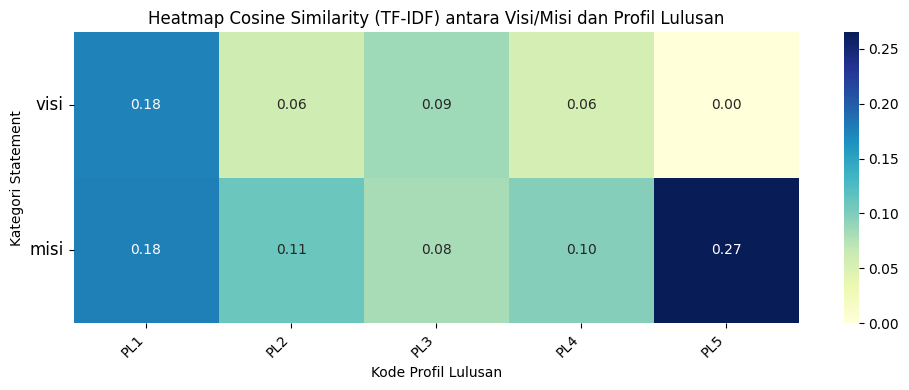

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Heatmap for TF-IDF Visi/Misi vs Profil Lulusan ---
plt.figure(figsize=(10, 4)) # Significantly increased figure width for very long labels
sns.heatmap(
    combined_tfidf_similarity_matrix,
    annot=True,
    cmap='YlGnBu',
    fmt=".2f",
    xticklabels=profil_lulusan_codes,
    yticklabels=all_vm_categories # Changed to display categories for Visi/Misi
)
plt.title('Heatmap Cosine Similarity (TF-IDF) antara Visi/Misi dan Profil Lulusan')
plt.xlabel('Kode Profil Lulusan') # Changed label for clarity
plt.ylabel('Kategori Statement') # Changed label for clarity
plt.xticks(rotation=45, ha='right', fontsize=10) # Increased x-axis font size
plt.yticks(rotation=0, fontsize=12) # Increased y-axis font size
plt.tight_layout()
plt.show()

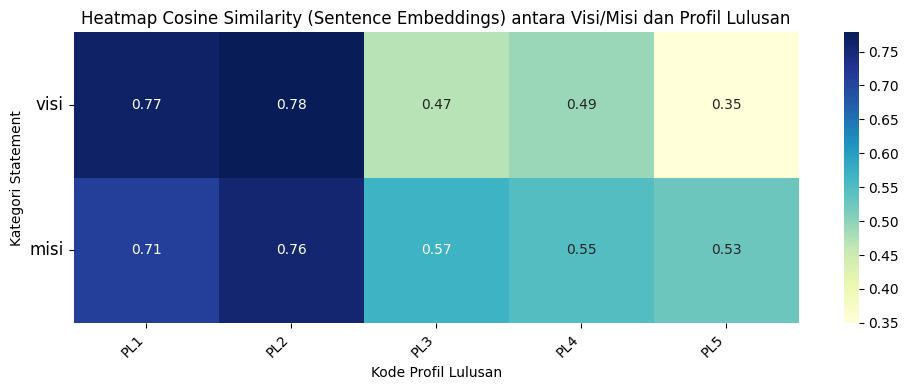

In [ ]:
# --- Heatmap for Sentence Embeddings Visi/Misi vs Profil Lulusan ---
plt.figure(figsize=(10, 4)) # Significantly increased figure width for very long labels
sns.heatmap(
    combined_sbert_similarity_matrix,
    annot=True,
    cmap='YlGnBu',
    fmt=".2f",
    xticklabels=profil_lulusan_codes,
    yticklabels=all_vm_categories # Changed to display categories for Visi/Misi
)
plt.title('Heatmap Cosine Similarity (Sentence Embeddings) antara Visi/Misi dan Profil Lulusan')
plt.xlabel('Kode Profil Lulusan') # Changed label for clarity
plt.ylabel('Kategori Statement') # Changed label for clarity
plt.xticks(rotation=45, ha='right', fontsize=10) # Increased x-axis font size
plt.yticks(rotation=0, fontsize=12) # Increased y-axis font size
plt.tight_layout()
plt.show()

# CLUSTERING VALIDATION

In [ ]:
import pandas as pd
import os # Added for file path checks and directory creation
import zipfile # Added for zip file operations

# Mount Google Drive (if not already mounted)
from google.colab import drive
drive.mount('/content/drive')

# Define dataset paths
K_MEANS_PATH = '/content/drive/MyDrive/TA_Jennifer Felicia/DATASET/Dictionary/PON_TIK/CLUSTERING_OUTPUT/'
AGGLOMERATIVE_PATH = '/content/drive/MyDrive/TA_Jennifer Felicia/DATASET/Dictionary/PON_TIK/AGGLOMERATIVE_CLUSTERING_OUTPUT/'
PONTIK_PATH = '/content/drive/MyDrive/TA_Jennifer Felicia/DATASET/Dictionary/PON_TIK/'

# --- Load tracer_study_cleaned.csv ---
df_kmeans = pd.read_csv(K_MEANS_PATH + 'df_okupasi_with_domains.csv')
df_agglomerative = pd.read_csv(AGGLOMERATIVE_PATH + 'pon_tik_labeled.csv')
df_groundtruth_kmeans = pd.read_csv(PONTIK_PATH + 'pon_tik_occupations_ground_truth.csv')

Mounted at /content/drive


In [ ]:
print(df_kmeans.columns)
print(df_agglomerative.columns)

Index(['code', 'definisi', 'kualifikasi', 'lingkup_bidang_pekerjaan', 'profil',
       'tanggung_jawab', 'wewenang', 'persyaratan', 'tugas_utama',
       'tugas_khusus', 'title', 'occupation_text', 'occupation_clean',
       'occupation_skills', 'skill_cluster', 'occupation_domain',
       'occupation_skills_embedding'],
      dtype='object')
Index(['occupation_id', 'occupation_name', 'competency_unit', 'cleaned_text',
       'embedding', 'cluster', 'cluster_0.3', 'cluster_0.4', 'cluster_0.45',
       'cluster_0.5', 'cluster_0.55', 'cluster_0.6', 'cluster_0.7',
       'cluster_0.8', 'cluster_0.85', 'cluster_0.9', 'cluster_1.0',
       'skill_category'],
      dtype='object')


## K-Means Clustering

In [ ]:
print(type(df_kmeans["occupation_skills_embedding"].iloc[0]))

print(df_kmeans["occupation_skills_embedding"].iloc[0])

<class 'str'>
[-0.00814255140721798, 0.020688626915216446, -0.07831616699695587, -0.06042412295937538, -0.0562877431511879, -0.026106957346200943, -0.002509154612198472, 0.018426083028316498, -0.017811667174100876, 0.05394347384572029, 0.03197193890810013, -0.08904391527175903, 0.016573872417211533, -0.012648174539208412, 0.00040637049823999405, 0.02767343260347843, 0.0039567905478179455, 0.023912491276860237, 0.005322478711605072, -0.14450214803218842, 0.01627339981496334, -0.03218185156583786, -0.005485315341502428, 0.009846105240285397, 0.01780562475323677, 0.08075345307588577, 0.006898296065628529, -0.050399959087371826, 0.05962541326880455, -0.08687949925661087, -0.07616528123617172, 0.06951786577701569, 0.07509931921958923, 0.062445610761642456, 0.02831563912332058, 0.10441416501998901, -0.07133730500936508, 0.0032908048015087843, 0.050721101462841034, -0.060484353452920914, -0.08790774643421173, -0.035719145089387894, -0.012933967635035515, -0.07321728020906448, 0.08554624021053

### Silhuette

In [ ]:
# ==========================================================
# K-MEANS SILHOUETTE SCORE EVALUATION
# ==========================================================

import numpy as np
import pandas as pd
import ast

from sklearn.metrics import (
    silhouette_score,
    silhouette_samples
)


# ==========================================================
# Prepare Embedding and Cluster Label
# ==========================================================

df_kmeans["occupation_skills_embedding"] = df_kmeans["occupation_skills_embedding"].apply(
    lambda x: np.array(ast.literal_eval(x))
    if isinstance(x, str)
    else np.array(x)
)

X_embedding = np.vstack(
    df_kmeans["occupation_skills_embedding"].values
)

print(
    X_embedding.shape
)

cluster_labels = df_kmeans["skill_cluster"].values


print("Embedding Shape :", X_embedding.shape)
print(
    "Number of Cluster :",
    len(np.unique(cluster_labels))
)


# ==========================================================
# Overall Silhouette Score
# ==========================================================

silhouette_kmeans = silhouette_score(
    X_embedding,
    cluster_labels,
    metric="cosine"
)


print(
    f"\nOverall Silhouette Score: {silhouette_kmeans:.4f}"
)


# ==========================================================
# Silhouette Score per Cluster
# ==========================================================

sample_silhouette = silhouette_samples(
    X_embedding,
    cluster_labels,
    metric="cosine"
)


df_silhouette = pd.DataFrame({

    "skill_cluster": cluster_labels,

    "silhouette_score": sample_silhouette

})


cluster_silhouette_summary = (
    df_silhouette
    .groupby("skill_cluster")
    .agg(
        total_member=(
            "skill_cluster",
            "count"
        ),

        mean_silhouette=(
            "silhouette_score",
            "mean"
        ),

        min_silhouette=(
            "silhouette_score",
            "min"
        ),

        max_silhouette=(
            "silhouette_score",
            "max"
        )
    )
    .reset_index()
)


print("\nSilhouette Score per Cluster")

display(
    cluster_silhouette_summary.round(4)
)

(269, 384)
Embedding Shape : (269, 384)
Number of Cluster : 6

Overall Silhouette Score: 0.1185

Silhouette Score per Cluster


,skill_cluster,total_member,mean_silhouette,min_silhouette,max_silhouette
0,0,58,-0.0285,-0.1839,0.0889
1,1,77,0.0605,-0.1578,0.2369
2,2,38,0.0214,-0.1725,0.2150
3,3,13,0.5605,0.2588,0.6786
4,4,54,0.1760,-0.0601,0.3802
5,5,29,0.3888,0.1530,0.5484


### DBI

In [ ]:
import ast
import numpy as np
from sklearn.metrics import davies_bouldin_score

def parse_embedding(column):
    """
    Mengubah embedding yang tersimpan sebagai string/list
    menjadi numpy array (n_samples, embedding_dim)
    """

    embeddings = []

    for emb in column:

        # Jika embedding masih berupa string
        if isinstance(emb, str):
            emb = ast.literal_eval(emb)

        embeddings.append(np.array(emb, dtype=float))

    return np.vstack(embeddings)

    # Feature matrix
X_kmeans = parse_embedding(
    df_kmeans["occupation_skills_embedding"]
)

# Cluster labels
labels_kmeans = df_kmeans["skill_cluster"]

# Hitung DBI
dbi_kmeans = davies_bouldin_score(
    X_kmeans,
    labels_kmeans
)

print(f"K-Means Davies-Bouldin Index : {dbi_kmeans:.4f}")

K-Means Davies-Bouldin Index : 2.9979


In [ ]:
# ==========================================================
# K-Means - Global Clustering Validation
# ==========================================================

df_kmeans_validation = pd.DataFrame({
    "Metric": [
        "Silhouette Score",
        "Davies-Bouldin Index"
    ],
    "Value": [
        silhouette_kmeans,
        dbi_kmeans
    ]
})

display(df_kmeans_validation)

,Metric,Value
0,Silhouette Score,0.118539
1,Davies-Bouldin Index,2.997912


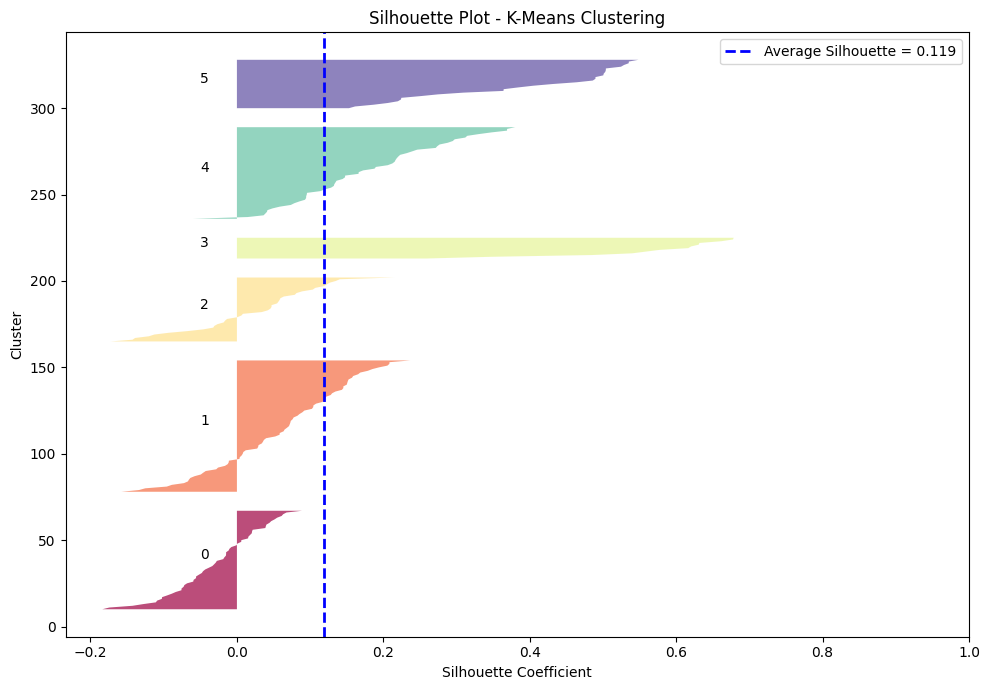

In [ ]:
# ==========================================================
# SILHOUETTE PLOT - K-MEANS
# ==========================================================

import matplotlib.pyplot as plt
import matplotlib.cm as cm # Import colormap module

plt.figure(figsize=(10, 7))

y_lower = 10

unique_clusters = np.sort(
    np.unique(cluster_labels)
)

# Prepare colormap for clusters
colors = cm.Spectral(np.linspace(0, 1, len(unique_clusters)))

for i, cluster_id in enumerate(unique_clusters):

    # Ambil silhouette score untuk cluster tertentu
    cluster_values = sample_silhouette[
        cluster_labels == cluster_id
    ]

    # Urutkan dari kecil ke besar
    cluster_values.sort()

    cluster_size = len(cluster_values)

    y_upper = y_lower + cluster_size

    # Plot silhouette values dengan warna dari colormap
    plt.fill_betweenx(
        np.arange(
            y_lower,
            y_upper
        ),
        0,
        cluster_values,
        facecolor=colors[i], # Assign a unique color to each cluster
        alpha=0.7
    )

    # Label cluster
    plt.text(
        -0.05,
        y_lower + 0.5 * cluster_size,
        str(cluster_id)
    )

    y_lower = y_upper + 10


# ==========================================================
# Average Silhouette Line
# ==========================================================

plt.axvline(
    silhouette_kmeans,
    linestyle="--",
    linewidth=2,
    color='blue', # Keep average line a distinct color
    label=(
        f"Average Silhouette = "
        f"{silhouette_kmeans:.3f}"
    )
)

# ==========================================================
# Plot Settings
# ==========================================================

plt.xlabel("Silhouette Coefficient")
plt.ylabel("Cluster")

plt.title(
    "Silhouette Plot - K-Means Clustering"
)

plt.legend()

plt.xlim(
    min(
        -0.1,
        sample_silhouette.min() - 0.05
    ),
    1
)

plt.tight_layout()

plt.show()

In [ ]:
# ==========================================================
# PCA 2D VISUALIZATION - K-MEANS
# ==========================================================

from sklearn.decomposition import PCA

pca = PCA(
    n_components=2,
    random_state=42
)

X_pca = pca.fit_transform(
    X_embedding
)

print(
    "PCA Explained Variance Ratio:",
    pca.explained_variance_ratio_
)

print(
    "Total Explained Variance:",
    pca.explained_variance_ratio_.sum()
)

PCA Explained Variance Ratio: [0.11022126 0.08438643]
Total Explained Variance: 0.19460768890338603


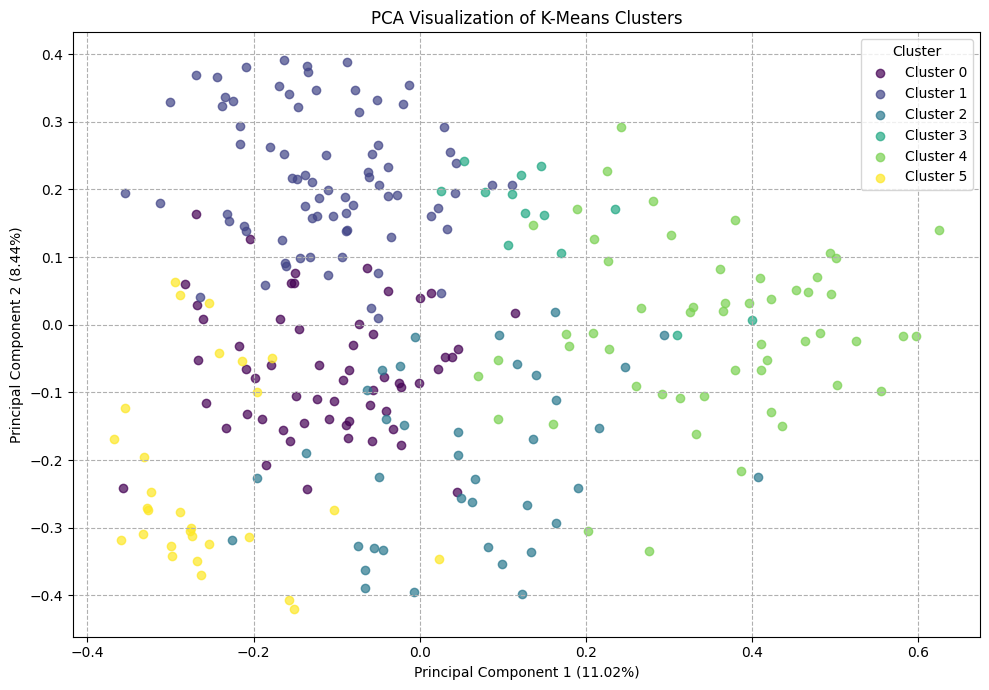

In [ ]:
import matplotlib.cm as cm # Import colormap module

plt.figure(figsize=(10, 7))

# Prepare colormap for clusters, ensuring it's available for this cell
# Re-initialize colors based on unique_clusters, assuming unique_clusters is available from previous cells
colors = cm.viridis(np.linspace(0, 1, len(unique_clusters))) # Changed colormap to viridis for better contrast

for i, cluster_id in enumerate(unique_clusters):

    mask = (
        cluster_labels == cluster_id
    )

    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=f"Cluster {cluster_id}",
        color=colors[i], # Assign a unique color to each cluster
        alpha=0.7
    )

plt.xlabel(
    f"Principal Component 1 "
    f"({pca.explained_variance_ratio_[0] * 100:.2f}%)"
)

plt.ylabel(
    f"Principal Component 2 "
    f"({pca.explained_variance_ratio_[1] * 100:.2f}%)"
)

plt.title(
    "PCA Visualization of K-Means Clusters"
)

plt.legend(
    title="Cluster"
)

plt.grid(linestyle='--') # Changed grid to dashed lines
plt.tight_layout()

plt.show()

### Entropy

In [ ]:
import pandas as pd
import numpy as np


# ==========================================================
# Merge Ground Truth dan K-Means Result
# ==========================================================

df_eval_kmeans = df_kmeans.merge(
    df_groundtruth_kmeans[
        [
            "code",
            "occupation_group"
        ]
    ],
    on="code",
    how="inner"
)


print("Jumlah data evaluasi:", len(df_eval_kmeans))


df_eval_kmeans[
    [
        "code",
        "title",
        "occupation_group",
        "skill_cluster"
    ]
].head()

Jumlah data evaluasi: 269


,code,title,occupation_group,skill_cluster
0,TIK.ITG0901,PEMIMPIN INFORMASI (CHIEF INFORMATION OFFICER),IT Governance,0
1,TIK.ITG0902,PEMIMPIN KEPATUHAN (CHIEF COMPLIANCE OFFICER (...,IT Governance,0
2,TIK.ITG0801,KEPALA ARSITEKTUR PERUSAHAAN (LEAD ENTERPRISE ...,IT Governance,0
3,TIK.ITG0802,KEPALA PENASIHAT TI (LEAD IT ADVISOR),IT Governance,1
4,TIK.ITG0803,KEPALA MANAJEMEN PROGRAM (LEAD PROGRAM MANAGEM...,IT Governance,0


In [ ]:
# ==========================================================
# Shannon Entropy Function
# ==========================================================

def shannon_entropy(labels):
    """
    Menghitung entropy berdasarkan distribusi label
    """

    values, counts = np.unique(
        labels,
        return_counts=True
    )

    probabilities = counts / counts.sum()

    entropy = -np.sum(
        probabilities * np.log2(probabilities)
    )

    return entropy

# ==========================================================
# Entropy per K-Means Cluster
# ==========================================================

entropy_results = []


for cluster_id, group in df_eval_kmeans.groupby(
    "skill_cluster"
):

    entropy = shannon_entropy(
        group["occupation_group"]
    )


    entropy_results.append(
        {
            "skill_cluster": cluster_id,
            "total_member": len(group),
            "entropy": entropy,
            "unique_groundtruth":
                group["occupation_group"].nunique()
        }
    )


df_entropy = pd.DataFrame(
    entropy_results
)


display(df_entropy)

# ==========================================================
# Weighted Average Entropy
# ==========================================================

overall_entropy = (
    df_entropy["entropy"] *
    df_entropy["total_member"]
).sum() / df_entropy["total_member"].sum()


print(
    f"Overall Shannon Entropy: {overall_entropy:.4f}"
)

,skill_cluster,total_member,entropy,unique_groundtruth
0,0,58,2.143639,6
1,1,77,2.346295,6
2,2,38,1.967903,5
3,3,13,0.995727,2
4,4,54,2.105758,6
5,5,29,0.574828,3


Overall Shannon Entropy: 1.9446


In [ ]:
# ==========================================================
# NORMALIZED SHANNON ENTROPY EVALUATION - KMEANS
# ==========================================================

import pandas as pd
import numpy as np


# ==========================================================
# 1. Merge Ground Truth dan Hasil K-Means
# ==========================================================

df_eval_kmeans = df_kmeans.merge(
    df_groundtruth_kmeans[
        [
            "code",
            "occupation_group"
        ]
    ],
    on="code",
    how="inner"
)


print("Jumlah data evaluasi :", len(df_eval_kmeans))


# ==========================================================
# 2. Shannon Entropy Function
# ==========================================================

def shannon_entropy(labels):

    values, counts = np.unique(
        labels,
        return_counts=True
    )

    probabilities = counts / counts.sum()

    entropy = -np.sum(
        probabilities * np.log2(probabilities)
    )

    return entropy



# ==========================================================
# 3. Hitung Entropy dan Normalized Entropy per Cluster
# ==========================================================

entropy_results = []


# jumlah kategori ground truth global
num_classes = (
    df_eval_kmeans["occupation_group"]
    .nunique()
)


max_entropy = np.log2(num_classes)



for cluster_id, group in df_eval_kmeans.groupby(
    "skill_cluster"
):

    entropy = shannon_entropy(
        group["occupation_group"]
    )


    normalized_entropy = (
        entropy / max_entropy
        if max_entropy > 0
        else 0
    )


    entropy_results.append(
        {
            "skill_cluster": cluster_id,
            "total_member": len(group),
            "num_groundtruth_category":
                group["occupation_group"].nunique(),
            "entropy": entropy,
            "normalized_entropy":
                normalized_entropy
        }
    )


df_entropy = pd.DataFrame(
    entropy_results
)


# urutkan cluster
df_entropy = (
    df_entropy
    .sort_values("skill_cluster")
    .reset_index(drop=True)
)



# ==========================================================
# 4. Overall Weighted Normalized Entropy
# ==========================================================

overall_entropy = (
    df_entropy["entropy"] *
    df_entropy["total_member"]
).sum() / df_entropy["total_member"].sum()


overall_normalized_entropy = (
    overall_entropy / max_entropy
)



# ==========================================================
# 5. Display Result
# ==========================================================

print("\n===== CLUSTER ENTROPY RESULT =====")

display(df_entropy)


print("\n===== OVERALL RESULT =====")

summary_entropy = pd.DataFrame(
    {
        "Metric": [
            "Number of Cluster",
            "Number of Ground Truth Category",
            "Maximum Entropy",
            "Overall Shannon Entropy",
            "Overall Normalized Entropy"
        ],

        "Value": [
            df_eval_kmeans["skill_cluster"].nunique(),
            num_classes,
            round(max_entropy,4),
            round(overall_entropy,4),
            round(overall_normalized_entropy,4)
        ]
    }
)


display(summary_entropy)

Jumlah data evaluasi : 269

===== CLUSTER ENTROPY RESULT =====


,skill_cluster,total_member,num_groundtruth_category,entropy,normalized_entropy
0,0,58,6,2.143639,0.829273
1,1,77,6,2.346295,0.907671
2,2,38,5,1.967903,0.761289
3,3,13,2,0.995727,0.385200
4,4,54,6,2.105758,0.814618
5,5,29,3,0.574828,0.222374



===== OVERALL RESULT =====


,Metric,Value
0,Number of Cluster,6.0000
1,Number of Ground Truth Category,6.0000
2,Maximum Entropy,2.5850
3,Overall Shannon Entropy,1.9446
4,Overall Normalized Entropy,0.7523


In [ ]:
# ==========================================================
# K-Means - Global Clustering Validation
# ==========================================================

df_kmeans_validation = pd.DataFrame({
    "Metric": [
        "Silhouette Score",
        "Davies-Bouldin Index"
    ],
    "Value": [
        silhouette_kmeans,
        dbi_kmeans
    ]
})

display(df_kmeans_validation)

,Metric,Value
0,Silhouette Score,0.118539
1,Davies-Bouldin Index,2.997912


## Agglomerative Clustering

### Silhouette

In [ ]:
# ==========================================================
# AGGLOMERATIVE CLUSTERING LOSS FUNCTION
# Silhouette Score (Internal Evaluation)
# ==========================================================
import ast
import numpy as np
from sklearn.metrics import silhouette_score, silhouette_samples

def convert_embedding(x):
    if isinstance(x, str):
        # hapus tanda kurung siku
        x = x.replace("[", "").replace("]", "")

        # ubah string menjadi array float
        return np.fromstring(x, sep=" ")

    return np.array(x)


df_agglomerative["embedding"] = df_agglomerative["embedding"].apply(
    convert_embedding
)


# cek hasil
print(type(df_agglomerative["embedding"].iloc[0]))
print(df_agglomerative["embedding"].iloc[0][:5])


# ==========================================================
# Prepare Matrix
# ==========================================================

X_embedding = np.vstack(
    df_agglomerative["embedding"].values
)


cluster_labels = df_agglomerative["cluster_0.5"].values


print("Embedding shape:", X_embedding.shape)
print("Embedding dtype:", X_embedding.dtype)
print("Cluster:", np.unique(cluster_labels))


# ==========================================================
# Silhouette Score
# ==========================================================

silhouette_agg = silhouette_score(
    X_embedding,
    cluster_labels,
    metric="cosine"
)


print("\n=== Silhouette Score ===")
print(f"Silhouette Score : {silhouette_agg:.4f}")

# ==========================================================
# Silhouette Score per Cluster
# ==========================================================

sample_silhouette = silhouette_samples(
    X_embedding,
    cluster_labels,
    metric="cosine"
)


df_silhouette = pd.DataFrame({
    "occupation_name": df_agglomerative["occupation_name"],
    "cluster": cluster_labels,
    "silhouette_score": sample_silhouette
})


cluster_summary = (
    df_silhouette
    .groupby("cluster")
    .agg(
        total_member=("cluster", "count"),
        mean_silhouette=("silhouette_score", "mean"),
        min_silhouette=("silhouette_score", "min"),
        max_silhouette=("silhouette_score", "max")
    )
    .reset_index()
)


display(cluster_summary)

<class 'numpy.ndarray'>
[-0.02783161  0.15753289 -0.05992156 -0.23540635 -0.03062988]
Embedding shape: (7092, 384)
Embedding dtype: float64
Cluster: [  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126
 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144
 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162
 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180
 181 182 183 184 185 186 187 188 189 190 191]

=== Silhouette Score ===
Silhouette Score : 0.2118


,cluster,total_member,mean_silhouette,min_silhouette,max_silhouette
0,1,27,1.000000,1.000000,1.000000
1,2,27,0.979052,0.968780,0.984189
2,3,27,0.991797,0.884296,0.995932
3,4,54,0.558852,0.551510,0.566194
4,5,4,0.633815,0.193314,0.780649
...,...,...,...,...,...
186,187,6,0.224982,0.082619,0.379810
187,188,45,0.187590,-0.282515,0.336038
188,189,9,0.455265,0.191235,0.602252
189,190,89,0.194598,-0.132805,0.434815


### DBI

In [ ]:
import ast
import numpy as np
from sklearn.metrics import davies_bouldin_score

# Cluster labels
labels_agg = df_agglomerative["cluster_0.5"]

# Hitung DBI
dbi_agg = davies_bouldin_score(
    X_embedding,
    labels_agg
)

print(f"Agglomerative Davies-Bouldin Index : {dbi_agg:.4f}")

Agglomerative Davies-Bouldin Index : 1.4526


In [ ]:
# ==========================================================
# Agglomerative - Global Clustering Validation
# ==========================================================

df_agglomerative_validation = pd.DataFrame({
    "Metric": [
        "Silhouette Score",
        "Davies-Bouldin Index"
    ],
    "Value": [
        silhouette_agg,
        dbi_agg
    ]
})

display(df_agglomerative_validation)

,Metric,Value
0,Silhouette Score,0.211787
1,Davies-Bouldin Index,1.452552


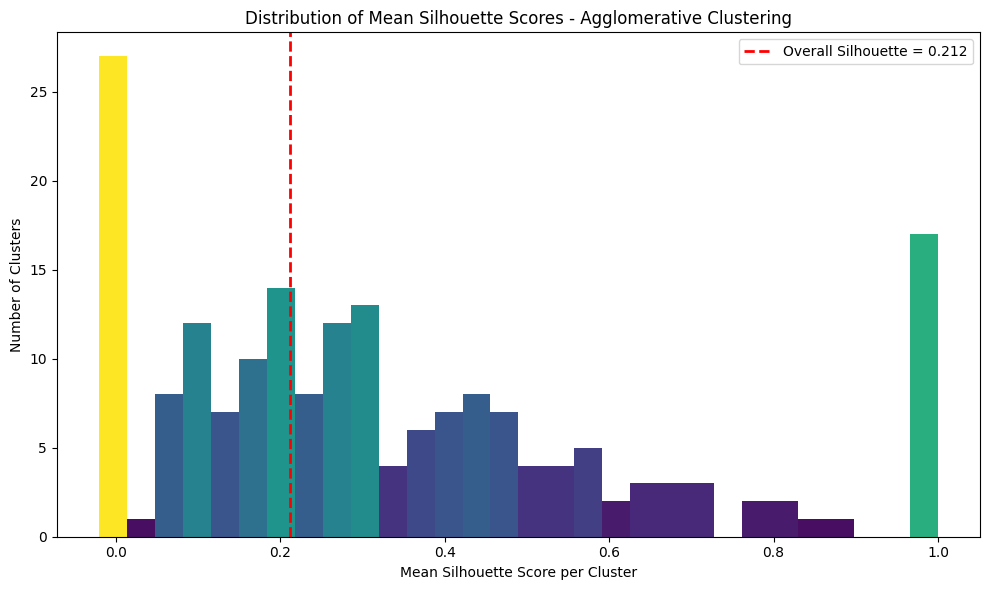

In [ ]:
# ==========================================================
# VISUALIZATION 1
# DISTRIBUTION OF MEAN SILHOUETTE SCORE PER CLUSTER
# ==========================================================

import matplotlib.pyplot as plt
import matplotlib.cm as cm # Import colormap module

plt.figure(figsize=(10, 6))

# Get the histogram patches without specifying a single color
n, bins, patches = plt.hist(
    cluster_summary["mean_silhouette"],
    bins=30
)

# Apply a colormap to the histogram bars based on their height
# Normalize the counts for coloring, so colors range smoothly from min to max height
n_min, n_max = n.min(), n.max()
if n_max == n_min: # Handle case where all bins have the same height
    norm = plt.Normalize(0, 1)
else:
    norm = plt.Normalize(n_min, n_max)

for i, patch in enumerate(patches):
    patch.set_facecolor(cm.viridis(norm(n[i]))) # Using viridis colormap

# Garis Overall Silhouette
plt.axvline(
    silhouette_agg,
    linestyle="--",
    linewidth=2,
    color='red', # The overall silhouette line remains red for contrast
    label=f"Overall Silhouette = {silhouette_agg:.3f}"
)

plt.xlabel(
    "Mean Silhouette Score per Cluster"
)

plt.ylabel(
    "Number of Clusters"
)

plt.title(
    "Distribution of Mean Silhouette Scores - "
    "Agglomerative Clustering"
)

plt.legend()

plt.tight_layout()
plt.show()

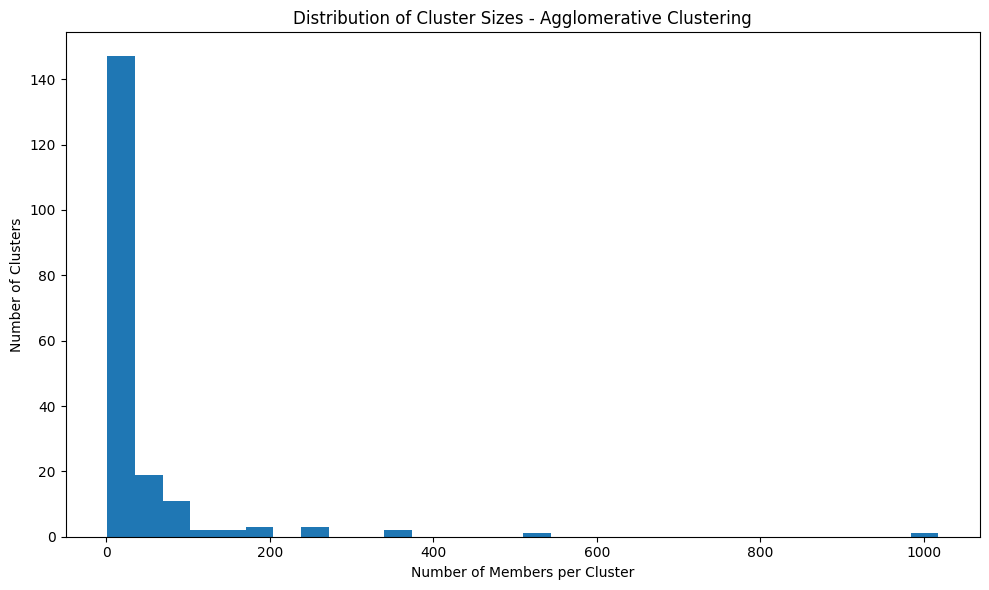

In [ ]:
# ==========================================================
# VISUALIZATION 2
# DISTRIBUTION OF CLUSTER SIZE
# ==========================================================

plt.figure(figsize=(10, 6))

plt.hist(
    cluster_summary["total_member"],
    bins=30
)

plt.xlabel(
    "Number of Members per Cluster"
)

plt.ylabel(
    "Number of Clusters"
)

plt.title(
    "Distribution of Cluster Sizes - "
    "Agglomerative Clustering"
)

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================================
# VISUALIZATION 3
# PCA 2D - AGGLOMERATIVE CLUSTERING
# COLORED BY SILHOUETTE SCORE
# ==========================================================

from sklearn.decomposition import PCA

pca = PCA(
    n_components=2,
    random_state=42
)

X_pca = pca.fit_transform(
    X_embedding
)

print(
    "PCA Explained Variance Ratio:"
)

print(
    pca.explained_variance_ratio_
)

print(
    f"Total Explained Variance: "
    f"{pca.explained_variance_ratio_.sum():.4f}"
)

PCA Explained Variance Ratio:
[0.09742003 0.0744018 ]
Total Explained Variance: 0.1718


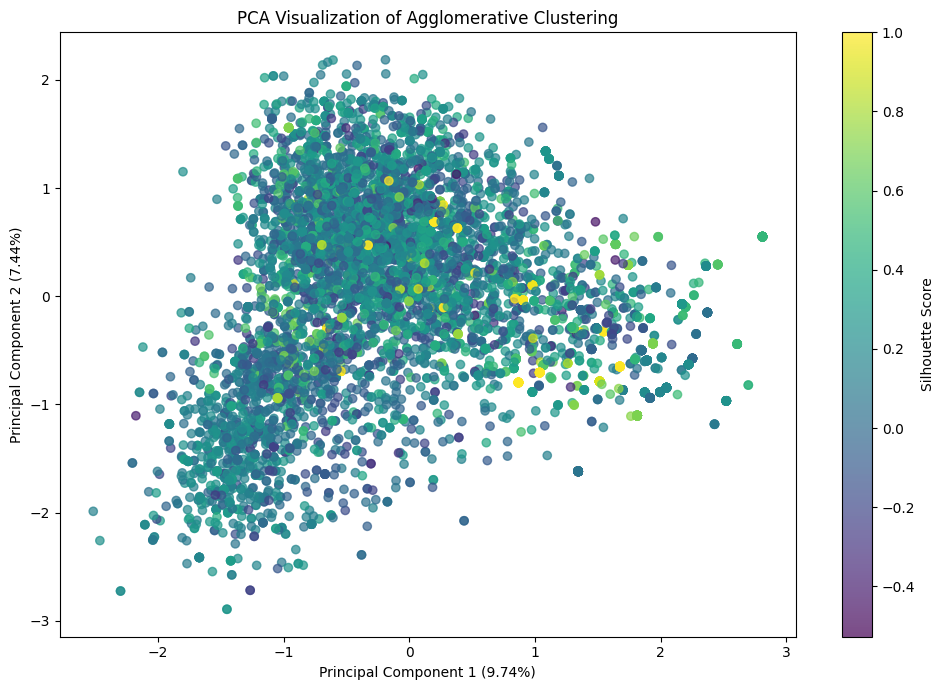

In [ ]:
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=sample_silhouette,
    alpha=0.7
)

plt.colorbar(
    scatter,
    label="Silhouette Score"
)

plt.xlabel(
    f"Principal Component 1 "
    f"({pca.explained_variance_ratio_[0] * 100:.2f}%)"
)

plt.ylabel(
    f"Principal Component 2 "
    f"({pca.explained_variance_ratio_[1] * 100:.2f}%)"
)

plt.title(
    "PCA Visualization of Agglomerative Clustering"
)

plt.tight_layout()
plt.show()

# LOAD DATA, CLEANING, PREPROCESSING

In [ ]:
import pandas as pd
import os # Added for file path checks and directory creation

# Mount Google Drive (if not already mounted)
from google.colab import drive
drive.mount('/content/drive')

# Define dataset paths
CURRICULUM_DATASET_PATH = '/content/drive/MyDrive/TA_Jennifer Felicia/DATASET/KURIKULUM/PROCESSED/'
TRACER_STUDY_DATASET_PATH = '/content/drive/MyDrive/TA_Jennifer Felicia/DATASET/TRACER STUDY/PROCESSED/'
PON_TIK_DICTIONARY_PATH = '/content/drive/MyDrive/TA_Jennifer Felicia/DATASET/Dictionary/PON_TIK/'
KKNI_DICTIONARY_PATH = '/content/drive/MyDrive/TA_Jennifer Felicia/DATASET/Dictionary/KKNI/'
INDUSTRY_DATASET_PATH = '/content/drive/MyDrive/TA_Jennifer Felicia/DATASET/INDUSTRI/PREPROCESSED/'
BLOOM_DICTIONARY_PATH = '/content/drive/MyDrive/TA_Jennifer Felicia/DATASET/Dictionary/KKO_TAXONOMY_BLOOM/'

# --- Load cpl_cleaned.csv ---
df_cpl = pd.read_csv(CURRICULUM_DATASET_PATH + 'cpl/cpl_cleaned.csv')

# --- Load kompetensi_cleaned.csv ---
df_kompetensi = pd.read_csv(CURRICULUM_DATASET_PATH + 'kompetensi/kompetensi_cleaned.csv')

# --- Load tracer_study_cleaned.csv ---
df_tracer = pd.read_csv(TRACER_STUDY_DATASET_PATH + 'tracer_study_standardized_v2.csv')

# --- Load bigram_final_skill_list.csv dan bilingual_industry_skills ---
df_industri = pd.read_csv(INDUSTRY_DATASET_PATH + 'industry_final.csv')
print(df_industri.shape)

# --- Load pon_tik_occupations_details.csv ---
df_pon_tik = pd.read_csv(PON_TIK_DICTIONARY_PATH + 'pon_tik_competency.csv')

# --- Load pon_tik_hierarchy.csv ---
hierarchy_df = pd.read_csv(PON_TIK_DICTIONARY_PATH + 'AGGLOMERATIVE_CLUSTERING_OUTPUT/pon_tik_hierarchy.csv')

# --- Load pon_tik_domain_representation.csv ---
df_domain = pd.read_csv(PON_TIK_DICTIONARY_PATH + 'AGGLOMERATIVE_CLUSTERING_OUTPUT/pon_tik_domain_representation.csv')

Mounted at /content/drive
(14650, 4)


In [ ]:
# Install the deep_translator client library
%pip install deep_translator

print('deep_translator library installed.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 3.9 MB/s eta 0:00:00
deep_translator library installed.


In [ ]:
import nltk
import re
import pandas as pd
import time # Import time for sleep
import json # Import json for specific error handling
from deep_translator import GoogleTranslator
import html # Import html for unescaping HTML entities

# Directly download NLTK data packages without checking via nltk.data.find first.
# This might bypass the "partially initialized module 'nltk' has no attribute 'data'" error
# if the issue is with nltk.data being accessed before it's fully ready during the find operation itself.
# Moved these downloads AFTER other imports to ensure nltk fully initializes.
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True) # Added download for punkt_tab

# Import NLTK components *after* base NLTK and downloads are handled
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Initialize lemmatizer and stopwords for both Indonesian and English
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('indonesian') + stopwords.words('english'))

def translate_text_deep(text, target_language='id', max_retries=3, delay=1):
    if pd.isna(text) or not isinstance(text, str) or not text.strip():
        return "" # Return empty string for invalid/empty inputs

    text_stripped = text.strip()

    for attempt in range(max_retries):
        try:
            # GoogleTranslator automatically detects source language
            translator = GoogleTranslator(source='auto', target=target_language)
            translated_text = translator.translate(text_stripped)

            if translated_text: # Ensure translation was successful
                return html.unescape(translated_text)
            else:
                raise ValueError("Translation failed or returned empty.")
        except Exception as e:
            print(f"Deep Translator attempt {attempt + 1}/{max_retries} failed for '{text_stripped[:50]}...': {e}")
            if attempt < max_retries - 1:
                time.sleep(delay) # Wait before retrying
            else:
                print(f"All retries failed for '{text_stripped[:50]}...'. Returning original text.")
                return text # Return original text on final failure

print("New `translate_text_deep` function defined.")

def clean_text(text):
    if not isinstance(text, str): # Handle non-string types gracefully
        return ""
    text = text.lower()  # Lowercase
    text = re.sub(r'[^a-z\s]', '', text) # Remove punctuation and numbers
    tokens = word_tokenize(text)  # Tokenization
    # Remove stopwords and lemmatize
    cleaned_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(cleaned_tokens)

# Apply cleaning to df_cpl
df_cpl['cleaned_text'] = df_cpl['text_clean'].apply(clean_text)

# ==========================================================
# PREPROCESSING FOR df_kompetensi
# ==========================================================

# Remove missing extracted text
df_kompetensi = df_kompetensi.dropna(subset=['extracted_text'])

# Clean whitespace
df_kompetensi['extracted_text'] = (
    df_kompetensi['extracted_text']
    .astype(str)
    .str.strip()
)

# Remove empty rows
df_kompetensi = df_kompetensi[
    df_kompetensi['extracted_text'] != ''
]

# ==========================================================
# COMBINE SECTION + CONTENT
# ==========================================================

df_kompetensi['combined_text'] = (
    df_kompetensi['section']
    .astype(str)
    .str.replace('_', ' ')
    + ' '
    + df_kompetensi['extracted_text'].astype(str)
)

# ==========================================================
# TRANSLATE TO INDONESIAN
# ==========================================================

relevant_sections = [
    'course_description',
    'course_objectives',
    'methods_instruction',
    'course_outline'
]

df_kompetensi = df_kompetensi[
    df_kompetensi['section'].isin(relevant_sections)
]

print("Translating df_kompetensi to Indonesian using deep_translator...")

df_kompetensi['translated_text'] = (
    df_kompetensi['combined_text']
    .apply(translate_text_deep)
)

# ==========================================================
# COMBINE ALL SECTIONS INTO ONE TEXT PER COURSE
# ==========================================================

df_course_representation = (
    df_kompetensi
    .groupby(['course_code', 'course_name'])['translated_text']
    .apply(lambda texts: ' '.join(texts))
    .reset_index()
)

# Rename column
df_course_representation.columns = [
    'course_code',
    'course_name',
    'combined_course_text'
]

# ==========================================================
# CLEAN FINAL COMBINED TEXT
# ==========================================================

df_course_representation['cleaned_text'] = (
    df_course_representation['combined_course_text']
    .apply(clean_text)
)

# Apply cleaning to df_pon_tik
df_pon_tik['cleaned_text'] = df_pon_tik['competency_unit'].apply(clean_text)

print("Cleaning and Preprocessing complete.")

print("\n df_cpl head with cleaned_text:")
display(df_cpl[['text_clean', 'cleaned_text']].head())

print("\n df_course_representation head with cleaned_text (after translation):")
display(
    df_course_representation[
        ['course_code','course_name', 'combined_course_text', 'cleaned_text']
    ].head()
)

print("\n df_pon_tik head with cleaned_text:")
display(df_pon_tik[['competency_unit', 'cleaned_text']].head())

New `translate_text_deep` function defined.
Translating df_kompetensi to Indonesian using deep_translator...
Deep Translator attempt 1/3 failed for 'course outline targeted session topic & sub topics...': course outline targeted session topic & sub topics & duration material references assessment indicators competencies (sesi) (materi pembelajaran) (bentuk & durasi (sumber pembelajaran) (indikator penilaian) (kemampuan akhir) pembelajaran) william l. briggs, lyle cochran. calculus 3rd ed. pearson. 2011 george b. thomas, maurice d. weir, joel r. mahasiswa mampu hass; thomas’ calculus 12th memahami dan ed.; pearson education, mahasiswa mampu memahami memecahkan masalah topic introduction inc., 2010 dan memecahkan masalah pada pada materi materi specific sub topics materi – 100 menit b. h. anton, i. c. bivens, fungsi fungsi 1 fungsi diskusi kasus – 30 menit and s. davis. calculus late a. penjelasan  penjelasan fungsi a. penjelasan fungsi tugas 20 menit transcendentals. john fungsi  meng

,text_clean,cleaned_text
0,memiliki kepribadian yang beriman dan bertaqwa...,memiliki kepribadian beriman bertaqwa tuhan ym...
1,mampu bersaing di pasar global dengan pengetah...,bersaing pasar global pengetahuan kemampuan me...
2,memiliki pengetahuan yang memadai terkait deng...,memiliki pengetahuan memadai terkait membangun...
3,mampu meningkatkan pengetahuan dan kemampuan t...,meningkatkan pengetahuan kemampuan terkait pem...
4,mempunyai kemampuan komunikasi dalam mendefini...,kemampuan komunikasi mendefinisikan kebutuhan ...



 df_course_representation head with cleaned_text (after translation):


,course_code,course_name,combined_course_text,cleaned_text
0,FTK101,Algoritma & Pemrograman,Deskripsi Mata Kuliah Mata kuliah ini bertujua...,deskripsi mata kuliah mata kuliah bertujuan pe...
1,FTK103,Pemrograman Visual,deskripsi kursus kursus ini dimaksudkan untuk ...,deskripsi kursus kursus kursus pengantar pemro...
2,FTK111,Kalkulus 1,course description mata kuliah ini dimaksudkan...,course description mata kuliah kemampuan mahas...
3,FTK121,Aljabar Linear,Deskripsi Mata Kuliah Mata kuliah ini memberik...,deskripsi mata kuliah mata kuliah pemahaman pe...
4,FTK151,Metodologi Penelitian dan Ilmiah,Error 500 (Server Error)!!1500.That’s an error...,error server errorthats errorthere error pleas...



 df_pon_tik head with cleaned_text:


,competency_unit,cleaned_text
0,orang yang bertanggung jawab untuk memimpin da...,orang bertanggung memimpin mengelola teknologi...
1,mengembangkan dan mengimplementasikan strategi...,mengembangkan mengimplementasikan strategi tek...
2,mengelola dan mengoptimalkan aset ti,mengelola mengoptimalkan aset ti
3,berintegritas,berintegritas
4,analitis,analitis


In [ ]:
from sentence_transformers import SentenceTransformer
import numpy as np

# Install sentence-transformers if not already installed
try:
    from sentence_transformers import SentenceTransformer
except ImportError:
    %pip install sentence-transformers
    from sentence_transformers import SentenceTransformer

# Load the multilingual Sentence Transformer model
print("Loading Sentence Transformer model 'paraphrase-multilingual-MiniLM-L12-v2'...")
embedding_model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
print("Model loaded.")

# --- Embeddings for df_cpl ---
print("Generating embeddings for df_cpl...")
df_cpl['embedding'] = [embedding_model.encode(text) for text in df_cpl['cleaned_text'].tolist()]
print("Embeddings for df_cpl generated.")
cpl_embeddings = np.array(df_cpl['embedding'].tolist())
print(f"Shape of df_cpl embeddings: {cpl_embeddings.shape}")

# --- Embeddings for df_kompetensi ---
print("Generating embeddings for df_kompetensi...")
df_course_representation['embedding'] = [embedding_model.encode(text) for text in df_course_representation['combined_course_text'].tolist()]
print("Embeddings for df_kompetensi generated.")
kompetensi_embeddings = np.array(df_course_representation['embedding'].tolist())
print(f"Shape of df_kompetensi embeddings: {kompetensi_embeddings.shape}")

# --- Embeddings for df_industri ---
print("Generating embeddings for df_industri...")
df_industri['embedding'] = [embedding_model.encode(text) for text in df_industri['competency_embedding_text'].tolist()]
print("Embeddings for df_industri generated.")
industri_embeddings = np.array(df_industri['embedding'].tolist())
print(f"Shape of df_industri embeddings: {industri_embeddings.shape}")

# --- Embeddings for df_pon_tik ---
print("Generating embeddings for df_pon_tik...")
df_pon_tik['embedding'] = [embedding_model.encode(text) for text in df_pon_tik['cleaned_text'].tolist()]
print("Embeddings for df_pon_tik generated.")
pon_tik_embeddings = np.array(df_pon_tik['embedding'].tolist())
print(f"Shape of df_pon_tik embeddings: {pon_tik_embeddings.shape}")


print("--- Text Embedding --- END")

Loading Sentence Transformer model 'paraphrase-multilingual-MiniLM-L12-v2'...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: reconstructing file:   0%|          |  0.00B / 9.08MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded.
Generating embeddings for df_cpl...
Embeddings for df_cpl generated.
Shape of df_cpl embeddings: (11, 384)
Generating embeddings for df_kompetensi...
Embeddings for df_kompetensi generated.
Shape of df_kompetensi embeddings: (54, 384)
Generating embeddings for df_industri...
Embeddings for df_industri generated.
Shape of df_industri embeddings: (14650, 384)
Generating embeddings for df_pon_tik...
Embeddings for df_pon_tik generated.
Shape of df_pon_tik embeddings: (7092, 384)
--- Text Embedding --- END


## Preparing Classifier

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# ============================================================
# PREPARE TRAINING DATA
# ============================================================

X = pon_tik_embeddings
y = hierarchy_df["skill_category"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(5319, 384)
(1773, 384)


In [ ]:
# ============================================================
# RANDOM FOREST
# ============================================================

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    criterion="gini",
    random_state=42,
    class_weight="balanced"
)

rf_param = {

    "n_estimators":[100,200],

    "max_depth":[None,10,20],

    "min_samples_split":[2,5,10],

    "min_samples_leaf":[1,2,4]

}

# ============================================================
# XGBoost
# ============================================================

from xgboost import XGBClassifier

xgb_model = XGBClassifier(

    objective="binary:logistic",

    eval_metric="logloss",

    random_state=42

)

xgb_param = {

    "n_estimators":[100,200],

    "max_depth":[4,6,8],

    "learning_rate":[0.01,0.1],

    "subsample":[0.8,1.0]

}

# ============================================================
# Logistic Regression
# ============================================================

from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    random_state=42,
    max_iter=5000
)

lr_param = {

    "C":[0.01,0.1,1,10],

    "solver":["lbfgs"],

    "penalty":["l2"]

}

# ============================================================
# Decision Tree
# ============================================================

from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    criterion="gini",
    random_state=42,
    class_weight="balanced"
)

dt_param = {

    "criterion":["gini","entropy"],

    "max_depth":[None,10,20],

    "min_samples_split":[2,5,10]

}

# ============================================================
# Extra Trees
# ============================================================

from sklearn.ensemble import ExtraTreesClassifier

et_model = ExtraTreesClassifier(
    criterion="gini",
    random_state=42,
    class_weight="balanced"
)

et_param = {

    "n_estimators":[100,200],

    "max_depth":[None,10,20],

    "min_samples_split":[2,5],

    "min_samples_leaf":[1,2]

}

# ============================================================
# CatBoost
# ============================================================
!pip install -q catboost lightgbm
from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(

    random_seed=42,

    verbose=False

)

cat_param = {

    "iterations":[200,500],

    "depth":[4,6,8],

    "learning_rate":[0.01,0.1]

}

# ============================================================
# LightGBM
# ============================================================

from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(

    random_state=42

)

lgbm_param = {

    "n_estimators":[100,200],

    "learning_rate":[0.01,0.1],

    "max_depth":[-1,10,20]

}

# ============================================================
# Bagged Trees
# ============================================================

from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bag_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(
        criterion="gini",
        random_state=42,
        class_weight="balanced"
    ),
    n_estimators=100,
    max_samples=0.8,
    max_features=0.7,
    random_state=42,
)

bag_param = {}

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_validate

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import log_loss

def evaluate_model(
        model,
        param_grid,
        model_name,
        X_train,
        y_train,
        X_test,
        y_test,
        prediction_embeddings,
        prediction_dataframe,
        label_column="predicted_skill_category",
        probability_prefix="probability_"
):

    print("\n" + "="*80)
    print(f"TRAINING {model_name}")
    print("="*80)

    encoder = None

    if model_name == "XGBoost":

        encoder = LabelEncoder()

        y_train = encoder.fit_transform(y_train)

        y_test = encoder.transform(y_test)

    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=10,
        scoring="f1_weighted",
        n_jobs=-1,
        verbose=3
    )

    grid_search.fit(X_train, y_train)

    best_model = grid_search.best_estimator_

    print("\nBest Parameters:")
    print(grid_search.best_params_)

    print("Best CV Score:")
    print(round(grid_search.best_score_,4))

    print("\n" + "="*80)
    print("MODEL EVALUATION")
    print("="*80)

    cv_result = cross_validate(

        estimator=best_model,

        X=X_train,

        y=y_train,

        cv=10,

        scoring={
            "accuracy":"accuracy",
            "precision":"precision_weighted",
            "recall":"recall_weighted",
            "f1":"f1_weighted"
        },

        return_train_score=False,

        n_jobs=-1

    )

    fold_result = pd.DataFrame({

        "Fold": np.arange(1,11),

        "Accuracy": cv_result["test_accuracy"],

        "Precision": cv_result["test_precision"],

        "Recall": cv_result["test_recall"],

        "F1 Score": cv_result["test_f1"]

    })

    print("\n10-Fold Cross Validation Results")
    display(fold_result.round(4))

    # ============================================================
    # CROSS VALIDATION SUMMARY
    # ============================================================

    cv_summary = pd.DataFrame({

        "Metric":[

            "Accuracy",

            "Precision",

            "Recall",

            "F1 Score"

        ],

        "Mean":[

            cv_result["test_accuracy"].mean(),

            cv_result["test_precision"].mean(),

            cv_result["test_recall"].mean(),

            cv_result["test_f1"].mean()

        ],

        "Standard Deviation":[

            cv_result["test_accuracy"].std(),

            cv_result["test_precision"].std(),

            cv_result["test_recall"].std(),

            cv_result["test_f1"].std()

        ]

    })

    print("\nCross Validation Summary")
    display(cv_summary.round(4))

    plt.figure(figsize=(8,5))

    plt.plot(
        fold_result["Fold"],
        fold_result["F1 Score"],
        marker="o",
        label="F1 Score"
    )

    plt.plot(
        fold_result["Fold"],
        fold_result["Accuracy"],
        marker="s",
        label="Accuracy"
    )

    plt.xticks(fold_result["Fold"])
    plt.xlabel("Fold")
    plt.ylabel("Score")
    plt.title(f"10-Fold Cross Validation Performance - {model_name}")
    plt.grid(True)
    plt.legend()

    plt.show()

    y_pred = best_model.predict(X_test)

    if encoder is not None:

        y_pred = encoder.inverse_transform(y_pred)

        y_test = encoder.inverse_transform(y_test)

    # ============================================================
    # LOG LOSS (CROSS ENTROPY LOSS)
    # ============================================================

    if hasattr(best_model, "predict_proba"):

        y_prob_test = best_model.predict_proba(
            X_test
        )

        loss = log_loss(
            y_test,
            y_prob_test
        )

        gini_per_sample = 1 - np.sum(
            y_prob_test ** 2,
            axis=1
        )

        average_gini = (
            gini_per_sample.mean()
        )

    else:
        loss = None


    accuracy = accuracy_score(y_test,y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    print(f"Log Loss  : {loss:.4f}")
    print(f"Average Gini : {average_gini:.4f}")
    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")

    print("\nClassification Report")

    # ============================================================
    # PER-CLASS METRICS
    # ============================================================

    report = classification_report(
        y_test,
        y_pred,
        output_dict=True,
        zero_division=0
    )

    per_class_metrics = pd.DataFrame({

        "Precision": [
            report["Hard"]["precision"],
            report["Soft"]["precision"]
        ],

        "Recall": [
            report["Hard"]["recall"],
            report["Soft"]["recall"]
        ],

        "F1 Score": [
            report["Hard"]["f1-score"],
            report["Soft"]["f1-score"]
        ],

        "Support": [
            report["Hard"]["support"],
            report["Soft"]["support"]
        ]

    },
    index=["Hard","Soft"])

    print("\nPer-Class Performance")
    display(per_class_metrics.round(4))

    print("\nConfusion Matrix")

    print("\nConfusion Matrix")
    cm = confusion_matrix(y_test, y_pred)

    # Label kelas
    if encoder is not None:
        labels = encoder.inverse_transform(best_model.classes_)
    else:
        labels = best_model.classes_

    plt.figure(figsize=(8, 6))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=labels,
        yticklabels=labels
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix - {model_name}")

    plt.tight_layout()
    plt.show()

    print("\n" + "="*80)
    print("PREDICTING DATA")
    print("="*80)

    prediction = best_model.predict(
        prediction_embeddings
    )

    if encoder is not None:

        prediction = encoder.inverse_transform(prediction)

    probability = best_model.predict_proba(
        prediction_embeddings
    )

    result_df = prediction_dataframe.copy()

    result_df[label_column] = prediction

    if encoder is not None:

        class_names = encoder.inverse_transform(best_model.classes_)

    else:

        class_names = best_model.classes_

    for i, cls in enumerate(class_names):

        result_df[
            f"{cls.lower()}_{probability_prefix}"
        ] = probability[:, i]

    print(result_df[label_column].value_counts())

    metrics = {

        "Model": model_name,

        "Log Loss": loss,

        "Gini Impurity": average_gini,

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1": f1,

        "Hard Precision": report["Hard"]["precision"],
        "Hard Recall": report["Hard"]["recall"],
        "Hard F1": report["Hard"]["f1-score"],

        "Soft Precision": report["Soft"]["precision"],
        "Soft Recall": report["Soft"]["recall"],
        "Soft F1": report["Soft"]["f1-score"]

    }

    return best_model,result_df,metrics, cv_result


# INDUSTRY

## Manual

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import numpy as np
import os

# ============================================================
# PARAMETERS
# ============================================================

SIMILARITY_THRESHOLD = 0.60

# ============================================================
# VALIDATION
# ============================================================

print("=" * 80)
print("VALIDATING DATA")
print("=" * 80)

print(f"Industry Competencies : {len(df_industri)}")
print(f"PON TIK Competencies  : {len(hierarchy_df)}")

print(f"Industry Embeddings   : {len(industri_embeddings)}")
print(f"PON TIK Embeddings    : {len(pon_tik_embeddings)}")

# ============================================================
# COSINE SIMILARITY
# ============================================================

print("\n")
print("=" * 80)
print("CALCULATING COSINE SIMILARITY")
print("=" * 80)

similarity_matrix = cosine_similarity(
    industri_embeddings,
    pon_tik_embeddings
)

print(
    f"Similarity Matrix Shape: "
    f"{similarity_matrix.shape}"
)

# ============================================================
# BEST MATCH
# ============================================================

print("\nFinding best match...")

best_match_idx = similarity_matrix.argmax(axis=1)

best_similarity = similarity_matrix.max(axis=1)

print("Done.")

# ============================================================
# ASSIGN MATCHED PON TIK
# ============================================================

df_industri["matched_pon_tik"] = (

    hierarchy_df
    .iloc[best_match_idx]
    ["competency_unit"]
    .values

)

df_industri["skill_category"] = (

    hierarchy_df
    .iloc[best_match_idx]
    ["skill_category"]
    .values

)

df_industri["matched_pon_tik_domain_id"] = ( # Added: New column for domain_id

    hierarchy_df
    .iloc[best_match_idx]
    ["cluster_0.5"]
    .values

)

df_industri["similarity_score"] = best_similarity

# ============================================================
# APPLY THRESHOLD
# ============================================================

df_industri["final_skill_category"] = np.where(

    df_industri["similarity_score"]
    >= SIMILARITY_THRESHOLD,

    df_industri["skill_category"],

    "Unknown"

)

# ============================================================
# CATEGORY DISTRIBUTION
# ============================================================

print("\n")
print("=" * 80)
print("FINAL CATEGORY DISTRIBUTION")
print("=" * 80)

category_distribution = (

    df_industri[
        "final_skill_category"
    ]
    .value_counts()
    .reset_index()

)

category_distribution.columns = [
    "skill_category",
    "count"
]

display(category_distribution)

# ============================================================
# SIMILARITY STATISTICS
# ============================================================

print("\n")
print("=" * 80)
print("SIMILARITY STATISTICS")
print("=" * 80)

print(
    df_industri[
        "similarity_score"
    ].describe()
)

# ============================================================
# TOP MATCHES
# ============================================================

print("\n")
print("=" * 80)
print("TOP MATCHES")
print("=" * 80)

top_matches = (

    df_industri
    .sort_values(
        "similarity_score",
        ascending=False
    )
    .head(20)

)

display(

    top_matches[
        [
            "competency_embedding_text",
            "matched_pon_tik",
            "skill_category",
            "matched_pon_tik_domain_id", # Added: Display new column
            "similarity_score"
        ]
    ]

)

# ============================================================
# LOW CONFIDENCE MATCHES
# ============================================================

print("\n")
print("=" * 80)
print("LOW CONFIDENCE MATCHES")
print("=" * 80)

low_confidence = (

    df_industri[
        df_industri[
            "similarity_score"
        ] < SIMILARITY_THRESHOLD
    ]
    .sort_values(
        "similarity_score"
    )

)

display(
    low_confidence.head(50)
)

# ============================================================
# SAVE RESULT TO GOOGLE DRIVE
# ============================================================

# Define the output directory in Google Drive
GDrive_OUTPUT_DIR = '/content/drive/MyDrive/TA_Jennifer Felicia/DATASET/INDUSTRI/MAPPING/'

# Create the directory if it doesn't exist
os.makedirs(GDrive_OUTPUT_DIR, exist_ok=True)

# Define the full path for the output file
output_file_gdrive = os.path.join(GDrive_OUTPUT_DIR, 'industry_skill_classification.csv')

df_industri.to_csv(
    output_file_gdrive,
    index=False,
    encoding="utf-8-sig"
)

print("\n")
print("=" * 80)
print("FILE SAVED")
print("=" * 80)
print(output_file_gdrive)

# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 80)
print("SUMMARY")
print("=" * 80)

print(
    f"Total Industry Competencies : "
    f"{len(df_industri)}"
)

print(
    f"Hard Skills : "
    f"{(df_industri['final_skill_category'] == 'Hard').sum()}"
)

print(
    f"Soft Skills : "
    f"{(df_industri['final_skill_category'] == 'Soft').sum()}"
)

print(
    f"Other Skills : "
    f"{(df_industri['final_skill_category'] == 'Other').sum()}"
)

print(
    f"Unknown Skills : "
    f"{(df_industri['final_skill_category'] == 'Unknown').sum()}"
)

VALIDATING DATA
Industry Competencies : 14650
PON TIK Competencies  : 7092
Industry Embeddings   : 14650
PON TIK Embeddings    : 7092


CALCULATING COSINE SIMILARITY
Similarity Matrix Shape: (14650, 7092)

Finding best match...
Done.


FINAL CATEGORY DISTRIBUTION


,skill_category,count
0,Hard,8294
1,Unknown,3362
2,Soft,2994




SIMILARITY STATISTICS
count    14650.000000
mean         0.673293
std          0.100058
min          0.293865
25%          0.607122
50%          0.678209
75%          0.742868
max          1.000000
Name: similarity_score, dtype: float64


TOP MATCHES


,competency_embedding_text,matched_pon_tik,skill_category,matched_pon_tik_domain_id,similarity_score
2247,sql,menggunakan sql,Hard,110,1.000000
582,komunikasi communication,komunikasi,Soft,43,0.981073
13242,kolaborasi collaboration,melakukan kolaborasi dengan berbagai pihak,Soft,32,0.973208
10232,profesional professional,profesional,Soft,33,0.967764
10357,peran kepemimpinan leadership role,menerapkan kepemimpinan (leadership),Soft,33,0.966924
138,berkolaborasi collaborating,melakukan kolaborasi dengan berbagai pihak,Soft,32,0.964055
9255,teknologi Informasi information technology,bidang teknologi informasi,Hard,176,0.962779
465,komunikasi yang efektif effective communication,melaksanakan komunikasi efektif,Soft,43,0.959053
4259,pemecahan masalah problem solving,problem solving,Soft,146,0.957949
11670,menganalisis hasil pengujian analyze test results,mengevaluasi hasil pengujian,Hard,140,0.952857




LOW CONFIDENCE MATCHES


,competency_unit,competency_unit_id,competency_unit_en,competency_embedding_text,embedding,matched_pon_tik,skill_category,matched_pon_tik_domain_id,similarity_score,final_skill_category
5195,"menguasai javascript, react, next.js dan sprin...","menguasai javascript, react, next.js dan sprin...","menguasai javascript, react, next.js dan sprin...","menguasai javascript, react, next.js dan sprin...","[-0.30191654, 0.11801439, 0.07196194, 0.115910...",mengubah konfigurasi platform,Hard,165,0.293865,Unknown
2163,hotels,hotel,hotels,hotel hotels,"[0.72705305, -0.08241456, -0.44028154, 0.51390...",melakukan penilaian arsitektur enterprise,Hard,182,0.302688,Unknown
24,python,ular piton,python,ular piton python,"[-0.6125517, 0.015700161, -0.036889464, 0.0654...",menentukan metode pengujian yang akan dilakukan,Hard,147,0.317522,Unknown
568,along with the crj100/200/700/900 aircrafts.,bersama dengan pesawat crj100/200/700/900.,along with the crj100/200/700/900 aircrafts.,bersama dengan pesawat crj100/200/700/900. alo...,"[0.011839264, -0.03623133, -0.1559676, -0.1448...",memastikan ketersediaan suku cadang dan perala...,Hard,153,0.320567,Unknown
1981,30-minute drive from ngurah rai international ...,30 menit berkendara dari bandara internasional...,30-minute drive from ngurah rai international ...,30 menit berkendara dari bandara internasional...,"[0.62634933, -0.0783391, 0.039808236, -0.03716...",memeriksa persyaratan kontraktual transfer dat...,Hard,115,0.327696,Unknown
7533,if you’re curious to know more then please rea...,"jika Anda penasaran ingin tahu lebih banyak, s...",if you’re curious to know more then please rea...,"jika Anda penasaran ingin tahu lebih banyak, s...","[0.37948045, 0.055637255, 0.09124453, 0.106656...",melakukan pemeliharaan preventif untuk mencega...,Hard,128,0.337028,Unknown
9248,pernah menggunakan framework spring boot (dan ...,pernah menggunakan framework spring boot (dan ...,never used spring boot framework (and angular-...,pernah menggunakan framework spring boot (dan ...,"[-0.22187856, -0.0012901233, 0.27419513, 0.173...",mengubah konfigurasi aplikasi,Hard,163,0.340374,Unknown
4844,familiar with java and spring boot.,akrab dengan java dan spring boot.,familiar with java and spring boot.,akrab dengan java dan spring boot. familiar wi...,"[-0.1880393, 0.165588, 0.12723446, 0.07192366,...",pengetahuan dasar tentang bahasa pemrograman;,Hard,157,0.342860,Unknown
173,sedang berada di semester 57 dan tidak lagi me...,sedang berada di semester 57 dan tidak lagi me...,is in semester 57 and no longer has any course...,sedang berada di semester 57 dan tidak lagi me...,"[0.43516827, 0.044267457, 0.29730326, 0.099793...",memberikan bimbingan kepada programmer junior,Hard,106,0.347344,Unknown
13497,command batch & powershell untuk windows (opti...,perintah batch & powershell untuk windows (ops...,command batch & powershell untuk windows (opti...,perintah batch & powershell untuk windows (ops...,"[0.001530747, 0.37239262, 0.037401445, 0.16965...",instalasi dan konfigurasi komputer,Hard,158,0.353435,Unknown




FILE SAVED
/content/drive/MyDrive/TA_Jennifer Felicia/DATASET/INDUSTRI/MAPPING/industry_skill_classification.csv


SUMMARY
Total Industry Competencies : 14650
Hard Skills : 8294
Soft Skills : 2994
Other Skills : 0
Unknown Skills : 3362


## Random Forest


TRAINING Random Forest
Fitting 10 folds for each of 54 candidates, totalling 540 fits

Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}
Best CV Score:
0.9852

MODEL EVALUATION

10-Fold Cross Validation Results


,Fold,Accuracy,Precision,Recall,F1 Score
0,1,0.9906,0.9906,0.9906,0.9906
1,2,0.9756,0.9759,0.9756,0.9751
2,3,0.9868,0.9871,0.9868,0.9867
3,4,0.9868,0.9869,0.9868,0.9867
4,5,0.9906,0.9906,0.9906,0.9906
5,6,0.9868,0.9869,0.9868,0.9867
6,7,0.9793,0.9792,0.9793,0.9792
7,8,0.9812,0.9811,0.9812,0.9811
8,9,0.9906,0.9907,0.9906,0.9905
9,10,0.9849,0.9850,0.9849,0.9848



Cross Validation Summary


,Metric,Mean,Standard Deviation
0,Accuracy,0.9853,0.0049
1,Precision,0.9854,0.0049
2,Recall,0.9853,0.0049
3,F1 Score,0.9852,0.0050


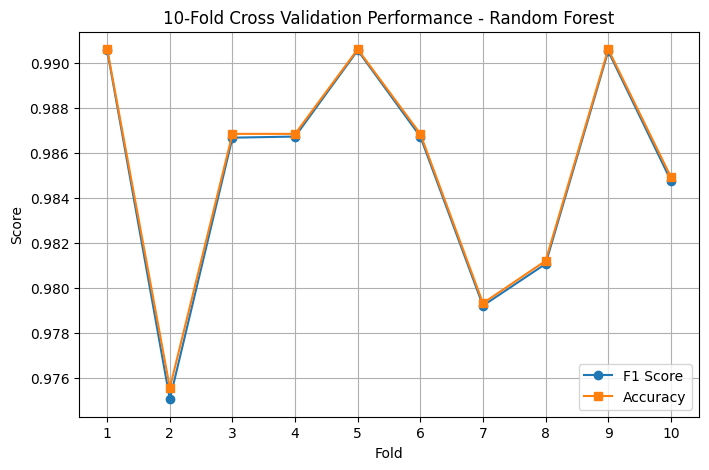

Log Loss  : 0.0559
Average Gini : 0.0637
Accuracy  : 0.9865
Precision : 0.9864
Recall    : 0.9865
F1 Score  : 0.9864

Classification Report

Per-Class Performance


,Precision,Recall,F1 Score,Support
Hard,0.9888,0.9944,0.9916,1417.0
Soft,0.9770,0.9551,0.9659,356.0



Confusion Matrix

Confusion Matrix


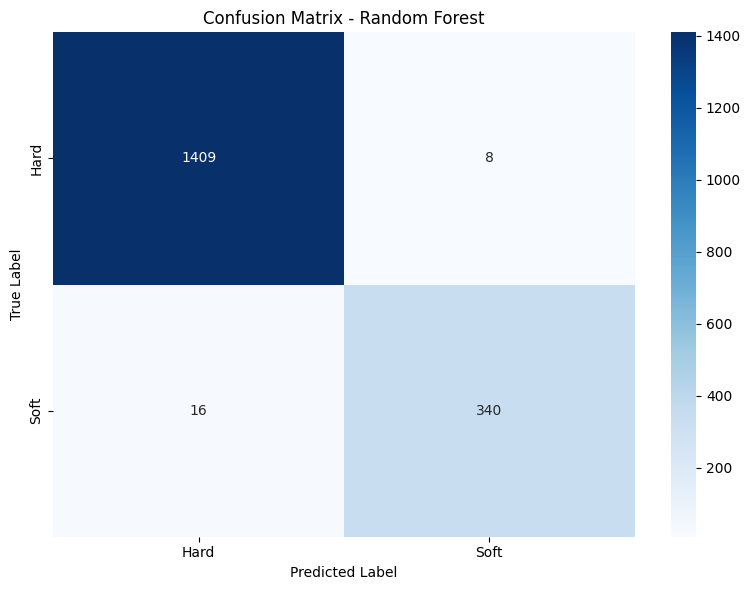


PREDICTING DATA
predicted_skill_category
Hard    13312
Soft     1338
Name: count, dtype: int64


,competency_unit,competency_unit_id,competency_unit_en,competency_embedding_text,embedding,matched_pon_tik,skill_category,matched_pon_tik_domain_id,similarity_score,final_skill_category,predicted_skill_category,hard_probability_,soft_probability_
0,assisting employees in the front-end developer...,membantu karyawan di posisi pengembang front-end.,assisting employees in the front-end developer...,membantu karyawan di posisi pengembang front-e...,"[0.104057685, -0.13499425, 0.100245744, -0.012...",bertanggung jawab terhadap server-side web app...,Hard,101,0.658220,Hard,Hard,0.799769,0.200231
1,learn about the latest web technologies and ha...,belajar tentang teknologi web terbaru dan memi...,learn about the latest web technologies and ha...,belajar tentang teknologi web terbaru dan memi...,"[0.12644048, -0.094306655, 0.0632917, -0.18109...",menginterpretasikan data web untuk menghasilka...,Hard,101,0.698115,Hard,Hard,0.927028,0.072972
2,coordinate with the whole team,berkoordinasi dengan seluruh tim,coordinate with the whole team,berkoordinasi dengan seluruh tim coordinate wi...,"[-0.037941027, 0.010393064, -0.17814402, -0.26...",mampu mengarahkan dan bekerjasama dalam tim,Soft,32,0.748288,Soft,Soft,0.489572,0.510428
3,responsible for ensuring the alignment of web ...,bertanggung jawab untuk memastikan keselarasan...,responsible for ensuring the alignment of web ...,bertanggung jawab untuk memastikan keselarasan...,"[-0.17175074, -0.0995169, 0.10567504, -0.14212...",orang yang bertanggung jawab untuk mendesain d...,Hard,101,0.801162,Hard,Hard,0.980177,0.019823
4,"learn about competencies in seo, sem, and ux/ui","belajar tentang kompetensi seo, sem, dan ux/ui","learn about competencies in seo, sem, and ux/ui","belajar tentang kompetensi seo, sem, dan ux/ui...","[0.10331608, -0.09676729, 0.0021167428, -0.138...",melakukan pelatihan dan edukasi kepada penggun...,Hard,160,0.535408,Unknown,Hard,0.811482,0.188518
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14645,menyiapkan sketsa dan berkolaborasi dengan tim...,menyiapkan sketsa dan berkolaborasi dengan tim...,prepare sketches and collaborate with engineer...,menyiapkan sketsa dan berkolaborasi dengan tim...,"[0.023582561, -0.118892476, 0.40467557, 0.0704...",berkoordinasi dengan tim pengembangan dan desa...,Hard,170,0.653497,Hard,Hard,0.601009,0.398991
14646,"mahir dalam perangkat lunak seperti autocad, r...","mahir dalam perangkat lunak seperti autocad, r...","proficient in software such as autocad, revit,...","mahir dalam perangkat lunak seperti autocad, r...","[-0.1969363, -0.22298834, -0.13225609, -0.1232...",memiliki kemampuan untuk menggunakan berbagai ...,Hard,163,0.647398,Hard,Hard,0.914788,0.085212
14647,memiliki perhatian tinggi terhadap detail dala...,memiliki perhatian tinggi terhadap detail dala...,has high attention to detail in compiling tech...,memiliki perhatian tinggi terhadap detail dala...,"[-0.1763931, -0.10781556, 0.07371722, 0.048838...","memiliki keterampilan teknis yang kuat, sepert...",Hard,157,0.620446,Hard,Hard,0.875161,0.124839
14648,"・回路系cadの経験（orcad capture/pcb designer, ltspiceなど）",・Pengalaman sirkuit CAD (pengambilan orcad/per...,・Circuit CAD experience (orcad capture/pcb des...,・Pengalaman sirkuit CAD (pengambilan orcad/per...,"[-0.15160252, -0.07290584, -0.0056066606, -0.0...",perencanaan dan pengembangan perangkat keras d...,Hard,153,0.531024,Unknown,Hard,0.941151,0.058849


In [ ]:
# ============================================================
# RANDOM FOREST
# ============================================================

industri_rf_model_result, industri_rf_result_df, industri_rf_metrics, industri_rf_cv = evaluate_model(

    model=rf_model,

    param_grid=rf_param,

    model_name="Random Forest",

    X_train=X_train,

    y_train=y_train,

    X_test=X_test,

    y_test=y_test,

    prediction_embeddings=industri_embeddings,

    prediction_dataframe=df_industri

)


display(industri_rf_result_df)

## Decision Tree


TRAINING Decision Tree
Fitting 10 folds for each of 18 candidates, totalling 180 fits

Best Parameters:
{'criterion': 'entropy', 'max_depth': None, 'min_samples_split': 5}
Best CV Score:
0.9716

MODEL EVALUATION

10-Fold Cross Validation Results


,Fold,Accuracy,Precision,Recall,F1 Score
0,1,0.9774,0.9773,0.9774,0.9774
1,2,0.9643,0.9642,0.9643,0.9642
2,3,0.9605,0.9604,0.9605,0.9605
3,4,0.9793,0.9793,0.9793,0.9793
4,5,0.9643,0.9639,0.9643,0.9640
5,6,0.9737,0.9739,0.9737,0.9738
6,7,0.9850,0.9853,0.9850,0.9851
7,8,0.9662,0.9660,0.9662,0.9660
8,9,0.9718,0.9722,0.9718,0.9719
9,10,0.9736,0.9739,0.9736,0.9737



Cross Validation Summary


,Metric,Mean,Standard Deviation
0,Accuracy,0.9716,0.0073
1,Precision,0.9716,0.0075
2,Recall,0.9716,0.0073
3,F1 Score,0.9716,0.0074


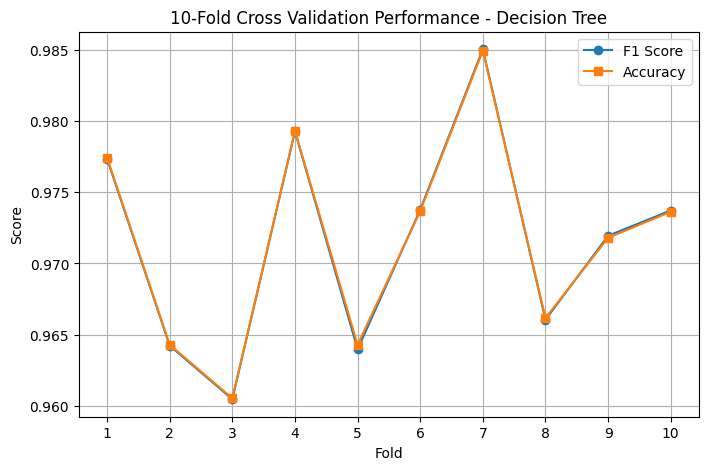

Log Loss  : 0.7725
Average Gini : 0.0000
Accuracy  : 0.9786
Precision : 0.9789
Recall    : 0.9786
F1 Score  : 0.9787

Classification Report

Per-Class Performance


,Precision,Recall,F1 Score,Support
Hard,0.9900,0.9831,0.9865,1417.0
Soft,0.9344,0.9607,0.9474,356.0



Confusion Matrix

Confusion Matrix


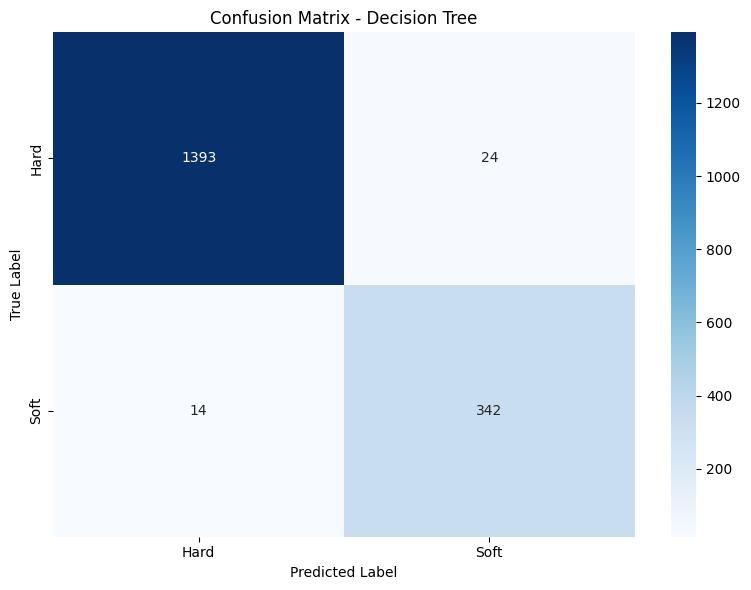


PREDICTING DATA
predicted_skill_category
Hard    11963
Soft     2687
Name: count, dtype: int64


,competency_unit,competency_unit_id,competency_unit_en,competency_embedding_text,embedding,matched_pon_tik,skill_category,matched_pon_tik_domain_id,similarity_score,final_skill_category,predicted_skill_category,hard_probability_,soft_probability_
0,assisting employees in the front-end developer...,membantu karyawan di posisi pengembang front-end.,assisting employees in the front-end developer...,membantu karyawan di posisi pengembang front-e...,"[0.104057685, -0.13499425, 0.100245744, -0.012...",bertanggung jawab terhadap server-side web app...,Hard,101,0.658220,Hard,Soft,0.0,1.0
1,learn about the latest web technologies and ha...,belajar tentang teknologi web terbaru dan memi...,learn about the latest web technologies and ha...,belajar tentang teknologi web terbaru dan memi...,"[0.12644048, -0.094306655, 0.0632917, -0.18109...",menginterpretasikan data web untuk menghasilka...,Hard,101,0.698115,Hard,Hard,1.0,0.0
2,coordinate with the whole team,berkoordinasi dengan seluruh tim,coordinate with the whole team,berkoordinasi dengan seluruh tim coordinate wi...,"[-0.037941027, 0.010393064, -0.17814402, -0.26...",mampu mengarahkan dan bekerjasama dalam tim,Soft,32,0.748288,Soft,Hard,1.0,0.0
3,responsible for ensuring the alignment of web ...,bertanggung jawab untuk memastikan keselarasan...,responsible for ensuring the alignment of web ...,bertanggung jawab untuk memastikan keselarasan...,"[-0.17175074, -0.0995169, 0.10567504, -0.14212...",orang yang bertanggung jawab untuk mendesain d...,Hard,101,0.801162,Hard,Hard,1.0,0.0
4,"learn about competencies in seo, sem, and ux/ui","belajar tentang kompetensi seo, sem, dan ux/ui","learn about competencies in seo, sem, and ux/ui","belajar tentang kompetensi seo, sem, dan ux/ui...","[0.10331608, -0.09676729, 0.0021167428, -0.138...",melakukan pelatihan dan edukasi kepada penggun...,Hard,160,0.535408,Unknown,Soft,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14645,menyiapkan sketsa dan berkolaborasi dengan tim...,menyiapkan sketsa dan berkolaborasi dengan tim...,prepare sketches and collaborate with engineer...,menyiapkan sketsa dan berkolaborasi dengan tim...,"[0.023582561, -0.118892476, 0.40467557, 0.0704...",berkoordinasi dengan tim pengembangan dan desa...,Hard,170,0.653497,Hard,Soft,0.0,1.0
14646,"mahir dalam perangkat lunak seperti autocad, r...","mahir dalam perangkat lunak seperti autocad, r...","proficient in software such as autocad, revit,...","mahir dalam perangkat lunak seperti autocad, r...","[-0.1969363, -0.22298834, -0.13225609, -0.1232...",memiliki kemampuan untuk menggunakan berbagai ...,Hard,163,0.647398,Hard,Hard,1.0,0.0
14647,memiliki perhatian tinggi terhadap detail dala...,memiliki perhatian tinggi terhadap detail dala...,has high attention to detail in compiling tech...,memiliki perhatian tinggi terhadap detail dala...,"[-0.1763931, -0.10781556, 0.07371722, 0.048838...","memiliki keterampilan teknis yang kuat, sepert...",Hard,157,0.620446,Hard,Hard,1.0,0.0
14648,"・回路系cadの経験（orcad capture/pcb designer, ltspiceなど）",・Pengalaman sirkuit CAD (pengambilan orcad/per...,・Circuit CAD experience (orcad capture/pcb des...,・Pengalaman sirkuit CAD (pengambilan orcad/per...,"[-0.15160252, -0.07290584, -0.0056066606, -0.0...",perencanaan dan pengembangan perangkat keras d...,Hard,153,0.531024,Unknown,Hard,1.0,0.0


In [ ]:
industri_dt_model_result, industri_dt_result_df, industri_dt_metrics, industri_dt_cv = evaluate_model(

    model=dt_model,

    param_grid=dt_param,

    model_name="Decision Tree",

    X_train=X_train,

    y_train=y_train,

    X_test=X_test,

    y_test=y_test,

    prediction_embeddings=industri_embeddings,

    prediction_dataframe=df_industri

)

display(industri_dt_result_df)

## Extra Trees

In [ ]:
industri_et_model_result, industri_et_result_df, industri_et_metrics, industri_et_cv = evaluate_model(

    model=et_model,

    param_grid=et_param,

    model_name="Extra Trees",

    X_train=X_train,

    y_train=y_train,

    X_test=X_test,

    y_test=y_test,

    prediction_embeddings=industri_embeddings,

    prediction_dataframe=df_industri

)


display(industri_et_result_df)

## Bagged Trees

In [ ]:
industri_bag_model_result, industri_bag_result_df, industri_bag_metrics, industri_bag_cv = evaluate_model(

    model=bag_model,

    param_grid=bag_param,

    model_name="Bagged Trees",

    X_train=X_train,

    y_train=y_train,

    X_test=X_test,

    y_test=y_test,

    prediction_embeddings=industri_embeddings,

    prediction_dataframe=df_industri

)

display(industri_bag_result_df)

## Metrics

In [ ]:
all_metrics = pd.DataFrame([
    industri_rf_metrics,
    industri_dt_metrics,
    industri_et_metrics,
    industri_bag_metrics
])

display(all_metrics.sort_values("F1", ascending=False))

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

# Prepare data for grouped bar chart (Precision and Recall metrics)
bar_data_melted = all_metrics.melt(
    id_vars=['Model'],
    value_vars=['Hard Precision', 'Hard Recall', 'Soft Precision', 'Soft Recall'],
    var_name='Metric Type',
    value_name='Score'
)

# Plot bar chart
sns.barplot(
    data=bar_data_melted,
    x='Model',
    y='Score',
    hue='Metric Type',
    palette='pastel',
    alpha=0.7
)

# Prepare data for line chart (F1 metrics)
line_data_melted = all_metrics.melt(
    id_vars=['Model'],
    value_vars=['Hard F1', 'Soft F1'],
    var_name='F1 Metric Type',
    value_name='F1 Score'
)

# Overlay line chart for Hard F1 and Soft F1
sns.lineplot(
    data=line_data_melted,
    x='Model',
    y='F1 Score',
    hue='F1 Metric Type',
    marker='o',
    linewidth=2,
    linestyle='--',
    palette='dark',
    ax=plt.gca() # Plot on the same axes
)

plt.title('Comparison of Model Performance Metrics (Precision, Recall, and F1 Score)', fontsize=15)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.ylim(0.90, 1.0) # Adjust y-limit as needed
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left') # Place legend outside
plt.tight_layout()
plt.show()

# Combined Confusion Matrix Plot

models = {
    "Random Forest": industri_rf_metrics,
    "Decision Tree": industri_dt_metrics,
    "Extra Trees": industri_et_metrics,
    "Bagged Trees": industri_bag_metrics
}

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten() # Flatten the 2x2 array of axes for easy iteration

if any("cm" not in metrics or "cm_labels" not in metrics for metrics in models.values()):
    print("Warning: Confusion matrix data not found in one or more model metrics. Please ensure all model evaluation cells (Random Forest, Decision Tree, Extra Trees, Bagged Trees) have been run after the `evaluate_model` function was updated.")
else:
    for i, (model_name, metrics) in enumerate(models.items()):
        ax = axes[i]
        cm = metrics["cm"]
        cm_labels = metrics["cm_labels"]

        sns.heatmap(
            cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=cm_labels,
            yticklabels=cm_labels,
            ax=ax
        )
        ax.set_title(f'Confusion Matrix - {model_name}')
        ax.set_xlabel('Predicted Label')
        ax.set_ylabel('True Label')

    plt.tight_layout()
    plt.suptitle('Combined Confusion Matrices of Classifiers', y=1.02, fontsize=18)
    plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

folds = np.arange(1,11)

plt.plot(
    folds,
    industri_rf_cv["test_f1"],
    marker="o",
    linewidth=2,
    label="Random Forest"
)

plt.plot(
    folds,
    industri_dt_cv["test_f1"],
    marker="s",
    linewidth=2,
    label="Decision Tree"
)

plt.plot(
    folds,
    industri_et_cv["test_f1"],
    marker="^",
    linewidth=2,
    label="Extra Trees"
)

plt.plot(
    folds,
    industri_bag_cv["test_f1"],
    marker="D",
    linewidth=2,
    label="Bagged Trees"
)

plt.xticks(folds)
plt.ylim(0.95,1)

plt.xlabel("Fold", fontsize=12)
plt.ylabel("Weighted F1 Score", fontsize=12)
plt.title("10-Fold Cross Validation Performance Comparison", fontsize=15)

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

# CPL

## Manual

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import numpy as np
import os
import json # Import json to parse string representations of lists

# ============================================================
# PARAMETERS
# ============================================================

TOP_K = 5

# ============================================================
# VALIDATION
# ============================================================

print("=" * 80)
print("VALIDATING DATA")
print("=" * 80)

print(f"Total CPL      : {len(df_cpl)}")
print(f"Total Domains  : {len(df_domain)}")

# Define domain_embeddings from df_domain['embedding']
# The 'embedding' column likely contains string representations of lists, which need to be parsed.
domain_embeddings = np.array([json.loads(s) for s in df_domain['embedding'].tolist()])

# ============================================================
# COSINE SIMILARITY
# ============================================================

print("\nCalculating similarity matrix...")

similarity_matrix = cosine_similarity(
    cpl_embeddings,
    domain_embeddings
)

print(
    f"Similarity Matrix Shape: "
    f"{similarity_matrix.shape}"
)

# ============================================================
# DOMAIN TOP K AVERAGE SCORING (MODIFIED)
# ============================================================

results = []

for cpl_idx in range(len(df_cpl)):

    similarities = similarity_matrix[cpl_idx]

    # --------------------------------------------------------
    # TOP K DOMAIN
    # --------------------------------------------------------

    top_idx = np.argsort(
        similarities
    )[::-1][:TOP_K]

    # Initialize lists to store similarities for each skill category
    hard_similarities_list = []
    soft_similarities_list = []
    other_similarities_list = []

    matched_domains = []
    matched_categories = []
    matched_similarities = []

    for idx in top_idx:

        similarity_value = similarities[idx]

        domain_id = (
            df_domain.iloc[idx]
            ["domain_id"]
        )

        category = (
            df_domain.iloc[idx]
            ["skill_category"]
        )

        matched_domains.append(
            str(domain_id)
        )

        matched_categories.append(
            category
        )

        matched_similarities.append(
            round(similarity_value, 4)
        )

        # ----------------------------------------------------
        # Collect similarity values for averaging
        # ----------------------------------------------------

        if category == "Hard":
            hard_similarities_list.append(similarity_value)
        elif category == "Soft":
            soft_similarities_list.append(similarity_value)
        elif category == "Other":
            other_similarities_list.append(similarity_value)

    # --------------------------------------------------------
    # Calculate average scores (MODIFIED)
    # --------------------------------------------------------
    hard_score = np.mean(hard_similarities_list) if hard_similarities_list else 0
    soft_score = np.mean(soft_similarities_list) if soft_similarities_list else 0
    other_score = np.mean(other_similarities_list) if other_similarities_list else 0

    # --------------------------------------------------------
    # FINAL CATEGORY
    # --------------------------------------------------------

    score_dict = {
        "Hard": hard_score,
        "Soft": soft_score,
        "Other": other_score
    }

    sorted_scores = sorted(
        score_dict.items(),
        key=lambda x: x[1],
        reverse=True
    )

    best_category = sorted_scores[0][0]

    final_category = best_category

    # --------------------------------------------------------
    # SAVE
    # --------------------------------------------------------

    results.append({
        "matched_count":
            len(top_idx),
        "matched_domains":
            " | ".join(
                matched_domains
            ),
        "matched_categories":
            " | ".join(
                matched_categories
            ),
        "matched_similarities":
            " | ".join(
                map(
                    str,
                    matched_similarities
                )
            ),
        "hard_score":
            round(
                hard_score,
                4
            ),
        "soft_score":
            round(
                soft_score,
                4
            ),
        "other_score":
            round(
                other_score,
                4
            ),
        "final_skill_category":
            final_category
    })

# ============================================================
# MERGE TO CPL
# ============================================================

results_df = pd.DataFrame(results)

# Drop 'final_skill_category' from df_cpl if it already exists to avoid duplicate columns
if 'final_skill_category' in df_cpl.columns:
    df_cpl = df_cpl.drop(columns=['final_skill_category'])

df_cpl_final = pd.concat(
    [
        df_cpl.reset_index(drop=True),
        results_df
    ],
    axis=1
)

# ============================================================
# DISTRIBUTION
# ============================================================

print("\n" * 1)
print("=" * 80)
print("FINAL CATEGORY DISTRIBUTION")
print("=" * 80)

display(
    df_cpl_final[
        "final_skill_category"
    ].value_counts()
)

# ============================================================
# PREVIEW
# ============================================================

print("\n" * 1)
print("=" * 80)
print("SAMPLE RESULTS")
print("=" * 80)

preview_cols = [
    "matched_domains",
    "final_skill_category",
    "hard_score",
    "soft_score",
    "other_score",
    "matched_count"
]

if "cleaned_text" in df_cpl_final.columns:
    preview_cols.insert(
        0,
        "cleaned_text"
    )

display(
    df_cpl_final[
        preview_cols
    ].head(20)
)


# ============================================================
# SAVE
# ============================================================

# Define the output directory in Google Drive
GDrive_OUTPUT_DIR = '/content/drive/MyDrive/TA_Jennifer Felicia/DATASET/KURIKULUM/PROCESSED/cpl/'

# Create the directory if it doesn't exist
os.makedirs(GDrive_OUTPUT_DIR, exist_ok=True)

# Define the full path for the output file
output_file_gdrive = os.path.join(GDrive_OUTPUT_DIR, 'cpl_domain_mapping.csv')

df_cpl_final.to_csv(
    output_file_gdrive,
    index=False,
    encoding="utf-8-sig"
)

print("\n" * 1)
print("=" * 80)
print("FILE SAVED")
print("=" * 80)
print(output_file_gdrive)


VALIDATING DATA
Total CPL      : 11
Total Domains  : 191

Calculating similarity matrix...
Similarity Matrix Shape: (11, 191)


FINAL CATEGORY DISTRIBUTION


,count
final_skill_category,
Hard,8
Soft,3




SAMPLE RESULTS


,cleaned_text,matched_domains,final_skill_category,hard_score,soft_score,other_score,matched_count
0,memiliki kepribadian beriman bertaqwa tuhan ym...,1 | 4 | 3 | 2 | 44,Soft,0.0000,0.5154,0,5
1,bersaing pasar global pengetahuan kemampuan me...,176 | 126 | 157 | 101 | 110,Hard,0.5872,0.0000,0,5
2,memiliki pengetahuan memadai terkait membangun...,147 | 157 | 174 | 101 | 176,Hard,0.5677,0.0000,0,5
3,meningkatkan pengetahuan kemampuan terkait pem...,110 | 112 | 101 | 100 | 126,Hard,0.6281,0.0000,0,5
4,kemampuan komunikasi mendefinisikan kebutuhan ...,176 | 43 | 172 | 157 | 174,Soft,0.5735,0.6445,0,5
5,desain holistik model arsitektur teknik inform...,182 | 172 | 174 | 163 | 78,Hard,0.5683,0.0000,0,5
6,memiliki keahlian bidang bisnis teknologi kons...,176 | 174 | 157 | 172 | 105,Hard,0.6067,0.0000,0,5
7,mengembangkan kepribadian berkualitas berinteg...,105 | 101 | 157 | 44 | 174,Hard,0.5733,0.5405,0,5
8,berkontribusi meningkatkan pemberdayaan masyar...,126 | 101 | 176 | 174 | 123,Hard,0.5562,0.0000,0,5
9,meningkatkan kemampuan komunikasi efektif lisa...,43 | 171 | 113 | 44 | 56,Soft,0.4554,0.5136,0,5




FILE SAVED
/content/drive/MyDrive/TA_Jennifer Felicia/DATASET/KURIKULUM/PROCESSED/cpl/cpl_domain_mapping.csv


## Random Forest


TRAINING Random Forest
Fitting 3 folds for each of 54 candidates, totalling 162 fits

Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}
Best CV Score:
0.9838

MODEL EVALUATION

10-Fold Cross Validation Results


,Fold,Accuracy,Precision,Recall,F1 Score
0,1,0.9887,0.9887,0.9887,0.9886
1,2,0.9774,0.9781,0.9774,0.9769
2,3,0.9887,0.9889,0.9887,0.9886
3,4,0.9868,0.9869,0.9868,0.9867
4,5,0.9906,0.9906,0.9906,0.9906
5,6,0.9850,0.9850,0.9850,0.9848
6,7,0.9812,0.9811,0.9812,0.9811
7,8,0.9793,0.9792,0.9793,0.9791
8,9,0.9887,0.9889,0.9887,0.9886
9,10,0.9849,0.9850,0.9849,0.9848



Cross Validation Summary


,Metric,Mean,Standard Deviation
0,Accuracy,0.9851,0.0042
1,Precision,0.9852,0.0042
2,Recall,0.9851,0.0042
3,F1 Score,0.9850,0.0043


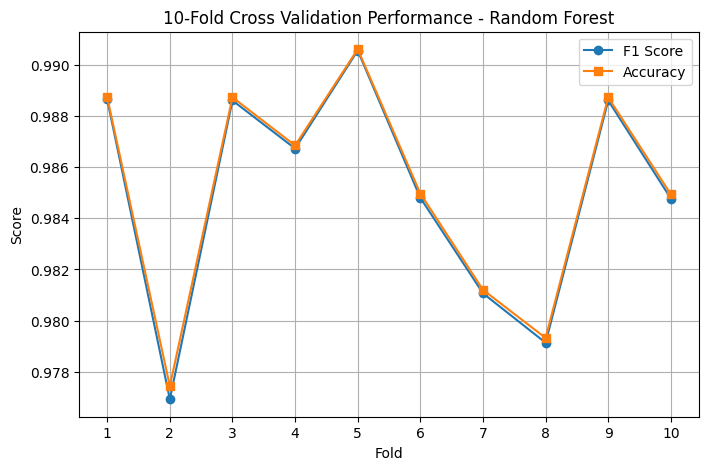

Log Loss  : 0.0559
Average Gini : 0.0631
Accuracy  : 0.9865
Precision : 0.9864
Recall    : 0.9865
F1 Score  : 0.9864

Classification Report

Per-Class Performance


,Precision,Recall,F1 Score,Support
Hard,0.9888,0.9944,0.9916,1417.0
Soft,0.9770,0.9551,0.9659,356.0



Confusion Matrix

Confusion Matrix


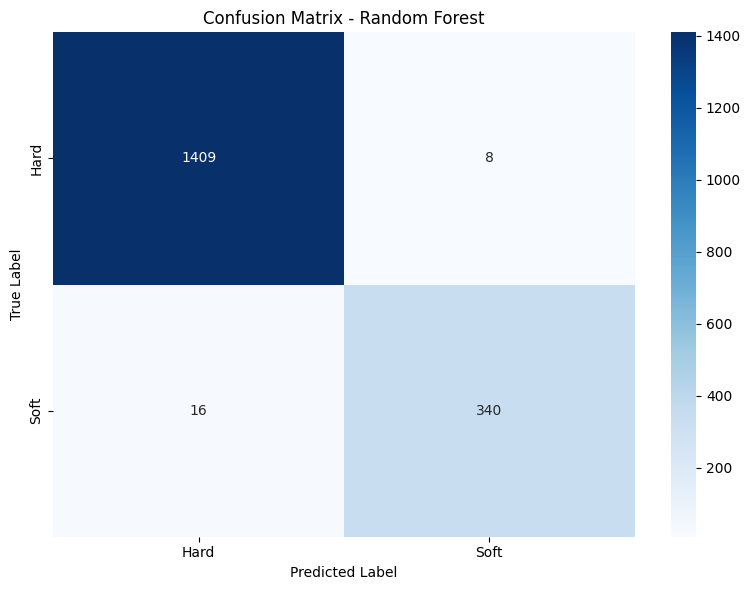


PREDICTING DATA
predicted_skill_category
Hard    10
Soft     1
Name: count, dtype: int64


,kategori,kode_cpl,kkni_level,kkni_no,text_clean,cleaned_text,embedding,predicted_skill_category,hard_probability_,soft_probability_
0,cpl,CPL-TIF-01,6,4,memiliki kepribadian yang beriman dan bertaqwa...,memiliki kepribadian beriman bertaqwa tuhan ym...,"[0.20160243, 0.32484177, -0.31375173, -0.11773...",Soft,0.317606,0.682394
1,cpl,CPL-TIF-02,6,1,mampu bersaing di pasar global dengan pengetah...,bersaing pasar global pengetahuan kemampuan me...,"[0.029390108, -0.1102278, -0.07882076, -0.2088...",Hard,0.947188,0.052812
2,cpl,CPL-TIF-03,6,2,memiliki pengetahuan yang memadai terkait deng...,memiliki pengetahuan memadai terkait membangun...,"[-0.06861273, -0.06098535, -0.13892269, -0.316...",Hard,0.955695,0.044305
3,cpl,CPL-TIF-04,6,2,mampu meningkatkan pengetahuan dan kemampuan t...,meningkatkan pengetahuan kemampuan terkait pem...,"[-0.10375646, -0.04385793, -0.27491203, -0.168...",Hard,0.998353,0.001647
4,cpl,CPL-TIF-05,6,3,mempunyai kemampuan komunikasi dalam mendefini...,kemampuan komunikasi mendefinisikan kebutuhan ...,"[0.012045132, 0.08171674, -0.08563674, -0.3004...",Hard,0.867422,0.132578
5,cpl,CPL-TIF-06,6,4,mampu membuat desain secara holistik sebuah mo...,desain holistik model arsitektur teknik inform...,"[-0.016050562, 0.23904411, -0.059285667, -0.07...",Hard,0.977165,0.022835
6,cpl,CPL-TIF-07,6,1,memiliki keahlian bidang bisnis dan teknologi ...,memiliki keahlian bidang bisnis teknologi kons...,"[0.25336283, 0.2555677, -0.0602213, -0.1101508...",Hard,0.970073,0.029927
7,cpl,CPL-TIF-08,6,1,mampu mengembangkan kepribadian yang berkualit...,mengembangkan kepribadian berkualitas berinteg...,"[0.025932448, 0.20587012, -0.21050242, -0.1650...",Hard,0.680056,0.319944
8,cpl,CPL-TIF-09,6,4,mampu berkontribusi dalam meningkatkan pemberd...,berkontribusi meningkatkan pemberdayaan masyar...,"[-0.01382813, 0.055728488, -0.30383846, -0.199...",Hard,0.922067,0.077933
9,cpl,CPL-TIF-10,6,3,mampu meningkatkan kemampuan komunikasi efekti...,meningkatkan kemampuan komunikasi efektif lisa...,"[0.07212796, 0.057537634, -0.26366046, -0.1292...",Hard,0.553416,0.446584


In [ ]:
# ============================================================
# RANDOM FOREST
# ============================================================

cpl_rf_model_result, cpl_rf_result_df, cpl_rf_metrics, cpl_rf_cv = evaluate_model(

    model=rf_model,

    param_grid=rf_param,

    model_name="Random Forest",

    X_train=X_train,

    y_train=y_train,

    X_test=X_test,

    y_test=y_test,

    prediction_embeddings=cpl_embeddings,

    prediction_dataframe=df_cpl

)


display(cpl_rf_result_df)

## Decision Tree


TRAINING Decision Tree
Fitting 3 folds for each of 18 candidates, totalling 54 fits

Best Parameters:
{'criterion': 'entropy', 'max_depth': 10, 'min_samples_split': 2}
Best CV Score:
0.9673

MODEL EVALUATION

10-Fold Cross Validation Results


,Fold,Accuracy,Precision,Recall,F1 Score
0,1,0.9774,0.9773,0.9774,0.9774
1,2,0.9624,0.9624,0.9624,0.9624
2,3,0.9586,0.9594,0.9586,0.9589
3,4,0.9793,0.9792,0.9793,0.9792
4,5,0.9605,0.9604,0.9605,0.9605
5,6,0.9737,0.9739,0.9737,0.9738
6,7,0.9850,0.9853,0.9850,0.9851
7,8,0.9643,0.9639,0.9643,0.9640
8,9,0.9699,0.9709,0.9699,0.9702
9,10,0.9699,0.9701,0.9699,0.9700



Cross Validation Summary


,Metric,Mean,Standard Deviation
0,Accuracy,0.9701,0.0083
1,Precision,0.9703,0.0083
2,Recall,0.9701,0.0083
3,F1 Score,0.9701,0.0083


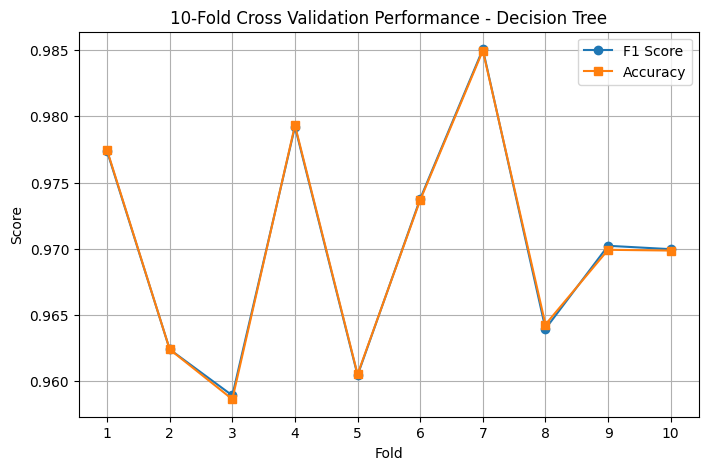

Log Loss  : 0.5993
Average Gini : 0.0012
Accuracy  : 0.9763
Precision : 0.9767
Recall    : 0.9763
F1 Score  : 0.9765

Classification Report

Per-Class Performance


,Precision,Recall,F1 Score,Support
Hard,0.9893,0.9809,0.9851,1417.0
Soft,0.9266,0.9579,0.9420,356.0



Confusion Matrix

Confusion Matrix


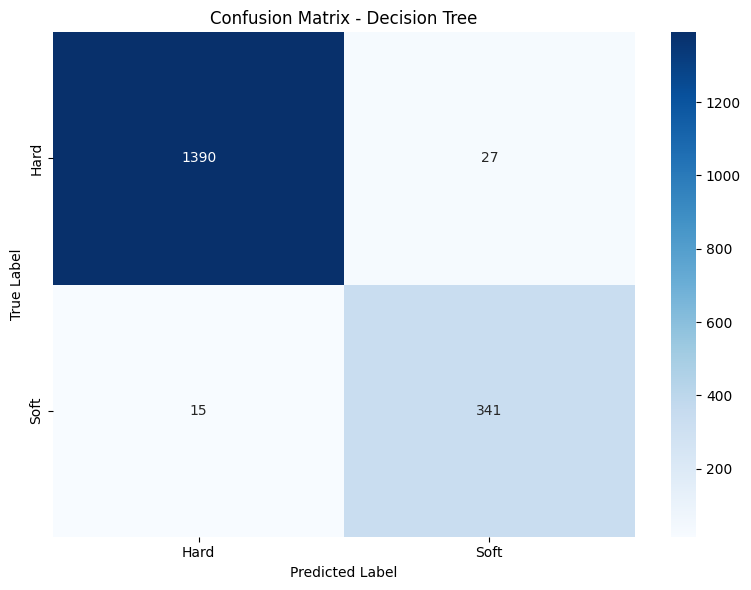


PREDICTING DATA
predicted_skill_category
Hard    9
Soft    2
Name: count, dtype: int64


,kategori,kode_cpl,kkni_level,kkni_no,text_clean,cleaned_text,embedding,predicted_skill_category,hard_probability_,soft_probability_
0,cpl,CPL-TIF-01,6,4,memiliki kepribadian yang beriman dan bertaqwa...,memiliki kepribadian beriman bertaqwa tuhan ym...,"[0.20160243, 0.32484177, -0.31375173, -0.11773...",Soft,0.000653,0.999347
1,cpl,CPL-TIF-02,6,1,mampu bersaing di pasar global dengan pengetah...,bersaing pasar global pengetahuan kemampuan me...,"[0.029390108, -0.1102278, -0.07882076, -0.2088...",Hard,1.000000,0.000000
2,cpl,CPL-TIF-03,6,2,memiliki pengetahuan yang memadai terkait deng...,memiliki pengetahuan memadai terkait membangun...,"[-0.06861273, -0.06098535, -0.13892269, -0.316...",Hard,1.000000,0.000000
3,cpl,CPL-TIF-04,6,2,mampu meningkatkan pengetahuan dan kemampuan t...,meningkatkan pengetahuan kemampuan terkait pem...,"[-0.10375646, -0.04385793, -0.27491203, -0.168...",Hard,1.000000,0.000000
4,cpl,CPL-TIF-05,6,3,mempunyai kemampuan komunikasi dalam mendefini...,kemampuan komunikasi mendefinisikan kebutuhan ...,"[0.012045132, 0.08171674, -0.08563674, -0.3004...",Hard,1.000000,0.000000
5,cpl,CPL-TIF-06,6,4,mampu membuat desain secara holistik sebuah mo...,desain holistik model arsitektur teknik inform...,"[-0.016050562, 0.23904411, -0.059285667, -0.07...",Hard,1.000000,0.000000
6,cpl,CPL-TIF-07,6,1,memiliki keahlian bidang bisnis dan teknologi ...,memiliki keahlian bidang bisnis teknologi kons...,"[0.25336283, 0.2555677, -0.0602213, -0.1101508...",Hard,1.000000,0.000000
7,cpl,CPL-TIF-08,6,1,mampu mengembangkan kepribadian yang berkualit...,mengembangkan kepribadian berkualitas berinteg...,"[0.025932448, 0.20587012, -0.21050242, -0.1650...",Hard,1.000000,0.000000
8,cpl,CPL-TIF-09,6,4,mampu berkontribusi dalam meningkatkan pemberd...,berkontribusi meningkatkan pemberdayaan masyar...,"[-0.01382813, 0.055728488, -0.30383846, -0.199...",Hard,1.000000,0.000000
9,cpl,CPL-TIF-10,6,3,mampu meningkatkan kemampuan komunikasi efekti...,meningkatkan kemampuan komunikasi efektif lisa...,"[0.07212796, 0.057537634, -0.26366046, -0.1292...",Soft,0.000000,1.000000


In [ ]:
cpl_dt_model_result, cpl_dt_result_df, cpl_dt_metrics, cpl_dt_cv = evaluate_model(

    model=dt_model,

    param_grid=dt_param,

    model_name="Decision Tree",

    X_train=X_train,

    y_train=y_train,

    X_test=X_test,

    y_test=y_test,

    prediction_embeddings=cpl_embeddings,

    prediction_dataframe=df_cpl

)

display(cpl_dt_result_df)

## Extra Trees


TRAINING Extra Trees
Fitting 3 folds for each of 24 candidates, totalling 72 fits

Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best CV Score:
0.9848

MODEL EVALUATION

10-Fold Cross Validation Results


,Fold,Accuracy,Precision,Recall,F1 Score
0,1,0.9906,0.9906,0.9906,0.9906
1,2,0.9831,0.9834,0.9831,0.9828
2,3,0.9887,0.9889,0.9887,0.9886
3,4,0.9850,0.9849,0.9850,0.9849
4,5,0.9887,0.9887,0.9887,0.9886
5,6,0.9868,0.9869,0.9868,0.9867
6,7,0.9812,0.9811,0.9812,0.9811
7,8,0.9793,0.9792,0.9793,0.9791
8,9,0.9868,0.9869,0.9868,0.9867
9,10,0.9849,0.9850,0.9849,0.9848



Cross Validation Summary


,Metric,Mean,Standard Deviation
0,Accuracy,0.9855,0.0034
1,Precision,0.9856,0.0034
2,Recall,0.9855,0.0034
3,F1 Score,0.9854,0.0034


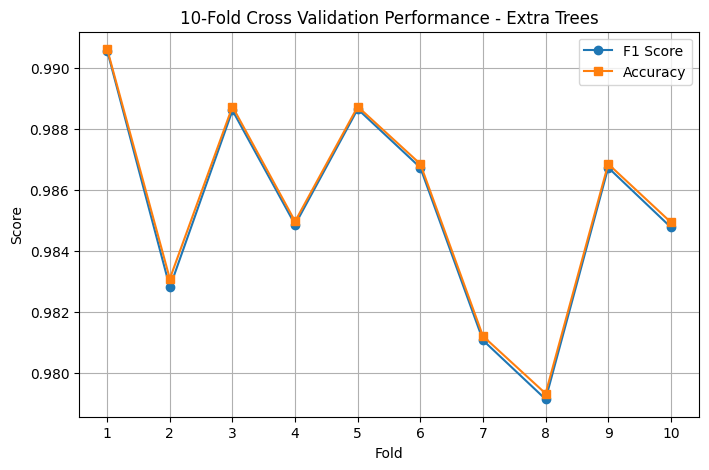

Log Loss  : 0.0774
Average Gini : 0.1041
Accuracy  : 0.9876
Precision : 0.9875
Recall    : 0.9876
F1 Score  : 0.9876

Classification Report

Per-Class Performance


,Precision,Recall,F1 Score,Support
Hard,0.9902,0.9944,0.9923,1417.0
Soft,0.9771,0.9607,0.9688,356.0



Confusion Matrix

Confusion Matrix


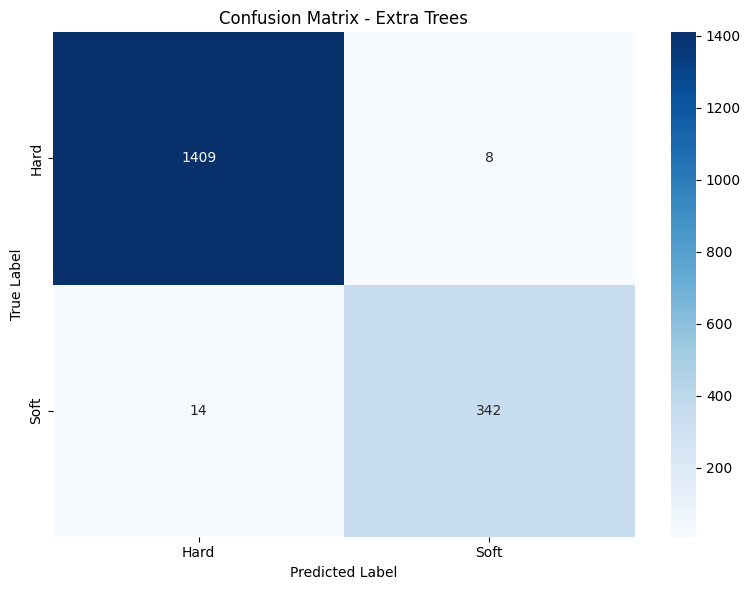


PREDICTING DATA
predicted_skill_category
Hard    10
Soft     1
Name: count, dtype: int64


,kategori,kode_cpl,kkni_level,kkni_no,text_clean,cleaned_text,embedding,predicted_skill_category,hard_probability_,soft_probability_
0,cpl,CPL-TIF-01,6,4,memiliki kepribadian yang beriman dan bertaqwa...,memiliki kepribadian beriman bertaqwa tuhan ym...,"[0.20160243, 0.32484177, -0.31375173, -0.11773...",Soft,0.330357,0.669643
1,cpl,CPL-TIF-02,6,1,mampu bersaing di pasar global dengan pengetah...,bersaing pasar global pengetahuan kemampuan me...,"[0.029390108, -0.1102278, -0.07882076, -0.2088...",Hard,0.908091,0.091909
2,cpl,CPL-TIF-03,6,2,memiliki pengetahuan yang memadai terkait deng...,memiliki pengetahuan memadai terkait membangun...,"[-0.06861273, -0.06098535, -0.13892269, -0.316...",Hard,0.908917,0.091083
3,cpl,CPL-TIF-04,6,2,mampu meningkatkan pengetahuan dan kemampuan t...,meningkatkan pengetahuan kemampuan terkait pem...,"[-0.10375646, -0.04385793, -0.27491203, -0.168...",Hard,0.975173,0.024827
4,cpl,CPL-TIF-05,6,3,mempunyai kemampuan komunikasi dalam mendefini...,kemampuan komunikasi mendefinisikan kebutuhan ...,"[0.012045132, 0.08171674, -0.08563674, -0.3004...",Hard,0.775137,0.224863
5,cpl,CPL-TIF-06,6,4,mampu membuat desain secara holistik sebuah mo...,desain holistik model arsitektur teknik inform...,"[-0.016050562, 0.23904411, -0.059285667, -0.07...",Hard,0.947782,0.052218
6,cpl,CPL-TIF-07,6,1,memiliki keahlian bidang bisnis dan teknologi ...,memiliki keahlian bidang bisnis teknologi kons...,"[0.25336283, 0.2555677, -0.0602213, -0.1101508...",Hard,0.876315,0.123685
7,cpl,CPL-TIF-08,6,1,mampu mengembangkan kepribadian yang berkualit...,mengembangkan kepribadian berkualitas berinteg...,"[0.025932448, 0.20587012, -0.21050242, -0.1650...",Hard,0.685755,0.314245
8,cpl,CPL-TIF-09,6,4,mampu berkontribusi dalam meningkatkan pemberd...,berkontribusi meningkatkan pemberdayaan masyar...,"[-0.01382813, 0.055728488, -0.30383846, -0.199...",Hard,0.885537,0.114463
9,cpl,CPL-TIF-10,6,3,mampu meningkatkan kemampuan komunikasi efekti...,meningkatkan kemampuan komunikasi efektif lisa...,"[0.07212796, 0.057537634, -0.26366046, -0.1292...",Hard,0.556556,0.443444


In [ ]:
cpl_et_model_result, cpl_et_result_df, cpl_et_metrics, cpl_bag_cv = evaluate_model(

    model=et_model,

    param_grid=et_param,

    model_name="Extra Trees",

    X_train=X_train,

    y_train=y_train,

    X_test=X_test,

    y_test=y_test,

    prediction_embeddings=cpl_embeddings,

    prediction_dataframe=df_cpl

)


display(cpl_et_result_df)

## Bagged Trees


TRAINING Bagged Trees
Fitting 3 folds for each of 1 candidates, totalling 3 fits

Best Parameters:
{}
Best CV Score:
0.9786

MODEL EVALUATION

10-Fold Cross Validation Results


,Fold,Accuracy,Precision,Recall,F1 Score
0,1,0.9850,0.9849,0.9850,0.9849
1,2,0.9699,0.9702,0.9699,0.9692
2,3,0.9831,0.9832,0.9831,0.9829
3,4,0.9812,0.9814,0.9812,0.9809
4,5,0.9868,0.9868,0.9868,0.9868
5,6,0.9850,0.9849,0.9850,0.9849
6,7,0.9774,0.9773,0.9774,0.9774
7,8,0.9868,0.9868,0.9868,0.9868
8,9,0.9868,0.9869,0.9868,0.9867
9,10,0.9812,0.9813,0.9812,0.9809



Cross Validation Summary


,Metric,Mean,Standard Deviation
0,Accuracy,0.9823,0.0051
1,Precision,0.9824,0.0050
2,Recall,0.9823,0.0051
3,F1 Score,0.9821,0.0052


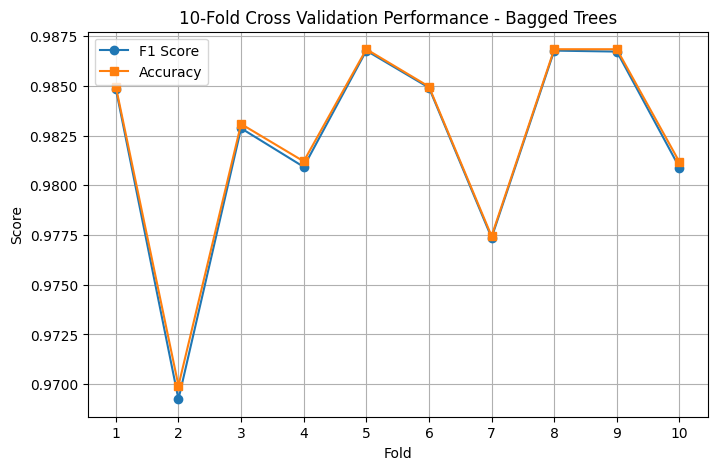

Log Loss  : 0.0628
Average Gini : 0.0392
Accuracy  : 0.9865
Precision : 0.9864
Recall    : 0.9865
F1 Score  : 0.9864

Classification Report

Per-Class Performance


,Precision,Recall,F1 Score,Support
Hard,0.9888,0.9944,0.9916,1417.0
Soft,0.9770,0.9551,0.9659,356.0



Confusion Matrix

Confusion Matrix


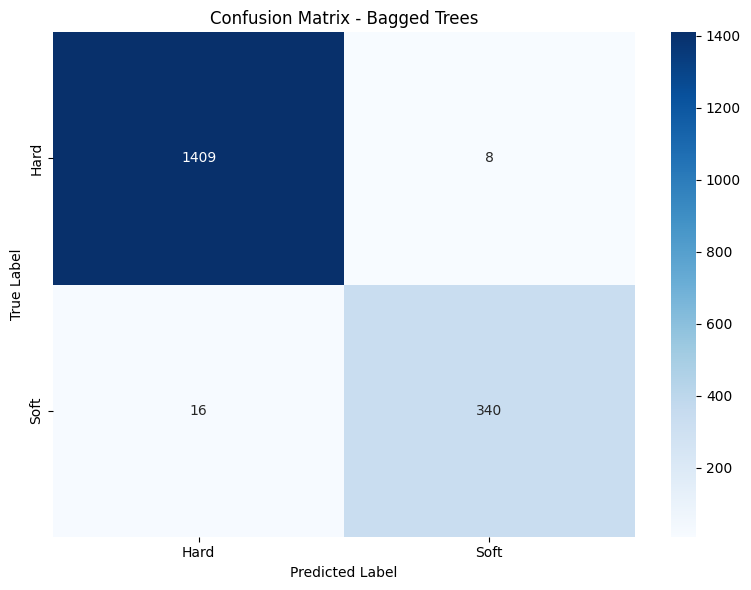


PREDICTING DATA
predicted_skill_category
Hard    10
Soft     1
Name: count, dtype: int64


,kategori,kode_cpl,kkni_level,kkni_no,text_clean,cleaned_text,embedding,predicted_skill_category,hard_probability_,soft_probability_
0,cpl,CPL-TIF-01,6,4,memiliki kepribadian yang beriman dan bertaqwa...,memiliki kepribadian beriman bertaqwa tuhan ym...,"[0.20160243, 0.32484177, -0.31375173, -0.11773...",Soft,0.16,0.84
1,cpl,CPL-TIF-02,6,1,mampu bersaing di pasar global dengan pengetah...,bersaing pasar global pengetahuan kemampuan me...,"[0.029390108, -0.1102278, -0.07882076, -0.2088...",Hard,0.95,0.05
2,cpl,CPL-TIF-03,6,2,memiliki pengetahuan yang memadai terkait deng...,memiliki pengetahuan memadai terkait membangun...,"[-0.06861273, -0.06098535, -0.13892269, -0.316...",Hard,0.95,0.05
3,cpl,CPL-TIF-04,6,2,mampu meningkatkan pengetahuan dan kemampuan t...,meningkatkan pengetahuan kemampuan terkait pem...,"[-0.10375646, -0.04385793, -0.27491203, -0.168...",Hard,1.00,0.00
4,cpl,CPL-TIF-05,6,3,mempunyai kemampuan komunikasi dalam mendefini...,kemampuan komunikasi mendefinisikan kebutuhan ...,"[0.012045132, 0.08171674, -0.08563674, -0.3004...",Hard,0.91,0.09
5,cpl,CPL-TIF-06,6,4,mampu membuat desain secara holistik sebuah mo...,desain holistik model arsitektur teknik inform...,"[-0.016050562, 0.23904411, -0.059285667, -0.07...",Hard,0.97,0.03
6,cpl,CPL-TIF-07,6,1,memiliki keahlian bidang bisnis dan teknologi ...,memiliki keahlian bidang bisnis teknologi kons...,"[0.25336283, 0.2555677, -0.0602213, -0.1101508...",Hard,0.94,0.06
7,cpl,CPL-TIF-08,6,1,mampu mengembangkan kepribadian yang berkualit...,mengembangkan kepribadian berkualitas berinteg...,"[0.025932448, 0.20587012, -0.21050242, -0.1650...",Hard,0.77,0.23
8,cpl,CPL-TIF-09,6,4,mampu berkontribusi dalam meningkatkan pemberd...,berkontribusi meningkatkan pemberdayaan masyar...,"[-0.01382813, 0.055728488, -0.30383846, -0.199...",Hard,0.96,0.04
9,cpl,CPL-TIF-10,6,3,mampu meningkatkan kemampuan komunikasi efekti...,meningkatkan kemampuan komunikasi efektif lisa...,"[0.07212796, 0.057537634, -0.26366046, -0.1292...",Hard,0.62,0.38


In [ ]:
cpl_bag_model_result, cpl_bag_result_df, cpl_bag_metrics, cpl_bag_cv = evaluate_model(

    model=bag_model,

    param_grid=bag_param,

    model_name="Bagged Trees",

    X_train=X_train,

    y_train=y_train,

    X_test=X_test,

    y_test=y_test,

    prediction_embeddings=cpl_embeddings,

    prediction_dataframe=df_cpl

)

display(cpl_bag_result_df)

## Metrics

In [ ]:
all_metrics = pd.DataFrame([
    cpl_rf_metrics,
    cpl_dt_metrics,
    cpl_et_metrics,
    cpl_bag_metrics
])

display(all_metrics.sort_values("F1", ascending=False))

,Model,Log Loss,Gini Impurity,Accuracy,Precision,Recall,F1,Hard Precision,Hard Recall,Hard F1,Soft Precision,Soft Recall,Soft F1
2,Extra Trees,0.077421,0.104060,0.987592,0.987548,0.987592,0.987552,0.990162,0.994354,0.992254,0.977143,0.960674,0.968839
0,Random Forest,0.055884,0.063105,0.986464,0.986411,0.986464,0.986406,0.988772,0.994354,0.991555,0.977011,0.955056,0.965909
3,Bagged Trees,0.062768,0.039153,0.986464,0.986411,0.986464,0.986406,0.988772,0.994354,0.991555,0.977011,0.955056,0.965909
1,Decision Tree,0.599290,0.001160,0.976311,0.976736,0.976311,0.976457,0.989324,0.980946,0.985117,0.926630,0.957865,0.941989


# RPS Mata Kuliah

## Manual

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import numpy as np

# ============================================================
# PARAMETERS
# ============================================================

TOP_K = 5 # Use top 3 most similar PON TIK competencies for classification
# SIMILARITY_THRESHOLD = 0.50 # Removed as per user request to use TOP_K instead of threshold

# ============================================================
# VALIDATION
# ============================================================

print("=" * 80)
print("VALIDATING DATA")
print("=" * 80)

print(f"Total Course Competencies (RPS) : {len(df_course_representation)}")
print(f"Total PON TIK Competencies      : {len(hierarchy_df)}")

print(f"Course Competency Embeddings    : {len(kompetensi_embeddings)}")
print(f"PON TIK Competency Embeddings   : {len(pon_tik_embeddings)}")

# ============================================================
# COSINE SIMILARITY CALCULATION
# ============================================================

print("\n" + "=" * 80)
print("CALCULATING COSINE SIMILARITY BETWEEN RPS AND PON TIK COMPETENCIES")
print("=" * 80)

similarity_matrix = cosine_similarity(
    kompetensi_embeddings,
    pon_tik_embeddings
)

print(f"Similarity Matrix Shape: {similarity_matrix.shape}")

# ============================================================
# MAPPING AND WEIGHTED VOTING
# ============================================================

print("\n" + "=" * 80)
print("PERFORMING MAPPING AND WEIGHTED VOTING")
print("=" * 80)

alignment_results = []

for i, course_row in df_course_representation.iterrows():
    course_text = course_row['combined_course_text']
    course_embedding = kompetensi_embeddings[i].tolist() # Get the embedding for the current course and convert to list
    current_course_similarities = similarity_matrix[i]

    # Get the TOP_K indices with the highest similarities
    # Ensure TOP_K does not exceed the number of available PON TIK competencies
    actual_top_k = min(TOP_K, len(hierarchy_df))
    top_k_indices = np.argsort(current_course_similarities)[::-1][:actual_top_k]

    # Initialize scores for weighted voting
    hard_score = 0.0
    soft_score = 0.0
    other_score = 0.0

    matched_pon_tik_competencies = [] # List to store actual competency units
    matched_categories = [] # List to store categories of matched competencies
    matched_similarities_list = [] # List to store individual similarity scores

    # Iterate only through the TOP_K most similar PON TIK competencies
    if actual_top_k > 0:
        for j_top_k_idx in top_k_indices:
            similarity = current_course_similarities[j_top_k_idx]
            pon_tik_row = hierarchy_df.iloc[j_top_k_idx]

            category = pon_tik_row['skill_category']
            competency_unit = pon_tik_row['competency_unit']

            matched_pon_tik_competencies.append(competency_unit)
            matched_categories.append(category)
            matched_similarities_list.append(round(similarity, 4))

            # Accumulate scores for weighted voting (no threshold check here, as specified by user)
            if category == 'Hard':
                hard_score += similarity
            elif category == 'Soft':
                soft_score += similarity
            elif category == 'Other':
                other_score += similarity

    # Determine final_skill_category based on weighted voting
    if len(matched_pon_tik_competencies) == 0:
        # This case would only happen if actual_top_k is 0 (i.e., hierarchy_df is empty)
        final_category = "Unknown"
    else:
        scores = {
            'Hard': hard_score,
            'Soft': soft_score,
            'Other': other_score
        }
        # Find the category with the highest accumulated similarity score
        sorted_scores = sorted(scores.items(), key=lambda item: item[1], reverse=True)
        final_category = sorted_scores[0][0]

    alignment_results.append({
        'course_code': course_row['course_code'],
        'course_name': course_row['course_name'],
        'combined_course_text': course_text,
        'course_embedding': course_embedding, # Add course embedding here
        'matched_count': len(matched_pon_tik_competencies), # This will be actual_top_k
        'matched_pon_tik': ' | '.join(matched_pon_tik_competencies),
        'matched_categories': ' | '.join(matched_categories),
        'matched_similarities': ' | '.join(map(str, matched_similarities_list)),
        'hard_score': round(hard_score, 4),
        'soft_score': round(soft_score, 4),
        'other_score': round(other_score, 4),
        'final_skill_category': final_category
    })

rps_skill_classification = pd.DataFrame(alignment_results)

print("Mapping and weighted voting completed.")

print("\n" + "=" * 80)
print("ANALYSIS: SKILL CATEGORY DISTRIBUTION")
print("=" * 80)

display(
rps_skill_classification[
        "final_skill_category"
    ].value_counts().to_frame()
)

print("\n" + "=" * 80)
print("ANALYSIS: MATCH COUNT STATISTICS")
print("=" * 80)

print(f"Average Matched Count: {rps_skill_classification['matched_count'].mean():.2f}")
print(f"Maximum Matched Count: {rps_skill_classification['matched_count'].max()}")
print(f"Minimum Matched Count: {rps_skill_classification['matched_count'].min()}")

display(
rps_skill_classification[
        "matched_count"
    ].describe().to_frame()
)

print("\n" + "=" * 80)
print("SAMPLE MAPPING RESULTS")
print("=" * 80)

# Display sample results, adjust number of rows as needed
display(
rps_skill_classification[
        [
            "course_name",
            "combined_course_text",
            "course_embedding", # Include the new column in display
            "matched_count",
            "final_skill_category",
            "hard_score",
            "soft_score",
            "other_score",
            "matched_pon_tik",
            "matched_categories",
            "matched_similarities"
        ]
    ]
)

unknown_courses = rps_skill_classification[rps_skill_classification['final_skill_category'] == 'Unknown']

if not unknown_courses.empty:
    print(f"Total Unknown Courses: {len(unknown_courses)}")
    display(unknown_courses[[
        'course_name',
        'combined_course_text',
        'course_embedding', # Include the new column in display
        'matched_count',
        'final_skill_category',
        'hard_score',
        'soft_score',
        'other_score',
        'matched_pon_tik',
        'matched_categories',
        'matched_similarities'
    ]])
else:
    print("No courses found with 'Unknown' skill category.")

# ============================================================
# SAVE
# ============================================================

# Define the output directory in Google Drive
GDrive_OUTPUT_DIR = '/content/drive/MyDrive/TA_Jennifer Felicia/DATASET/KURIKULUM/PROCESSED/kompetensi/'

# Create the directory if it doesn't exist
os.makedirs(GDrive_OUTPUT_DIR, exist_ok=True)

# Define the full path for the output file
output_file_gdrive = os.path.join(GDrive_OUTPUT_DIR, 'rps_skill_classification.csv')

rps_skill_classification.to_csv(
    output_file_gdrive,
    index=False,
    encoding="utf-8-sig"
)

print("\n" + "=" * 80)
print("FILE SAVED")
print("=" * 80)
print(output_file_gdrive)

## Random Forest

In [ ]:
# ============================================================
# RANDOM FOREST
# ============================================================

course_rf_model_result, course_rf_result_df, course_rf_metrics = evaluate_model(

    model=rf_model,

    param_grid=rf_param,

    model_name="Random Forest",

    X_train=X_train,

    y_train=y_train,

    X_test=X_test,

    y_test=y_test,

    prediction_embeddings=kompetensi_embeddings,

    prediction_dataframe=df_course_representation
)

display(course_rf_result_df)

## Decision Tree

In [ ]:
course_dt_model_result, course_dt_result_df, course_dt_metrics = evaluate_model(

    model=dt_model,

    param_grid=dt_param,

    model_name="Decision Tree",

    X_train=X_train,

    y_train=y_train,

    X_test=X_test,

    y_test=y_test,

    prediction_embeddings=kompetensi_embeddings,

    prediction_dataframe=df_course_representation

)

display(course_dt_result_df)

## Extra Trees

In [ ]:
course_et_model_result, course_et_result_df, course_et_metrics = evaluate_model(

    model=et_model,

    param_grid=et_param,

    model_name="Extra Trees",

    X_train=X_train,

    y_train=y_train,

    X_test=X_test,

    y_test=y_test,

    prediction_embeddings=kompetensi_embeddings,

    prediction_dataframe=df_course_representation

)


display(course_et_result_df)

## Bagged Trees

In [ ]:
course_bag_model_result, course_bag_result_df, course_bag_metrics = evaluate_model(

    model=bag_model,

    param_grid=bag_param,

    model_name="Bagged Trees",

    X_train=X_train,

    y_train=y_train,

    X_test=X_test,

    y_test=y_test,

    prediction_embeddings=kompetensi_embeddings,

    prediction_dataframe=df_course_representation

)

display(course_bag_result_df)

## Metrics

In [ ]:
all_metrics = pd.DataFrame([
    course_rf_metrics,
    course_dt_metrics,
    course_et_metrics,
    course_bag_metrics
])

display(all_metrics.sort_values("F1", ascending=False))

# STAKEHOLDER

In [ ]:
import pandas as pd
import os

# ==========================================================
# MOUNT GOOGLE DRIVE
# ==========================================================

from google.colab import drive
drive.mount('/content/drive')


# ==========================================================
# DATASET PATH
# ==========================================================

TRACER_STUDY_DATASET_PATH = (
    '/content/drive/MyDrive/TA_Jennifer Felicia/'
    'DATASET/TRACER STUDY/PROCESSED/'
)


# ==========================================================
# LOAD STAKEHOLDER VALIDATION
# ==========================================================

STAKEHOLDER_VALIDATION_PATH = (
    TRACER_STUDY_DATASET_PATH +
    'Stakeholder_Validation.xlsx'
)

df_validation = pd.read_excel(
    STAKEHOLDER_VALIDATION_PATH
)


# ==========================================================
# CHECK DATA
# ==========================================================

print("File:", STAKEHOLDER_VALIDATION_PATH)
print("Shape:", df_validation.shape)

display(df_validation.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
File: /content/drive/MyDrive/TA_Jennifer Felicia/DATASET/TRACER STUDY/PROCESSED/Stakeholder_Validation.xlsx
Shape: (4, 47)


,"Setelah membaca Visi dan Misi Program Studi, menurut Anda arah yang ingin dicapai Program Studi masih selaras dengan perkembangan dunia kerja bidang Computing saat ini.","Setelah membaca Profil Lulusan Program Studi, menurut Anda profil lulusan tersebut telah selaras dengan kompetensi yang dibutuhkan di dunia kerja bidang Computing saat ini.",Profil Lulusan Program Studi telah menggambarkan kompetensi yang saya gunakan dalam pekerjaan saat ini.,"Menurut Anda, masih terdapat kompetensi penting yang belum tercantum dalam Profil Lulusan Program Studi.","Berdasarkan pengalaman Anda, saya setuju bahwa Profil Lulusan Program Studi masih perlu diselaraskan dengan Visi dan Misi Program Studi.","Berdasarkan pengalaman saya bekerja, saya setuju bahwa Profil Lulusan Program Studi masih perlu diselaraskan dengan kebutuhan dunia kerja bidang Computing saat ini.",Saya setuju bahwa Profil Lulusan Program Studi perlu dievaluasi secara berkala agar tetap mengikuti perkembangan teknologi dan kebutuhan industri bidang Computing.,Program Studi perlu melibatkan masukan alumni dalam penyusunan maupun evaluasi Profil Lulusan.,Program Studi perlu mempertimbangkan kebutuhan industri bidang Computing dalam penyusunan maupun evaluasi Profil Lulusan.,Profil Lulusan Program Studi perlu diperbarui secara berkala mengikuti perkembangan teknologi.,...,Apakah Anda setuju bahwa pelaksanaan pembelajaran perlu dimonitor dan dievaluasi secara berkala agar tetap selaras dengan RPS dan tujuan pembelajaran?,"Berdasarkan pengalaman Anda, apakah rekomendasi untuk melakukan evaluasi menyeluruh terhadap pelaksanaan perkuliahan, implementasi materi pembelajaran, dan monitoring pembelajaran secara berkala sudah sesuai dengan kondisi yang Anda alami selama perkuliahan?","Menurut Anda, apakah masih terdapat mata kuliah yang pelaksanaan pembelajarannya tidak selaras dengan RPS atau tujuan pembelajaran? Jika Ya: sebutkan mata kuliah tersebut dan jelaskan secara singkat.",Apakah Anda memiliki saran untuk meningkatkan pelaksanaan pembelajaran di Program Studi Teknik Informatika?,"Menurut Anda, apakah hasil evaluasi MACA yang menyatakan bahwa proses studi mahasiswa secara umum telah sesuai dengan target masa studi (4tahun) sudah menggambarkan kondisi yang sebenarnya?","Menurut Anda, apakah proses akademik di Program Studi Teknik Informatika telah mendukung mahasiswa untuk dapat lulus tepat waktu?","Selama menjalani perkuliahan, apakah Anda pernah mengalami kendala yang berpotensi memperpanjang masa studi?","Jika anda menjawab ""Ya"" di pertanyaan sebelumnya, kendala apa yang paling berpengaruh terhadap masa studi Anda?","Menurut Anda, apakah monitoring akademik dan pendampingan dari Program Studi perlu terus ditingkatkan agar mahasiswa dapat lulus tepat waktu?","Menurut Anda, apa yang perlu dilakukan Program Studi agar mahasiswa dapat menyelesaikan studi tepat waktu?"
0,2,2,2,2,3,5,5,5,5,5,...,4,4,-,-,3,4,Tidak,NaN,5,Lebih perhatian lagi ke mahasiswa untuk sering...
1,4,4,4,3,3,3,4,3,4,4,...,4,4,Tidak,Mungkin lebih banyak praktikum,2,4,Tidak,NaN,4,"Monitoring akademik, membuat program yang mena..."
2,5,5,5,5,5,5,5,5,5,5,...,5,4,Tidak,sudah baik,4,5,Tidak,NaN,4,Memberikan bimbingan yang lebih intensif serta...
3,4,3,4,3,4,4,5,4,4,5,...,4,3,Ya. Pada beberapa mata kuliah praktikum dan te...,Prodi perlu memperketat pemantauan journaling ...,4,4,Tidak,NaN,4,Program Studi perlu mengoptimalkan peran Dosen...


In [ ]:
# ==========================================================
# MEMBAGI PERTANYAAN BERDASARKAN ASPEK VALIDASI
# ==========================================================

# Clean column names of df_validation to ensure exact matching
df_validation.columns = df_validation.columns.str.strip().str.replace(r'\s+', ' ', regex=True)

validation_aspects = {

    # ======================================================
    # PROFIL LULUSAN
    # ======================================================

    "Graduate Profiles": [

        "Berdasarkan pengalaman Anda, saya setuju bahwa Profil Lulusan Program Studi masih perlu diselaraskan dengan Visi dan Misi Program Studi.",

        "Berdasarkan pengalaman saya bekerja, saya setuju bahwa Profil Lulusan Program Studi masih perlu diselaraskan dengan kebutuhan dunia kerja bidang Computing saat ini.",

        "Saya setuju bahwa Profil Lulusan Program Studi perlu dievaluasi secara berkala agar tetap mengikuti perkembangan teknologi dan kebutuhan industri bidang Computing.",

        "Program Studi perlu melibatkan masukan alumni dalam penyusunan maupun evaluasi Profil Lulusan.",

        "Program Studi perlu mempertimbangkan kebutuhan industri bidang Computing dalam penyusunan maupun evaluasi Profil Lulusan.",

        "Profil Lulusan Program Studi perlu diperbarui secara berkala mengikuti perkembangan teknologi.",

        # ===== Pertanyaan terbuka =====
        "Menurut Anda, kompetensi apa yang perlu ditambahkan atau diperkuat dalam Profil Lulusan agar lebih sesuai dengan kebutuhan dunia kerja bidang Computing?",

        "Apakah terdapat bagian dari Profil Lulusan yang menurut Anda sudah tidak relevan? Mohon jelaskan."

    ],

    # ======================================================
    # CPL
    # ======================================================

    "CPL": [

        "Berdasarkan pengalaman Anda, saya setuju bahwa Capaian Pembelajaran Lulusan (CPL) Program Studi masih perlu diselaraskan dengan standar KKNI.",

        "Berdasarkan pengalaman Anda, saya setuju bahwa sebagian besar Mata Kuliah Program Studi sudah sesuai dengan standar KKNI.",

        "Berdasarkan pengalaman Anda, saya setuju bahwa Capaian Pembelajaran Lulusan (CPL) Program Studi telah cukup selaras dengan kebutuhan kompetensi dunia kerja bidang Computing.",

        "Berdasarkan pengalaman Anda, saya setuju bahwa Mata Kuliah Program Studi masih perlu diperkuat agar lebih selaras dengan kebutuhan industri bidang Computing.",

        "Berdasarkan pengalaman Anda, saya setuju bahwa Capaian Pembelajaran Lulusan (CPL) masih perlu ditingkatkan agar lebih selaras dengan Mata Kuliah.",

        "Berdasarkan pengalaman Anda, saya setuju bahwa kompetensi komunikasi dan kerja sama tim yang tergolong sebagai kompetensi Soft Skill masih perlu diperkuat dalam kurikulum.",

        "Secara keseluruhan, hasil evaluasi yang dihasilkan Framework MACA telah menggambarkan kondisi kurikulum Program Studi Teknik Informatika selaras dengan pengalaman Anda selama kuliah dan bekerja.",

        # ===== Pertanyaan terbuka =====

        "Kompetensi apa yang menurut Anda perlu ditambahkan atau diperkuat dalam CPL Program Studi?",

        "Mata kuliah apa yang menurut Anda paling perlu diperbarui agar lebih selaras dengan kebutuhan dunia kerja bidang Computing? Jelaskan alasannya.",

        "Menurut Anda, apakah terdapat kompetensi lain yang belum tercakup dalam kurikulum tetapi saat ini penting di dunia kerja bidang Computing?"

    ],

    # ======================================================
    # ASESMEN PEMBELAJARAN
    # ======================================================

    "Assessment": [

        "Menurut Anda, apakah hasil evaluasi asesmen pembelajaran yang ditampilkan telah menggambarkan kondisi pembelajaran yang Anda alami selama kuliah?",

        "Berdasarkan pengalaman Anda, saya setuju bahwa secara umum capaian hasil belajar mahasiswa berada pada kategori baik hingga sangat baik.",

        "Berdasarkan pengalaman Anda, saya setuju bahwa sebagian besar mahasiswa telah memenuhi persyaratan kelulusan, meskipun masih terdapat beberapa mahasiswa yang belum memenuhi seluruh persyaratan akademik.",

        "Berdasarkan pengalaman Anda, saya setuju bahwa CPL-03, CPL-04, CPL-05, CPL-06, dan CPL-07 merupakan capaian pembelajaran yang masih perlu diperkuat oleh Program Studi.",

        "Menurut Anda, apakah penguatan CPL tersebut sebaiknya dilakukan melalui peningkatan aktivitas pembelajaran (misalnya praktikum, studi kasus, atau project), sehingga pencapaian kompetensi mahasiswa menjadi lebih optimal?",

        "Berdasarkan pengalaman Anda, saya setuju bahwa capaian soft skill sudah baik, sedangkan beberapa hard skill masih memerlukan peningkatan.",

        "Menurut Anda, apakah evaluasi asesmen pembelajaran perlu dilakukan secara berkala agar kurikulum tetap sesuai dengan kebutuhan mahasiswa dan dunia kerja bidang Computing?",

        # ===== Pertanyaan terbuka =====

        "Apakah Anda memiliki saran terkait pelaksanaan asesmen pembelajaran atau peningkatan pencapaian CPL di Program Studi Teknik Informatika Universitas Bakrie?"

    ],

    # ======================================================
    # PELAKSANAAN PEMBELAJARAN
    # ======================================================

    "Learning Implementation": [

        "Berdasarkan pengalaman Anda, saya setuju bahwa sebagian besar mata kuliah telah melaksanakan seluruh pertemuan sesuai ketentuan.",

        "Menurut Anda, apakah Program Studi tetap perlu melakukan monitoring pelaksanaan perkuliahan secara berkala meskipun tingkat kelengkapan pertemuan sudah sangat baik?",

        "Berdasarkan pengalaman Anda, saya setuju bahwa kesesuaian materi yang diajarkan dosen selama perkuliahan dengan topik yang tercantum pada RPS atau silabus matakuliah masih rendah sehingga diperlukan evaluasi.",

        "Apakah Anda setuju bahwa pelaksanaan pembelajaran perlu dimonitor dan dievaluasi secara berkala agar tetap selaras dengan RPS dan tujuan pembelajaran?",

        "Berdasarkan pengalaman Anda, apakah rekomendasi untuk melakukan evaluasi menyeluruh terhadap pelaksanaan perkuliahan, implementasi materi pembelajaran, dan monitoring pembelajaran secara berkala sudah sesuai dengan kondisi yang Anda alami selama perkuliahan?",

        # ===== Pertanyaan terbuka =====

        "Menurut Anda, apakah masih terdapat mata kuliah yang pelaksanaan pembelajarannya tidak selaras dengan RPS atau tujuan pembelajaran? Jika Ya: sebutkan mata kuliah tersebut dan jelaskan secara singkat.",

        "Apakah Anda memiliki saran untuk meningkatkan pelaksanaan pembelajaran di Program Studi Teknik Informatika?"

    ],

    # ======================================================
    # MASA STUDI
    # ======================================================

    "Study Duration": [

        "Menurut Anda, apakah hasil evaluasi MACA yang menyatakan bahwa proses studi mahasiswa secara umum telah sesuai dengan target masa studi (4tahun) sudah menggambarkan kondisi yang sebenarnya?",

        "Menurut Anda, apakah proses akademik di Program Studi Teknik Informatika telah mendukung mahasiswa untuk dapat lulus tepat waktu?",

        "Selama menjalani perkuliahan, apakah Anda pernah mengalami kendala yang berpotensi memperpanjang masa studi?",

        "Jika anda menjawab \"Ya\" di pertanyaan sebelumnya, kendala apa yang paling berpengaruh terhadap masa studi Anda?",

        "Menurut Anda, apakah monitoring akademik dan pendampingan dari Program Studi perlu terus ditingkatkan agar mahasiswa dapat lulus tepat waktu?",

        "Menurut Anda, apa yang perlu dilakukan Program Studi agar mahasiswa dapat menyelesaikan studi tepat waktu?"

    ]

}

# ==========================================================
# MEMBUAT DATAFRAME PER ASPEK
# ==========================================================

validation_data = {}

for aspect, columns in validation_aspects.items():

    validation_data[aspect] = df_validation[columns]

    print(f"{aspect:30s} : {validation_data[aspect].shape}")

Graduate Profiles              : (4, 8)
CPL                            : (4, 10)
Assessment                     : (4, 8)
Learning Implementation        : (4, 7)
Study Duration                 : (4, 6)


In [ ]:
exclude_questions = {

    "Graduate Profiles": [
        "Setelah membaca Visi dan Misi Program Studi, menurut Anda arah yang ingin dicapai Program Studi masih selaras dengan perkembangan dunia kerja bidang Computing saat ini.",

        "Setelah membaca Profil Lulusan Program Studi, menurut Anda profil lulusan tersebut telah selaras dengan kompetensi yang dibutuhkan di dunia kerja bidang Computing saat ini.",

        "Profil Lulusan Program Studi telah menggambarkan kompetensi yang saya gunakan dalam pekerjaan saat ini.",

        "Menurut Anda, masih terdapat kompetensi penting yang belum tercantum dalam Profil Lulusan Program Studi.",
    ],

    "CPL": [
        "Menurut Anda, CPL yang ditetapkan Program Studi telah menggambarkan kompetensi yang minimum dimiliki oleh lulusan Teknik Informatika.",

        "Menurut Anda, masih terdapat CPL yang perlu diperbarui agar lebih selaras dengan perkembangan teknologi dan kebutuhan industri bidang Computing.",

        "Menurut Anda, mata kuliah yang Anda tempuh telah mendukung pencapaian kompetensi lulusan.",

        "Menurut Anda, masih terdapat mata kuliah yang perlu diperbarui agar lebih selaras dengan kebutuhan dunia kerja bidang Computing.",
    ]
}

validation_data_maca = {}

for aspect, data in validation_data.items():

    if aspect in exclude_questions:

        cols_to_keep = [
            col for col in data.columns
            if col not in exclude_questions[aspect]
        ]

        validation_data_maca[aspect] = data[cols_to_keep]

    else:

        validation_data_maca[aspect] = data.copy()

for aspect, data in validation_data_maca.items():

    print("\n" + "="*80)
    print(aspect)
    print("="*80)

    print("Jumlah pertanyaan:", len(data.columns))

    for i, col in enumerate(data.columns, 1):
        print(f"{i}. {col}")


Graduate Profiles
Jumlah pertanyaan: 8
1. Berdasarkan pengalaman Anda, saya setuju bahwa Profil Lulusan Program Studi masih perlu diselaraskan dengan Visi dan Misi Program Studi.
2. Berdasarkan pengalaman saya bekerja, saya setuju bahwa Profil Lulusan Program Studi masih perlu diselaraskan dengan kebutuhan dunia kerja bidang Computing saat ini.
3. Saya setuju bahwa Profil Lulusan Program Studi perlu dievaluasi secara berkala agar tetap mengikuti perkembangan teknologi dan kebutuhan industri bidang Computing.
4. Program Studi perlu melibatkan masukan alumni dalam penyusunan maupun evaluasi Profil Lulusan.
5. Program Studi perlu mempertimbangkan kebutuhan industri bidang Computing dalam penyusunan maupun evaluasi Profil Lulusan.
6. Profil Lulusan Program Studi perlu diperbarui secara berkala mengikuti perkembangan teknologi.
7. Menurut Anda, kompetensi apa yang perlu ditambahkan atau diperkuat dalam Profil Lulusan agar lebih sesuai dengan kebutuhan dunia kerja bidang Computing?
8. Apaka

In [ ]:
for aspect, data in validation_data_maca.items():
    print("\n" + "="*80)
    print(aspect)
    print("="*80)
    display(data.head())


Graduate Profiles


,"Berdasarkan pengalaman Anda, saya setuju bahwa Profil Lulusan Program Studi masih perlu diselaraskan dengan Visi dan Misi Program Studi.","Berdasarkan pengalaman saya bekerja, saya setuju bahwa Profil Lulusan Program Studi masih perlu diselaraskan dengan kebutuhan dunia kerja bidang Computing saat ini.",Saya setuju bahwa Profil Lulusan Program Studi perlu dievaluasi secara berkala agar tetap mengikuti perkembangan teknologi dan kebutuhan industri bidang Computing.,Program Studi perlu melibatkan masukan alumni dalam penyusunan maupun evaluasi Profil Lulusan.,Program Studi perlu mempertimbangkan kebutuhan industri bidang Computing dalam penyusunan maupun evaluasi Profil Lulusan.,Profil Lulusan Program Studi perlu diperbarui secara berkala mengikuti perkembangan teknologi.,"Menurut Anda, kompetensi apa yang perlu ditambahkan atau diperkuat dalam Profil Lulusan agar lebih sesuai dengan kebutuhan dunia kerja bidang Computing?",Apakah terdapat bagian dari Profil Lulusan yang menurut Anda sudah tidak relevan? Mohon jelaskan.
0,3,5,5,5,5,5,Banyakan praktek bisa melalui tugas project en...,-
1,3,3,4,3,4,4,Menurut saya profil lulusan sudah cukup sesuai...,Semua masih relevan tergantung tujuan dari set...
2,5,5,5,5,5,5,Sudah cukup baik,Tidak ada
3,4,4,5,4,4,5,Penguatan pada praktik penggunaan tools/framew...,"Secara umum masih relevan, namun pendekatan ma..."



CPL


,"Berdasarkan pengalaman Anda, saya setuju bahwa Capaian Pembelajaran Lulusan (CPL) Program Studi masih perlu diselaraskan dengan standar KKNI.","Berdasarkan pengalaman Anda, saya setuju bahwa sebagian besar Mata Kuliah Program Studi sudah sesuai dengan standar KKNI.","Berdasarkan pengalaman Anda, saya setuju bahwa Capaian Pembelajaran Lulusan (CPL) Program Studi telah cukup selaras dengan kebutuhan kompetensi dunia kerja bidang Computing.","Berdasarkan pengalaman Anda, saya setuju bahwa Mata Kuliah Program Studi masih perlu diperkuat agar lebih selaras dengan kebutuhan industri bidang Computing.","Berdasarkan pengalaman Anda, saya setuju bahwa Capaian Pembelajaran Lulusan (CPL) masih perlu ditingkatkan agar lebih selaras dengan Mata Kuliah.","Berdasarkan pengalaman Anda, saya setuju bahwa kompetensi komunikasi dan kerja sama tim yang tergolong sebagai kompetensi Soft Skill masih perlu diperkuat dalam kurikulum.","Secara keseluruhan, hasil evaluasi yang dihasilkan Framework MACA telah menggambarkan kondisi kurikulum Program Studi Teknik Informatika selaras dengan pengalaman Anda selama kuliah dan bekerja.",Kompetensi apa yang menurut Anda perlu ditambahkan atau diperkuat dalam CPL Program Studi?,Mata kuliah apa yang menurut Anda paling perlu diperbarui agar lebih selaras dengan kebutuhan dunia kerja bidang Computing? Jelaskan alasannya.,"Menurut Anda, apakah terdapat kompetensi lain yang belum tercakup dalam kurikulum tetapi saat ini penting di dunia kerja bidang Computing?"
0,3,5,5,2,3,3,4,-,"Tidak ada, sudah cukup.",Tidak ada
1,3,4,4,4,3,4,4,"Komunikasi,kerja sama tim, analisis dan proble...",Tidak ada,"Tidak ada, sudah mencakup semua"
2,4,4,5,4,5,4,5,Tidak Ada,AI,Sudah tercakup semua
3,4,4,4,5,4,5,4,"Penguatan soft skills (komunikasi teknis, team...",Mata kuliah Rekayasa Perangkat Lunak dan Basis...,"Pemahaman penerapan Generative AI, manajemen p..."



Assessment


,"Menurut Anda, apakah hasil evaluasi asesmen pembelajaran yang ditampilkan telah menggambarkan kondisi pembelajaran yang Anda alami selama kuliah?","Berdasarkan pengalaman Anda, saya setuju bahwa secara umum capaian hasil belajar mahasiswa berada pada kategori baik hingga sangat baik.","Berdasarkan pengalaman Anda, saya setuju bahwa sebagian besar mahasiswa telah memenuhi persyaratan kelulusan, meskipun masih terdapat beberapa mahasiswa yang belum memenuhi seluruh persyaratan akademik.","Berdasarkan pengalaman Anda, saya setuju bahwa CPL-03, CPL-04, CPL-05, CPL-06, dan CPL-07 merupakan capaian pembelajaran yang masih perlu diperkuat oleh Program Studi.","Menurut Anda, apakah penguatan CPL tersebut sebaiknya dilakukan melalui peningkatan aktivitas pembelajaran (misalnya praktikum, studi kasus, atau project), sehingga pencapaian kompetensi mahasiswa menjadi lebih optimal?","Berdasarkan pengalaman Anda, saya setuju bahwa capaian soft skill sudah baik, sedangkan beberapa hard skill masih memerlukan peningkatan.","Menurut Anda, apakah evaluasi asesmen pembelajaran perlu dilakukan secara berkala agar kurikulum tetap sesuai dengan kebutuhan mahasiswa dan dunia kerja bidang Computing?",Apakah Anda memiliki saran terkait pelaksanaan asesmen pembelajaran atau peningkatan pencapaian CPL di Program Studi Teknik Informatika Universitas Bakrie?
0,4,5,4,3,5,5,5,Tidak ada
1,4,4,4,4,4,4,4,Belum ada
2,4,4,4,5,4,4,5,Sudah baik
3,4,3,4,4,4,5,4,Perbanyak porsi pembelajaran berbasis proyek n...



Learning Implementation


,"Berdasarkan pengalaman Anda, saya setuju bahwa sebagian besar mata kuliah telah melaksanakan seluruh pertemuan sesuai ketentuan.","Menurut Anda, apakah Program Studi tetap perlu melakukan monitoring pelaksanaan perkuliahan secara berkala meskipun tingkat kelengkapan pertemuan sudah sangat baik?","Berdasarkan pengalaman Anda, saya setuju bahwa kesesuaian materi yang diajarkan dosen selama perkuliahan dengan topik yang tercantum pada RPS atau silabus matakuliah masih rendah sehingga diperlukan evaluasi.",Apakah Anda setuju bahwa pelaksanaan pembelajaran perlu dimonitor dan dievaluasi secara berkala agar tetap selaras dengan RPS dan tujuan pembelajaran?,"Berdasarkan pengalaman Anda, apakah rekomendasi untuk melakukan evaluasi menyeluruh terhadap pelaksanaan perkuliahan, implementasi materi pembelajaran, dan monitoring pembelajaran secara berkala sudah sesuai dengan kondisi yang Anda alami selama perkuliahan?","Menurut Anda, apakah masih terdapat mata kuliah yang pelaksanaan pembelajarannya tidak selaras dengan RPS atau tujuan pembelajaran? Jika Ya: sebutkan mata kuliah tersebut dan jelaskan secara singkat.",Apakah Anda memiliki saran untuk meningkatkan pelaksanaan pembelajaran di Program Studi Teknik Informatika?
0,5,4,2,4,4,-,-
1,4,4,3,4,4,Tidak,Mungkin lebih banyak praktikum
2,4,5,4,5,4,Tidak,sudah baik
3,4,4,4,4,3,Ya. Pada beberapa mata kuliah praktikum dan te...,Prodi perlu memperketat pemantauan journaling ...



Study Duration


,"Menurut Anda, apakah hasil evaluasi MACA yang menyatakan bahwa proses studi mahasiswa secara umum telah sesuai dengan target masa studi (4tahun) sudah menggambarkan kondisi yang sebenarnya?","Menurut Anda, apakah proses akademik di Program Studi Teknik Informatika telah mendukung mahasiswa untuk dapat lulus tepat waktu?","Selama menjalani perkuliahan, apakah Anda pernah mengalami kendala yang berpotensi memperpanjang masa studi?","Jika anda menjawab ""Ya"" di pertanyaan sebelumnya, kendala apa yang paling berpengaruh terhadap masa studi Anda?","Menurut Anda, apakah monitoring akademik dan pendampingan dari Program Studi perlu terus ditingkatkan agar mahasiswa dapat lulus tepat waktu?","Menurut Anda, apa yang perlu dilakukan Program Studi agar mahasiswa dapat menyelesaikan studi tepat waktu?"
0,3,4,Tidak,NaN,5,Lebih perhatian lagi ke mahasiswa untuk sering...
1,2,4,Tidak,NaN,4,"Monitoring akademik, membuat program yang mena..."
2,4,5,Tidak,NaN,4,Memberikan bimbingan yang lebih intensif serta...
3,4,4,Tidak,NaN,4,Program Studi perlu mengoptimalkan peran Dosen...


In [ ]:
open_ended_questions = [

    # Profil Lulusan
    "Menurut Anda, kompetensi apa yang perlu ditambahkan atau diperkuat dalam Profil Lulusan agar lebih sesuai dengan kebutuhan dunia kerja bidang Computing?",
    "Apakah terdapat bagian dari Profil Lulusan yang menurut Anda sudah tidak relevan? Mohon jelaskan.",

    # CPL
    "Kompetensi apa yang menurut Anda perlu ditambahkan atau diperkuat dalam CPL Program Studi?",
    "Mata kuliah apa yang menurut Anda paling perlu diperbarui agar lebih selaras dengan kebutuhan dunia kerja bidang Computing? Jelaskan alasannya.",
    "Menurut Anda, apakah terdapat kompetensi lain yang belum tercakup dalam kurikulum tetapi saat ini penting di dunia kerja bidang Computing?",

    # Asesmen
    "Apakah Anda memiliki saran terkait pelaksanaan asesmen pembelajaran atau peningkatan pencapaian CPL di Program Studi Teknik Informatika Universitas Bakrie?",

    # Pelaksanaan
    "Menurut Anda, apakah masih terdapat mata kuliah yang pelaksanaan pembelajarannya tidak selaras dengan RPS atau tujuan pembelajaran? Jika Ya: sebutkan mata kuliah tersebut dan jelaskan secara singkat.",
    "Apakah Anda memiliki saran untuk meningkatkan pelaksanaan pembelajaran di Program Studi Teknik Informatika?",

    # Masa Studi
    "Jika anda menjawab \"Ya\" di pertanyaan sebelumnya, kendala apa yang paling berpengaruh terhadap masa studi Anda?",
    "Menurut Anda, apa yang perlu dilakukan Program Studi agar mahasiswa dapat menyelesaikan studi tepat waktu?"
]

validation_likert = {}
validation_open = {}

for aspect, data in validation_data_maca.items():

    likert_cols = [
        col for col in data.columns
        if col not in open_ended_questions
    ]

    open_cols = [
        col for col in data.columns
        if col in open_ended_questions
    ]

    validation_likert[aspect] = data[likert_cols]
    validation_open[aspect] = data[open_cols]

for aspect in validation_data_maca.keys():

    print("\n" + "="*80)
    print(aspect)
    print("="*80)

    print("Pertanyaan Likert :", len(validation_likert[aspect].columns))
    print("Pertanyaan terbuka:", len(validation_open[aspect].columns))


Graduate Profiles
Pertanyaan Likert : 6
Pertanyaan terbuka: 2

CPL
Pertanyaan Likert : 7
Pertanyaan terbuka: 3

Assessment
Pertanyaan Likert : 7
Pertanyaan terbuka: 1

Learning Implementation
Pertanyaan Likert : 5
Pertanyaan terbuka: 2

Study Duration
Pertanyaan Likert : 4
Pertanyaan terbuka: 2


In [ ]:
for aspect, data in validation_likert.items():

    print("\n" + "="*80)
    print(aspect)
    print("="*80)

    for col in data.columns:

        print("\n", col)
        print(data[col].value_counts(dropna=False))


Graduate Profiles

 Berdasarkan pengalaman Anda, saya setuju bahwa Profil Lulusan Program Studi masih perlu diselaraskan dengan Visi dan Misi Program Studi.
Berdasarkan pengalaman Anda, saya setuju bahwa Profil Lulusan Program Studi masih perlu diselaraskan dengan Visi dan Misi Program Studi.
3    2
5    1
4    1
Name: count, dtype: int64

 Berdasarkan pengalaman saya bekerja, saya setuju bahwa Profil Lulusan Program Studi masih perlu diselaraskan dengan kebutuhan dunia kerja bidang Computing saat ini.
Berdasarkan pengalaman saya bekerja, saya setuju bahwa Profil Lulusan Program Studi masih perlu diselaraskan dengan kebutuhan dunia kerja bidang Computing saat ini.
5    2
3    1
4    1
Name: count, dtype: int64

 Saya setuju bahwa Profil Lulusan Program Studi perlu dievaluasi secara berkala agar tetap mengikuti perkembangan teknologi dan kebutuhan industri bidang Computing.
Saya setuju bahwa Profil Lulusan Program Studi perlu dievaluasi secara berkala agar tetap mengikuti perkembangan 

In [ ]:
likert_mapping = {
    "Ya": 1,
    "Tidak": 5
}

validation_likert_numeric = {}

for aspect, data in validation_likert.items():

    validation_likert_numeric[aspect] = data.replace(
        likert_mapping
    )

display(
    validation_likert_numeric["Study Duration"].head()
)

/tmp/ipykernel_1040/1284532407.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  validation_likert_numeric[aspect] = data.replace(


,"Menurut Anda, apakah hasil evaluasi MACA yang menyatakan bahwa proses studi mahasiswa secara umum telah sesuai dengan target masa studi (4tahun) sudah menggambarkan kondisi yang sebenarnya?","Menurut Anda, apakah proses akademik di Program Studi Teknik Informatika telah mendukung mahasiswa untuk dapat lulus tepat waktu?","Selama menjalani perkuliahan, apakah Anda pernah mengalami kendala yang berpotensi memperpanjang masa studi?","Menurut Anda, apakah monitoring akademik dan pendampingan dari Program Studi perlu terus ditingkatkan agar mahasiswa dapat lulus tepat waktu?"
0,3,4,5,5
1,2,4,5,4
2,4,5,5,4
3,4,4,5,4


## Statistik Tiap Pertanyaan

In [ ]:
question_statistics = {}

for aspect, data in validation_likert_numeric.items():

    results = []

    for col in data.columns:

        series = data[col].dropna()

        results.append({

            "Question": col,

            "N": len(series),

            "Mean": series.mean(),

            "Std": series.std(),

            "Minimum": series.min(),

            "Maximum": series.max()

        })

    question_statistics[aspect] = pd.DataFrame(results)

display(
    question_statistics["Graduate Profiles"].round(3)
)

,Question,N,Mean,Std,Minimum,Maximum
0,"Berdasarkan pengalaman Anda, saya setuju bahwa...",4,3.75,0.957,3,5
1,"Berdasarkan pengalaman saya bekerja, saya setu...",4,4.25,0.957,3,5
2,Saya setuju bahwa Profil Lulusan Program Studi...,4,4.75,0.500,4,5
3,Program Studi perlu melibatkan masukan alumni ...,4,4.25,0.957,3,5
4,Program Studi perlu mempertimbangkan kebutuhan...,4,4.50,0.577,4,5
5,Profil Lulusan Program Studi perlu diperbarui ...,4,4.75,0.500,4,5


In [ ]:
frequency_statistics = {}

for aspect, data in validation_likert_numeric.items():

    aspect_result = {}

    for col in data.columns:

        freq = (
            data[col]
            .value_counts()
            .reindex([1, 2, 3, 4, 5], fill_value=0)
        )

        percentage = (
            freq / freq.sum() * 100
        )

        aspect_result[col] = pd.DataFrame({
            "Frequency": freq,
            "Percentage (%)": percentage.round(2)
        })

    frequency_statistics[aspect] = aspect_result

display(
    frequency_statistics["Graduate Profiles"]
)

{'Berdasarkan pengalaman Anda, saya setuju bahwa Profil Lulusan Program Studi masih perlu diselaraskan dengan Visi dan Misi Program Studi.':                                                     Frequency  Percentage (%)
 Berdasarkan pengalaman Anda, saya setuju bahwa ...                           
 1                                                           0             0.0
 2                                                           0             0.0
 3                                                           2            50.0
 4                                                           1            25.0
 5                                                           1            25.0,
 'Berdasarkan pengalaman saya bekerja, saya setuju bahwa Profil Lulusan Program Studi masih perlu diselaraskan dengan kebutuhan dunia kerja bidang Computing saat ini.':                                                     Frequency  Percentage (%)
 Berdasarkan pengalaman saya bekerja, saya setuj...        

## Rata-rata Tiap Aspek

In [ ]:
import numpy as np

aspect_statistics = []

for aspect, data in validation_likert_numeric.items():

    # gabungkan seluruh jawaban dari pertanyaan dalam aspek
    values = data.values.flatten()

    # buang NaN
    values = values[~pd.isna(values)]

    aspect_statistics.append({

        "Aspect": aspect,

        "N Responses": len(values),

        "Mean": np.mean(values),

        "Std": np.std(values, ddof=1),

        "Minimum": np.min(values),

        "Maximum": np.max(values)

    })

aspect_statistics = pd.DataFrame(aspect_statistics)

display(
    aspect_statistics.round(3)
)

,Aspect,N Responses,Mean,Std,Minimum,Maximum
0,Graduate Profiles,24,4.375,0.770,3,5
1,CPL,28,4.000,0.770,2,5
2,Assessment,28,4.179,0.548,3,5
3,Learning Implementation,20,3.950,0.686,2,5
4,Study Duration,16,4.188,0.834,2,5


## Rata-rata Per Responden

In [ ]:
aspect_statistics = []

for aspect, data in validation_likert_numeric.items():

    # skor rata-rata setiap responden dalam aspek
    respondent_score = data.mean(axis=1)

    aspect_statistics.append({

        "Aspect": aspect,

        "N Respondents": respondent_score.count(),

        "Mean": respondent_score.mean(),

        "Std": respondent_score.std(),

        "Minimum": respondent_score.min(),

        "Maximum": respondent_score.max()

    })

aspect_statistics = pd.DataFrame(aspect_statistics)

display(
    aspect_statistics
)

,Aspect,N Respondents,Mean,Std,Minimum,Maximum
0,Graduate Profiles,4,4.375000,0.643702,3.500000,5.000000
1,CPL,4,4.000000,0.420560,3.571429,4.428571
2,Assessment,4,4.178571,0.214286,4.000000,4.428571
3,Learning Implementation,4,3.950000,0.300000,3.800000,4.400000
4,Study Duration,4,4.187500,0.314576,3.750000,4.500000


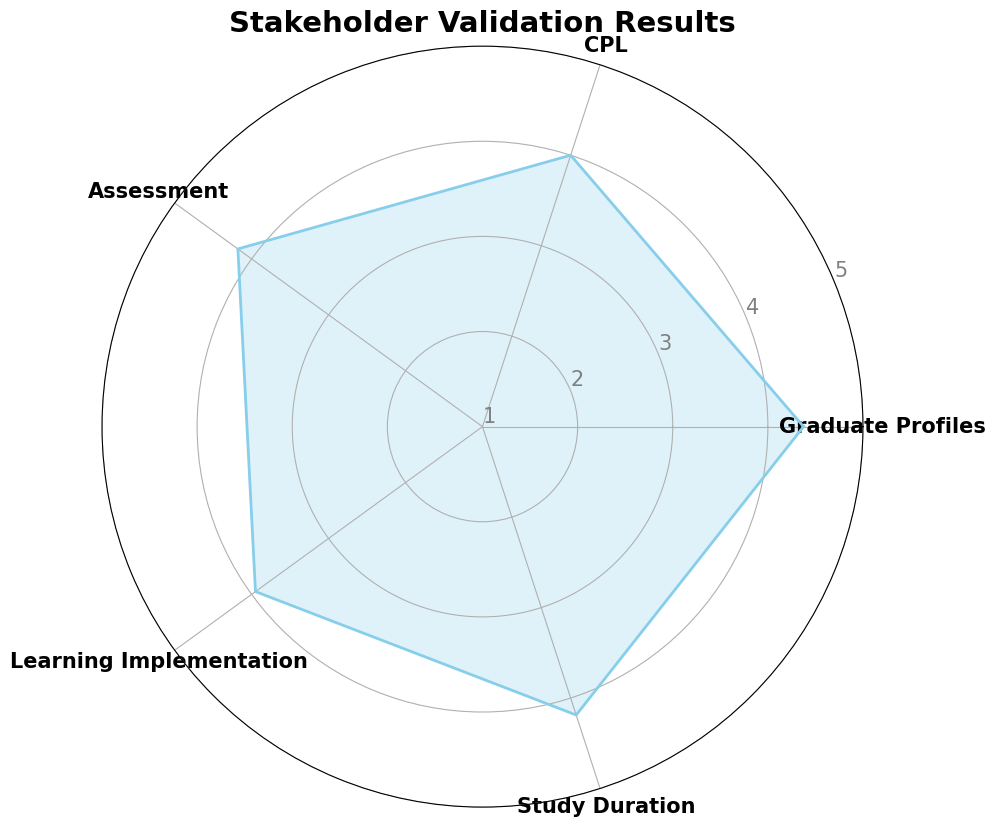

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Extract data for the spiderweb chart
aspects = aspect_statistics["Aspect"].tolist()
means = aspect_statistics["Mean"].tolist()

# Number of variables we're plotting
num_vars = len(aspects)

# Calculate the angle for each axis
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()

# The plot is circular, so we need to add the first value to the end to close the circle
means = means + [means[0]]
angles = angles + [angles[0]]
aspects = aspects + [aspects[0]] # For xticks

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

# Plot the data
ax.plot(angles, means, color='skyblue', linewidth=2)
ax.fill(angles, means, color='skyblue', alpha=0.25)

# Set the labels for each axis
ax.set_xticks(angles[:-1])
ax.set_xticklabels(aspect_statistics["Aspect"].tolist(), fontsize=15, fontweight="bold")

# Set y-limits and y-ticks
ax.set_ylim(1, 5) # Likert scale from 1 to 5
ax.set_yticks(np.arange(1, 6)) # Show ticks at 1, 2, 3, 4, 5
ax.set_yticklabels([str(i) for i in np.arange(1, 6)], color='gray', size=15)

# Add title
ax.set_title("Stakeholder Validation Results", va='bottom', fontsize=21, fontweight="bold")

plt.tight_layout()
plt.show()

# EXTERNAL VALIDATION

In [ ]:
# ============================================================
# INSPEKSI HASIL MACA 2020 VS 2021
# ============================================================

import os
import pandas as pd

# ============================================================
# PATH
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

BASE_2020 = "/content/drive/MyDrive/TA_Jennifer Felicia/SUMMARY_RESULTS_2020"
BASE_2021 = "/content/drive/MyDrive/TA_Jennifer Felicia/SUMMARY_RESULTS_2021"

# ============================================================
# FILE YANG AKAN DIPERIKSA
# ============================================================

files = [
    "summary_profile_final_summary.csv",

    "summary_cpl_final_summary.csv",
    "summary_cpl_final_validation.csv",

    "summary_assessment_final_summary.csv",

    "summary_learning_final_summary.csv",

    "summary_study_duration_statistics.csv",
    "summary_study_duration_status_distribution.csv"
]

# ============================================================
# FUNCTION
# ============================================================

def inspect_results(base_path, year):

    print("\n" + "=" * 100)
    print(f"HASIL MACA {year}")
    print("=" * 100)

    for filename in files:

        path = os.path.join(base_path, filename)

        print("\n" + "-" * 100)
        print(filename)
        print("-" * 100)

        if not os.path.exists(path):
            print("FILE TIDAK DITEMUKAN")
            continue

        df = pd.read_csv(path)

        print("Shape :", df.shape)
        print("Columns:")
        print(list(df.columns))

        print("\nData:")
        display(df.head(10))


# ============================================================
# RUN
# ============================================================

inspect_results(BASE_2020, 2020)
inspect_results(BASE_2021, 2021)

Mounted at /content/drive

HASIL MACA 2020

----------------------------------------------------------------------------------------------------
summary_profile_final_summary.csv
----------------------------------------------------------------------------------------------------
Shape : (2, 4)
Columns:
['Sub-Aspek', 'Average Similarity', 'Alignment (%)', 'Kondisi']

Data:


,Sub-Aspek,Average Similarity,Alignment (%),Kondisi
0,Visi/Misi ↔ Profil Lulusan,0.5963,40.00,Perlu Perbaikan
1,Profil Lulusan ↔ Posisi/Jabatan Lulusan,0.4356,28.57,Perlu Perbaikan



----------------------------------------------------------------------------------------------------
summary_cpl_final_summary.csv
----------------------------------------------------------------------------------------------------
Shape : (5, 3)
Columns:
['Sub Aspek', 'Average Similarity', 'Kondisi']

Data:


,Sub Aspek,Average Similarity,Kondisi
0,KKNI ↔ CPL,0.4621,Perlu Perbaikan
1,KKNI ↔ Mata Kuliah,0.6210,Cukup
2,CPL ↔ Kompetensi Industri,0.6748,Cukup
3,Mata Kuliah ↔ Kompetensi Industri,0.6119,Cukup
4,CPL ↔ Mata Kuliah,0.3955,Perlu Perbaikan



----------------------------------------------------------------------------------------------------
summary_cpl_final_validation.csv
----------------------------------------------------------------------------------------------------
Shape : (2, 4)
Columns:
['Skill Category', 'Mean_CPL_Similarity', 'Mean_Course_Similarity', 'Gap Tracer Study']

Data:


...

,Sub-Aspek,Nilai,Satuan,Kondisi
0,Kelengkapan Pelaksanaan Pertemuan,99.1100,%,Belum Lengkap
1,Kesesuaian Topik dengan RPS,0.5938,Similarity,Perlu Perbaikan



----------------------------------------------------------------------------------------------------
summary_study_duration_statistics.csv
----------------------------------------------------------------------------------------------------
Shape : (6, 2)
Columns:
['Metric', 'Value']

Data:


,Metric,Value
0,Jumlah Mahasiswa,4.0
1,Rata-rata Masa Studi (Tahun),4.0
2,Median Masa Studi (Tahun),4.0
3,Minimum Masa Studi (Tahun),4.0
4,Maksimum Masa Studi (Tahun),4.0
5,Standar Deviasi,0.0



----------------------------------------------------------------------------------------------------
summary_study_duration_status_distribution.csv
----------------------------------------------------------------------------------------------------
Shape : (3, 2)
Columns:
['Jumlah Mahasiswa', 'Persentase (%)']

Data:


,Jumlah Mahasiswa,Persentase (%)
0,0,0.0
1,4,100.0
2,0,0.0


In [ ]:
# ============================================================
# VISUALISASI PERBANDINGAN HASIL MACA
# TRACER STUDY 2020 VS 2021
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1. PATH
# ============================================================


BASE_2020 = "/content/drive/MyDrive/TA_Jennifer Felicia/SUMMARY_RESULTS_2020"
BASE_2021 = "/content/drive/MyDrive/TA_Jennifer Felicia/SUMMARY_RESULTS_2021"

OUTPUT_DIR = "/content/drive/MyDrive/TA_Jennifer Felicia/VISUALIZATION_VALIDATION"

os.makedirs(OUTPUT_DIR, exist_ok=True)


# ============================================================
# 2. FUNCTION LOAD DATA
# ============================================================

def load_summary(base_path):

    data = {}

    data["profile"] = pd.read_csv(
        os.path.join(base_path, "summary_profile_final_summary.csv")
    )

    data["cpl"] = pd.read_csv(
        os.path.join(base_path, "summary_cpl_final_summary.csv")
    )

    data["validation"] = pd.read_csv(
        os.path.join(base_path, "summary_cpl_final_validation.csv")
    )

    data["assessment"] = pd.read_csv(
        os.path.join(base_path, "summary_assessment_final_summary.csv")
    )

    data["learning"] = pd.read_csv(
        os.path.join(base_path, "summary_learning_final_summary.csv")
    )

    data["study_statistics"] = pd.read_csv(
        os.path.join(base_path, "summary_study_duration_statistics.csv")
    )

    data["study_status"] = pd.read_csv(
        os.path.join(base_path, "summary_study_duration_status_distribution.csv")
    )

    return data


# ============================================================
# 3. LOAD 2020 & 2021
# ============================================================

data_2020 = load_summary(BASE_2020)
data_2021 = load_summary(BASE_2021)

print("Data 2020 dan 2021 berhasil dimuat.")

Data 2020 dan 2021 berhasil dimuat.


In [ ]:
# ============================================================
# FUNCTION GET VALUE
# ============================================================

def get_value(df, column, row_name, name_column):

    row = df[df[name_column] == row_name]

    if len(row) == 0:
        raise ValueError(
            f"'{row_name}' tidak ditemukan pada kolom '{name_column}'"
        )

    return float(row.iloc[0][column])

# ============================================================
# FUNCTION: COMPARE TWO MACA RESULTS
# ============================================================

def calculate_absolute_gap(result_2020, result_2021):
    """
    Membandingkan hasil MACA 2020 dan 2021.

    Parameters
    ----------
    result_2020 : dict
        Hasil MACA dari Tracer Study 2020.

    result_2021 : dict
        Hasil MACA dari Tracer Study 2021.

    Returns
    -------
    comparison : dict
        Dictionary berisi nilai 2020, 2021,
        difference, dan absolute gap.
    """

    comparison = {}

    # Pastikan indikator yang dibandingkan sama
    common_labels = set(result_2020.keys()) & set(result_2021.keys())

    for label in result_2020:

        if label not in common_labels:
            continue

        value_2020 = result_2020[label]
        value_2021 = result_2021[label]

        difference = value_2021 - value_2020
        absolute_gap = abs(difference)

        comparison[label] = {
            "2020": value_2020,
            "2021": value_2021,
            "Difference": difference,
            "Absolute Gap": absolute_gap
        }

    return comparison

In [ ]:
# ============================================================
# RADAR / SPIDER WEB FUNCTION
# ============================================================

def create_radar(
    labels,
    values_2020,
    values_2021,
    title,
    filename,
    max_value=100
):

    N = len(labels)

    angles = np.linspace(
        0,
        2 * np.pi,
        N,
        endpoint=False
    ).tolist()

    # Tutup polygon
    angles += angles[:1]

    values_2020 = list(values_2020) + [values_2020[0]]
    values_2021 = list(values_2021) + [values_2021[0]]

    fig, ax = plt.subplots(
        figsize=(8, 8),
        subplot_kw=dict(polar=True)
    )

    # 2020
    ax.plot(
        angles,
        values_2020,
        linewidth=5,
        label="Tracer Study 2020",
        color='skyblue'
    )

    ax.fill(
        angles,
        values_2020,
        alpha=0.15,
        color='skyblue'
    )

    # 2021
    ax.plot(
        angles,
        values_2021,
        linewidth=3,
        label="Tracer Study 2021",
        color='lightcoral'
    )

    ax.fill(
        angles,
        values_2021,
        alpha=0.15,
        color='lightcoral'
    )

    # Label
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=50) # Fontsize changed to 18

    # Scale
    ax.set_ylim(0, max_value)
    ax.set_yticks([20, 40, 60, 80, 100])
    ax.set_yticklabels(
        ["20", "40", "60", "80", "100"],
        fontsize=15
    )

    ax.set_title(
        title,
        fontsize=21,
        fontweight="bold",
        pad=25
    )

    ax.legend(
        loc="upper right",
        bbox_to_anchor=(1.50, 1.10),
        fontsize=18
    )

    plt.tight_layout()

    output_path = os.path.join(
        OUTPUT_DIR,
        filename
    )

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(f"Saved: {output_path}")

In [ ]:
# ============================================================
# DIVERGING BAR CHART
# ============================================================

def create_gap_chart(
    labels,
    values_2020,
    values_2021,
    title,
    filename
):

    x = np.arange(len(labels))

    width = 0.35

    fig, ax = plt.subplots(
        figsize=(9, 6)
    )

    bars_2020 = ax.bar(
        x - width/2,
        values_2020,
        width,
        label="Tracer Study 2020",
        color='skyblue'
    )

    bars_2021 = ax.bar(
        x + width/2,
        values_2021,
        width,
        label="Tracer Study 2021",
        color='lightcoral'
    )

    # Garis nol
    ax.axhline(
        0,
        linewidth=1
    )

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=21, fontweight="bold")

    ax.set_ylabel(
        "Tracer Study Gap",
        fontsize=18
    )

    ax.set_title(
        title,
        fontsize=21,
        fontweight="bold"
    )

    ax.legend()

    # Label nilai
    for bars in [bars_2020, bars_2021]:

        for bar in bars:

            height = bar.get_height()

            offset = 0.005 if height >= 0 else -0.005

            va = "bottom" if height >= 0 else "top"

            ax.text(
                bar.get_x() + bar.get_width()/2,
                height + offset,
                f"{height:.3f}",
                ha="center",
                va=va,
                fontsize=15
            )

    # Tambahkan grid
    ax.grid(
        axis="y",
        alpha=0.3
    )

    plt.tight_layout()

    output_path = os.path.join(
        OUTPUT_DIR,
        filename
    )

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(f"Saved: {output_path}")


## PROFIL LULUSAN

In [ ]:
# ============================================================
# MODUL 1
# PROFIL LULUSAN
# ============================================================

def extract_modul_1(data):

    df = data["profile"]

    values = {}

    values["Visi/Misi ↔ Profil Lulusan"] = (
        get_value(
            df,
            "Average Similarity",
            "Visi/Misi ↔ Profil Lulusan",
            "Sub-Aspek"
        ) * 100
    )

    values["Profil Lulusan ↔ Posisi/Jabatan Lulusan"] = (
        get_value(
            df,
            "Average Similarity",
            "Profil Lulusan ↔ Posisi/Jabatan Lulusan",
            "Sub-Aspek"
        ) * 100
    )

    return values


modul1_2020 = extract_modul_1(data_2020)
modul1_2021 = extract_modul_1(data_2021)

print("MODUL 1")
print("2020:", modul1_2020)
print("2021:", modul1_2021)

MODUL 1
2020: {'Visi/Misi ↔ Profil Lulusan': 59.630000591278076, 'Profil Lulusan ↔ Posisi/Jabatan Lulusan': 43.56}
2021: {'Visi/Misi ↔ Profil Lulusan': 59.630000591278076, 'Profil Lulusan ↔ Posisi/Jabatan Lulusan': 60.33}


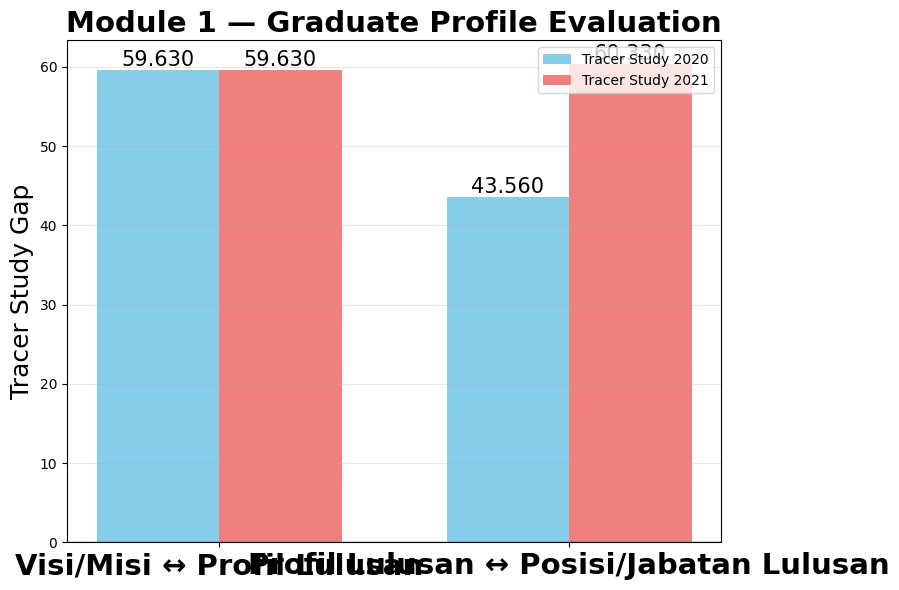

Saved: /content/drive/MyDrive/TA_Jennifer Felicia/VISUALIZATION_VALIDATION/grouped_bar_modul_1_2020_vs_2021.png


In [ ]:
# ============================================================
# RADAR MODUL 1
# ============================================================

labels = list(modul1_2020.keys())

values_2020 = list(modul1_2020.values())
values_2021 = list(modul1_2021.values())

create_gap_chart(
    labels,
    values_2020,
    values_2021,
    title="Module 1 — Graduate Profile Evaluation",
    filename="grouped_bar_modul_1_2020_vs_2021.png"
)

## CPL

MODUL 2

2020:
KKNI ↔ CPL: 46.21
KKNI ↔ Mata Kuliah: 62.10
CPL ↔ Kompetensi Industri: 67.48
Mata Kuliah ↔ Kompetensi Industri: 61.19
CPL ↔ Mata Kuliah: 39.55
Hard Skill Gap Alignment: 96.43
Soft Skill Gap Alignment: 98.57

2021:
KKNI ↔ CPL: 46.21
KKNI ↔ Mata Kuliah: 62.10
CPL ↔ Kompetensi Industri: 67.48
Mata Kuliah ↔ Kompetensi Industri: 61.19
CPL ↔ Mata Kuliah: 39.55
Hard Skill Gap Alignment: 96.88
Soft Skill Gap Alignment: 100.00


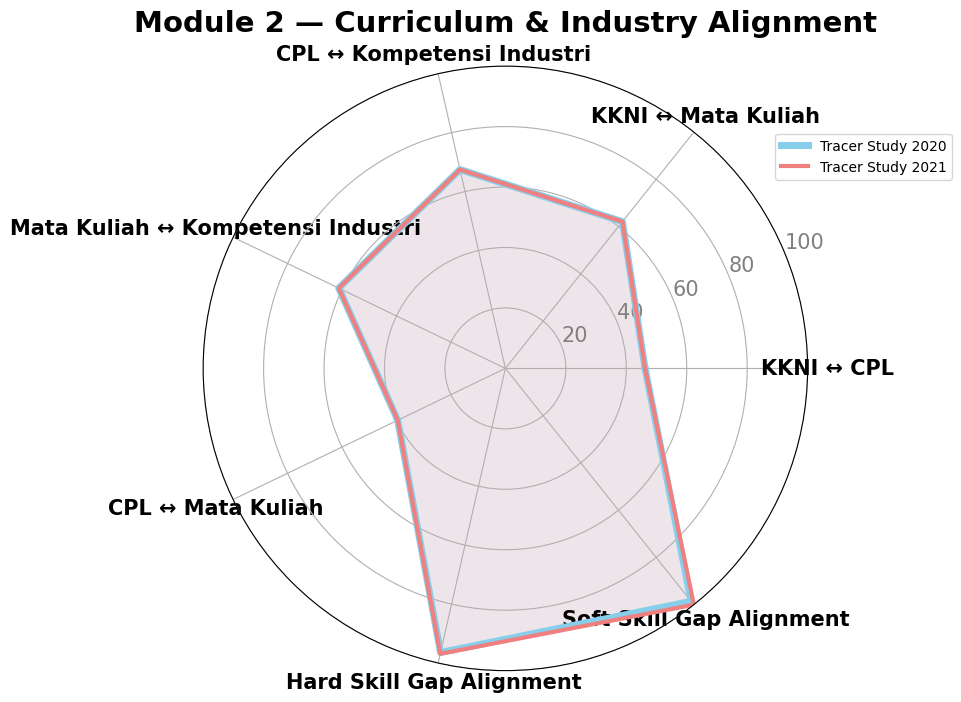

Saved: /content/drive/MyDrive/TA_Jennifer Felicia/VISUALIZATION_VALIDATION/radar_modul_2_2020_vs_2021.png


In [ ]:
# ============================================================
# MODUL 2
# CURRICULUM / INDUSTRY ALIGNMENT
# + SOFT SKILL TRACER STUDY GAP
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

def create_radar(
    labels,
    values_2020,
    values_2021,
    title,
    filename,
    max_value=100
):

    N = len(labels)

    angles = np.linspace(
        0,
        2 * np.pi,
        N,
        endpoint=False
    ).tolist()

    # Tutup polygon
    angles += angles[:1]

    values_2020 = list(values_2020) + [values_2020[0]]
    values_2021 = list(values_2021) + [values_2021[0]]

    fig, ax = plt.subplots(
        figsize=(10, 10), # Ukuran figure ditingkatkan
        subplot_kw=dict(polar=True)
    )

    # 2020
    ax.plot(
        angles,
        values_2020,
        linewidth=5,
        label="Tracer Study 2020",
        color='skyblue'
    )

    ax.fill(
        angles,
        values_2020,
        alpha=0.15,
        color='skyblue'
    )

    # 2021
    ax.plot(
        angles,
        values_2021,
        linewidth=3,
        label="Tracer Study 2021",
        color='lightcoral'
    )

    ax.fill(
        angles,
        values_2021,
        alpha=0.15,
        color='lightcoral'
    )

    # Label
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=15,fontweight="bold")

    # Scale
    ax.set_ylim(0, max_value)
    ax.set_yticks([20, 40, 60, 80, 100])
    ax.set_yticklabels(
        [str(i) for i in np.arange(20, 101, 20)], # Menyesuaikan label Y
        color='gray',
        size=15
    )

    ax.set_title(
        title,
        fontsize=21,
        fontweight="bold",
        pad=25
    )

    ax.legend(
        loc="upper right",
        bbox_to_anchor=(1.25, 0.90) # Legenda dipindahkan agar tidak menutupi teks
    )

    plt.tight_layout()

    output_path = os.path.join(
        OUTPUT_DIR,
        filename
    )

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(f"Saved: {output_path}")

MODUL_2_LABELS = [
    "KKNI ↔ CPL",
    "KKNI ↔ Mata Kuliah",
    "CPL ↔ Kompetensi Industri",
    "Mata Kuliah ↔ Kompetensi Industri",
    "CPL ↔ Mata Kuliah",
    "Hard Skill Gap Alignment",
    "Soft Skill Gap Alignment"
]


def extract_modul_2(data):

    # --------------------------------------------------------
    # Data Module 2A
    # --------------------------------------------------------
    df_cpl_summary = data["cpl"]

    # --------------------------------------------------------
    # Data Module 2B
    # --------------------------------------------------------
    df_validation_summary = data["validation"]

    # Initialize a list to hold values in the specific order defined by MODUL_2_LABELS
    ordered_values = []

    # --------------------------------------------------------
    # 1–5. Curriculum / Industry Alignment
    # --------------------------------------------------------

    alignment_labels = [
        "KKNI ↔ CPL",
        "KKNI ↔ Mata Kuliah",
        "CPL ↔ Kompetensi Industri",
        "Mata Kuliah ↔ Kompetensi Industri",
        "CPL ↔ Mata Kuliah"
    ]

    for label in alignment_labels:

        similarity = get_value(
            df_cpl_summary,
            "Average Similarity",
            label,
            "Sub Aspek"
        )

        # Similarity 0–1 → percentage 0–100
        ordered_values.append(similarity * 100)

    # --------------------------------------------------------
    # 6. Hard Skill — Tracer Study Gap
    # --------------------------------------------------------

    raw_gap_hard = get_value(
        df_validation_summary,
        "Gap Tracer Study",
        "Hard Skill",
        "Skill Category"
    )

    # Gap berasal dari skala Likert 1–5.
    # Maximum possible absolute gap = 4.
    #
    # Gap = 0       → 100% alignment
    # |Gap| = 4     → 0% alignment

    gap_alignment_hard = (
        1 - (abs(raw_gap_hard) / 4)
    ) * 100

    ordered_values.append(gap_alignment_hard)

    # --------------------------------------------------------
    # 7. Soft Skill — Tracer Study Gap
    # --------------------------------------------------------

    raw_gap_soft = get_value(
        df_validation_summary,
        "Gap Tracer Study",
        "Soft Skill",
        "Skill Category"
    )

    gap_alignment_soft = (
        1 - (abs(raw_gap_soft) / 4)
    ) * 100

    ordered_values.append(gap_alignment_soft)

    # Return as a dictionary for consistency with previous print statements,
    # but the order is guaranteed by MODUL_2_LABELS and ordered_values.
    return dict(zip(MODUL_2_LABELS, ordered_values))


# ============================================================
# EXTRACT 2020 & 2021
# ============================================================

modul2_2020 = extract_modul_2(data_2020)
modul2_2021 = extract_modul_2(data_2021)


print("MODUL 2")
print("\n2020:")
for key, value in modul2_2020.items():
    print(f"{key}: {value:.2f}")

print("\n2021:")
for key, value in modul2_2021.items():
    print(f"{key}: {value:.2f}")


# ============================================================
# RADAR MODUL 2
# ============================================================

create_radar(
    MODUL_2_LABELS,
    list(modul2_2020.values()),
    list(modul2_2021.values()),
    title="Module 2 — Curriculum & Industry Alignment",
    filename="radar_modul_2_2020_vs_2021.png"
)


## ASESMEN PEMBELAJARAN

MODUL 3
2020: {'Student Output': 87.25, 'Graduation Compliance': 71.42857142857143, 'CPL Attainment': 88.0}
2021: {'Student Output': 91.25, 'Graduation Compliance': 0.0, 'CPL Attainment': 91.75}


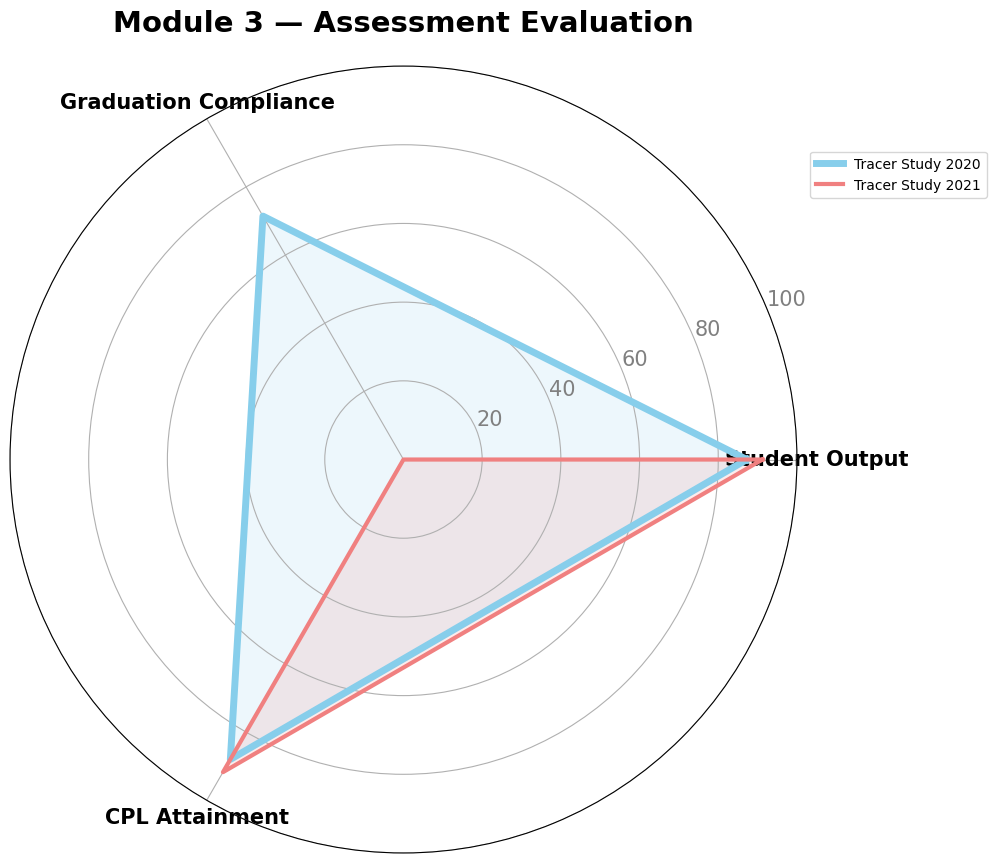

Saved: /content/drive/MyDrive/TA_Jennifer Felicia/VISUALIZATION_VALIDATION/radar_modul_3_2020_vs_2021.png


In [ ]:
# ============================================================
# MODUL 3
# ASSESSMENT EVALUATION
# ============================================================

MODUL_3_LABELS = [
    "Student Output",
    "Graduation Compliance",
    "CPL Attainment"
]


def get_assessment_value(
    df,
    indicator
):

    row = df[df["Indikator"] == indicator]

    if len(row) == 0:
        raise ValueError(
            f"Indikator '{indicator}' tidak ditemukan."
        )

    return float(row.iloc[0]["Nilai"])


def extract_modul_3(data):

    df = data["assessment"]

    # --------------------------------------------------------
    # 1. Student Output
    # --------------------------------------------------------

    student_output = get_assessment_value(
        df,
        "Rata-rata Nilai"
    )

    student_output_score = (
        student_output / 4
    ) * 100

    # --------------------------------------------------------
    # 2. Mahasiswa Belum Memenuhi Persyaratan
    # --------------------------------------------------------

    not_met = get_assessment_value(
        df,
        "Mahasiswa Belum Memenuhi Persyaratan"
    )

    # Jumlah mahasiswa total
    study_stats = data["study_statistics"]

    total_students = float(
        study_stats.loc[
            study_stats["Metric"] == "Jumlah Mahasiswa",
            "Value"
        ].iloc[0]
    )

    graduation_compliance = (
        1 - (not_met / total_students)
    ) * 100

    # --------------------------------------------------------
    # 3. CPL Attainment
    # --------------------------------------------------------

    cpl_score = get_assessment_value(
        df,
        "Rata-rata Nilai CPL"
    )

    cpl_attainment_score = (
        cpl_score / 4
    ) * 100

    return {
        "Student Output": student_output_score,
        "Graduation Compliance": graduation_compliance,
        "CPL Attainment": cpl_attainment_score
    }


modul3_2020 = extract_modul_3(data_2020)
modul3_2021 = extract_modul_3(data_2021)

print("MODUL 3")
print("2020:", modul3_2020)
print("2021:", modul3_2021)


# ============================================================
# RADAR MODUL 3
# ============================================================

create_radar(
    MODUL_3_LABELS,
    list(modul3_2020.values()),
    list(modul3_2021.values()),
    title="Module 3 — Assessment Evaluation",
    filename="radar_modul_3_2020_vs_2021.png"
)

## PELAKSANAAN PEMBELAJARAN

MODUL 4
2020: {'Kelengkapan Pertemuan': 99.11, 'Kesesuaian Topik dengan RPS': 59.38}
2021: {'Kelengkapan Pertemuan': 99.11, 'Kesesuaian Topik dengan RPS': 59.38}


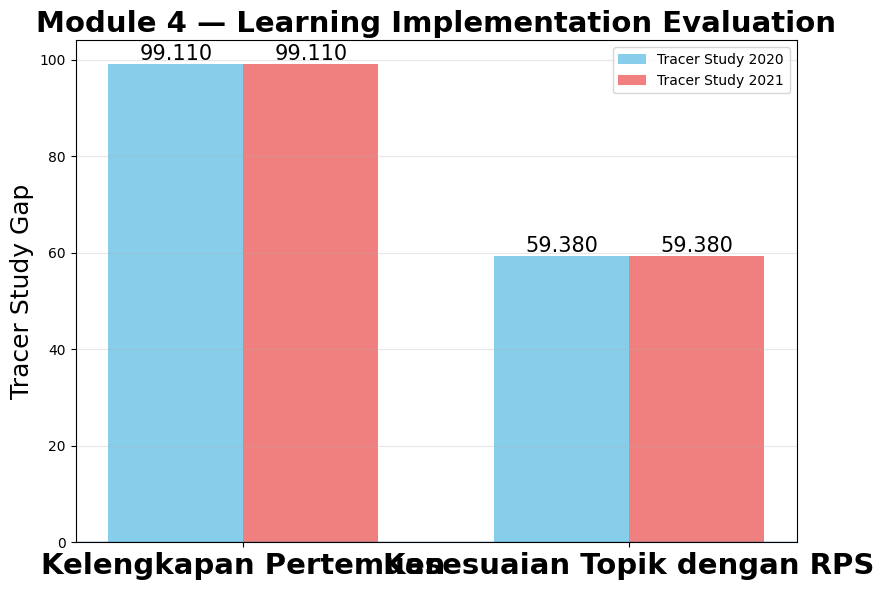

Saved: /content/drive/MyDrive/TA_Jennifer Felicia/VISUALIZATION_VALIDATION/grouped_bar_modul_4_2020_vs_2021.png


In [ ]:
# ============================================================
# MODUL 4
# LEARNING IMPLEMENTATION
# ============================================================

MODUL_4_LABELS = [
    "Kelengkapan Pertemuan",
    "Kesesuaian Topik dengan RPS"
]


def extract_modul_4(data):

    df = data["learning"]

    values = {}

    # --------------------------------------------------------
    # Kelengkapan Pertemuan
    # --------------------------------------------------------

    row = df[
        df["Sub-Aspek"] ==
        "Kelengkapan Pelaksanaan Pertemuan"
    ]

    values["Kelengkapan Pertemuan"] = float(
        row.iloc[0]["Nilai"]
    )

    # --------------------------------------------------------
    # Kesesuaian Topik
    # --------------------------------------------------------

    row = df[
        df["Sub-Aspek"] ==
        "Kesesuaian Topik dengan RPS"
    ]

    similarity = float(
        row.iloc[0]["Nilai"]
    )

    values["Kesesuaian Topik dengan RPS"] = (
        similarity * 100
    )

    return values


modul4_2020 = extract_modul_4(data_2020)
modul4_2021 = extract_modul_4(data_2021)

print("MODUL 4")
print("2020:", modul4_2020)
print("2021:", modul4_2021)

# ============================================================
# RADAR MODUL 4
# ============================================================

create_gap_chart(
    MODUL_4_LABELS,
    list(modul4_2020.values()),
    list(modul4_2021.values()),
    title="Module 4 — Learning Implementation Evaluation",
    filename="grouped_bar_modul_4_2020_vs_2021.png"
)

## MASA STUDI

MODUL 5
2020: 3.86 tahun → 100.00
2021: 4.00 tahun → 100.00
MODUL 5
2020: [14.29, 85.71, 0.0]
2021: [0.0, 100.0, 0.0]


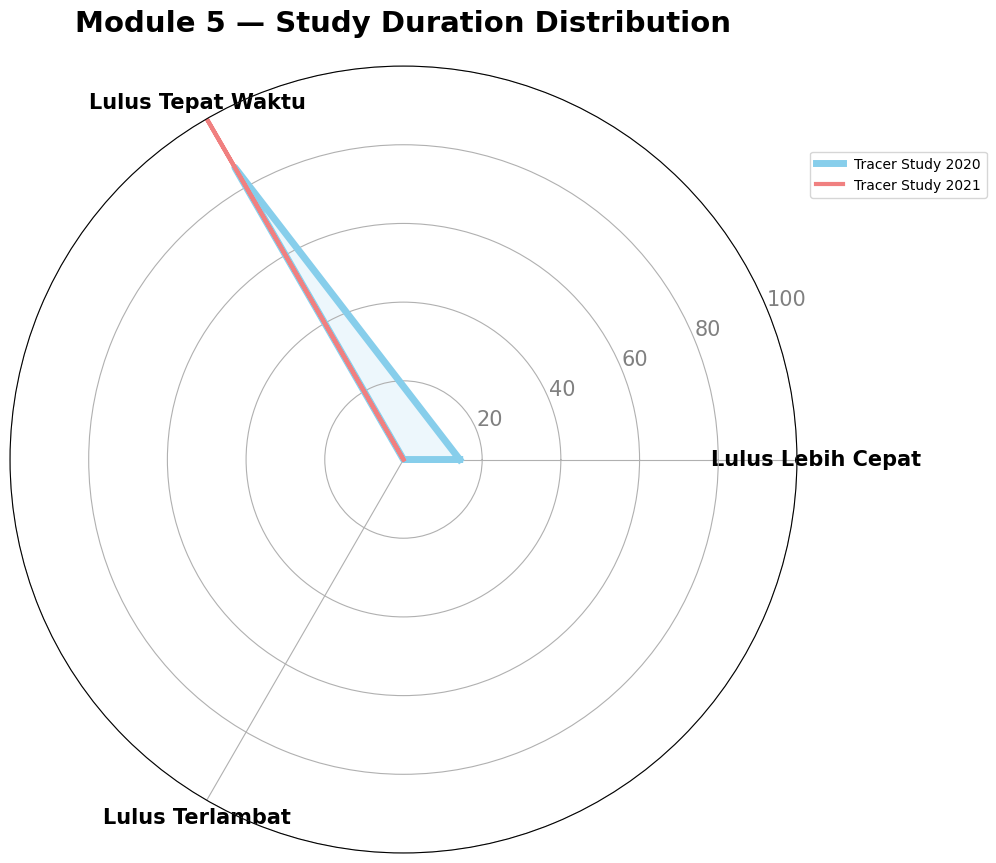

Saved: /content/drive/MyDrive/TA_Jennifer Felicia/VISUALIZATION_VALIDATION/radar_modul_5_2020_vs_2021.png


In [ ]:
# ============================================================
# MODUL 5
# STUDY DURATION STATUS DISTRIBUTION
# ============================================================

# ============================================================
# MODUL 5
# STUDY DURATION
# ============================================================

def get_average_study_duration(data):

    df = data["study_statistics"]

    row = df[
        df["Metric"] ==
        "Rata-rata Masa Studi (Tahun)"
    ]

    return float(
        row.iloc[0]["Value"]
    )


def study_duration_compliance(duration):

    STANDARD = 4.0

    if duration <= STANDARD:
        return 100.0

    # Penalti proporsional jika melebihi standar
    return (
        STANDARD / duration
    ) * 100


duration_2020 = get_average_study_duration(data_2020)
duration_2021 = get_average_study_duration(data_2021)

compliance_2020 = study_duration_compliance(
    duration_2020
)

compliance_2021 = study_duration_compliance(
    duration_2021
)

print("MODUL 5")
print(f"2020: {duration_2020:.2f} tahun → {compliance_2020:.2f}")
print(f"2021: {duration_2021:.2f} tahun → {compliance_2021:.2f}")

def extract_modul_5(data):

    df = data["study_status"].copy()

    # Pastikan urutan berdasarkan index/status asli
    df = df.reset_index(drop=True)

    return df["Persentase (%)"].astype(float).tolist()


modul5_2020 = extract_modul_5(data_2020)
modul5_2021 = extract_modul_5(data_2021)

print("MODUL 5")
print("2020:", modul5_2020)
print("2021:", modul5_2021)

MODUL_5_LABELS = [
    "Lulus Lebih Cepat",
    "Lulus Tepat Waktu",
    "Lulus Terlambat"
]

# ============================================================
# RADAR MODUL 5
# ============================================================

create_radar(
    MODUL_5_LABELS,
    modul5_2020,
    modul5_2021,
    title="Module 5 — Study Duration Distribution",
    filename="radar_modul_5_2020_vs_2021.png"
)

## REKAP

,Modul,Sub Modul,Indikator,2020,2021,Perubahan,Absolute Gap
0,Modul 1,Profil Lulusan,Visi/Misi ↔ Profil Lulusan,59.6300,59.630,0.0000,0.0000
1,Modul 1,Profil Lulusan,Profil Lulusan ↔ Posisi/Jabatan Lulusan,43.5600,60.330,16.7700,16.7700
2,Modul 2,Curriculum & Industry Alignment,KKNI ↔ CPL,46.2100,46.210,0.0000,0.0000
3,Modul 2,Curriculum & Industry Alignment,KKNI ↔ Mata Kuliah,62.1000,62.100,0.0000,0.0000
4,Modul 2,Curriculum & Industry Alignment,CPL ↔ Kompetensi Industri,67.4800,67.480,0.0000,0.0000
5,Modul 2,Curriculum & Industry Alignment,Mata Kuliah ↔ Kompetensi Industri,61.1900,61.190,0.0000,0.0000
6,Modul 2,Curriculum & Industry Alignment,CPL ↔ Mata Kuliah,39.5500,39.550,0.0000,0.0000
7,Modul 2,Curriculum & Industry Alignment,Hard Skill Gap Alignment,96.4286,96.875,0.4464,0.4464
8,Modul 2,Curriculum & Industry Alignment,Soft Skill Gap Alignment,98.5714,100.000,1.4286,1.4286
9,Modul 3,Assessment,Student Output,87.2500,91.250,4.0000,4.0000



GENERATING RADAR CHART: AVERAGE PER MODUL


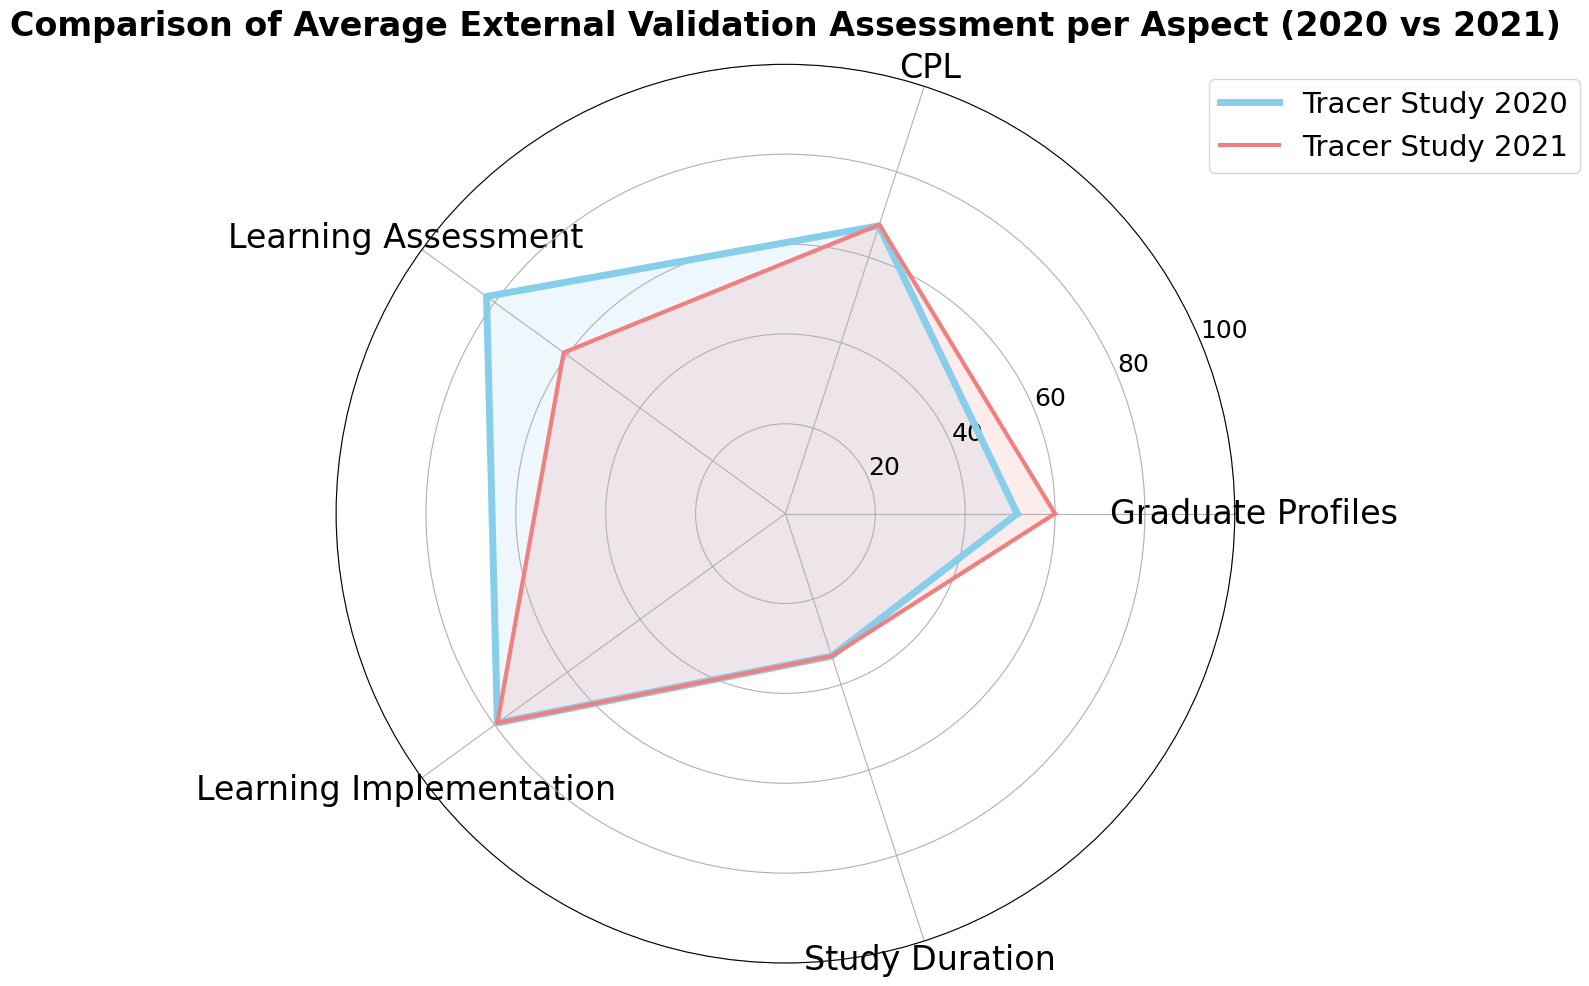

Saved: /content/drive/MyDrive/TA_Jennifer Felicia/VISUALIZATION_VALIDATION/radar_average_aspects_2020_vs_2021.png

Radar chart generated for average values per module.


In [ ]:
# ============================================================
# REKAP SELURUH NILAI VISUALISASI
# ============================================================

comparison_data = []


# ------------------------------------------------------------
# MODUL 1
# ------------------------------------------------------------

for indicator in modul1_2020:

    comparison_data.append({
        "Modul": "Modul 1",
        "Sub Modul": "Profil Lulusan",
        "Indikator": indicator,
        "2020": modul1_2020[indicator],
        "2021": modul1_2021[indicator]
    })


# ------------------------------------------------------------
# MODUL 2
# Curriculum & Industry Alignment
# + Soft Skill Tracer Study Gap
# ------------------------------------------------------------

for indicator in modul2_2020:

    comparison_data.append({
        "Modul": "Modul 2",
        "Sub Modul": "Curriculum & Industry Alignment",
        "Indikator": indicator,
        "2020": modul2_2020[indicator],
        "2021": modul2_2021[indicator]
    })


# ------------------------------------------------------------
# MODUL 3
# ------------------------------------------------------------

for indicator in modul3_2020:

    comparison_data.append({
        "Modul": "Modul 3",
        "Sub Modul": "Assessment",
        "Indikator": indicator,
        "2020": modul3_2020[indicator],
        "2021": modul3_2021[indicator]
    })


# ------------------------------------------------------------
# MODUL 4
# ------------------------------------------------------------

for indicator in modul4_2020:

    comparison_data.append({
        "Modul": "Modul 4",
        "Sub Modul": "Learning Implementation",
        "Indikator": indicator,
        "2020": modul4_2020[indicator],
        "2021": modul4_2021[indicator]
    })


# ------------------------------------------------------------
# MODUL 5
# ------------------------------------------------------------

for i, indicator_label in enumerate(MODUL_5_LABELS):

    comparison_data.append({
        "Modul": "Modul 5",
        "Sub Modul": "Study Duration Status",
        "Indikator": indicator_label,
        "2020": modul5_2020[i],
        "2021": modul5_2021[i]
    })


# ============================================================
# DATAFRAME
# ============================================================

df_comparison = pd.DataFrame(comparison_data)


# ============================================================
# HITUNG PERUBAHAN
# ============================================================

# Arah perubahan:
# positif  = meningkat
# negatif  = menurun
df_comparison["Perubahan"] = (
    df_comparison["2021"] -
    df_comparison["2020"]
)


# Besar perbedaan tanpa memperhatikan arah
df_comparison["Absolute Gap"] = (
    df_comparison["Perubahan"].abs()
)


# ============================================================
# PEMBULATAN
# ============================================================

df_comparison["2020"] = df_comparison["2020"].round(4)
df_comparison["2021"] = df_comparison["2021"].round(4)
df_comparison["Perubahan"] = df_comparison["Perubahan"].round(4)
df_comparison["Absolute Gap"] = (
    df_comparison["Absolute Gap"].round(4)
)


# ============================================================
# DISPLAY
# ============================================================

display(df_comparison)

# ============================================================
# RADAR CHART: AVERAGE PER MODUL
# ============================================================

print("\n" + "=" * 80)
print("GENERATING RADAR CHART: AVERAGE PER MODUL")
print("=" * 80)

# Redefine create_radar function with updated legend properties
def create_radar(
    labels,
    values_2020,
    values_2021,
    title,
    filename,
    max_value=100
):
    import matplotlib.pyplot as plt
    import numpy as np
    import os

    N = len(labels)

    angles = np.linspace(
        0,
        2 * np.pi,
        N,
        endpoint=False
    ).tolist()

    # Tutup polygon
    angles += angles[:1]

    values_2020 = list(values_2020) + [values_2020[0]]
    values_2021 = list(values_2021) + [values_2021[0]]

    fig, ax = plt.subplots(
        figsize=(20,10),
        subplot_kw=dict(polar=True)
    )

    # 2020
    ax.plot(
        angles,
        values_2020,
        linewidth=5,
        label="Tracer Study 2020",
        color='skyblue'
    )

    ax.fill(
        angles,
        values_2020,
        alpha=0.15,
        color='skyblue'
    )

    # 2021
    ax.plot(
        angles,
        values_2021,
        linewidth=3,
        label="Tracer Study 2021",
        color='lightcoral'
    )

    ax.fill(
        angles,
        values_2021,
        alpha=0.15,
        color='lightcoral'
    )

    # Label
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=24) # Increased x-axis label font size

    # Scale
    ax.set_ylim(0, max_value)
    ax.set_yticks([20, 40, 60, 80, 100])
    ax.set_yticklabels(
        ["20", "40", "60", "80", "100"],
        fontsize=18 # Increased y-axis label font size
    )

    ax.set_title(
        title,
        fontsize=24,
        fontweight="bold",
        pad=21
    )

    ax.legend(
        loc="upper right",
        bbox_to_anchor=(1.4, 1.0), # Adjusted bbox_to_anchor for larger legend
        fontsize=21 # Increased legend font size
    )

    plt.tight_layout()

    output_path = os.path.join(
        OUTPUT_DIR,
        filename
    )

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(f"Saved: {output_path}")

# Group by 'Modul' and calculate the mean for '2020' and '2021'
df_modul_avg = df_comparison.groupby('Modul')[['2020', '2021']].mean().reset_index()

# Extract labels and values
radar_labels = [
    "Graduate Profiles",
    "CPL",
    "Learning Assessment",
    "Learning Implementation",
    "Study Duration"
]

# Ensure the order of average values matches the custom labels
modul_avg_dict = df_modul_avg.set_index('Modul').to_dict('index')

radar_values_2020 = [
    modul_avg_dict['Modul 1']['2020'],
    modul_avg_dict['Modul 2']['2020'],
    modul_avg_dict['Modul 3']['2020'],
    modul_avg_dict['Modul 4']['2020'],
    modul_avg_dict['Modul 5']['2020']
]

radar_values_2021 = [
    modul_avg_dict['Modul 1']['2021'],
    modul_avg_dict['Modul 2']['2021'],
    modul_avg_dict['Modul 3']['2021'],
    modul_avg_dict['Modul 4']['2021'],
    modul_avg_dict['Modul 5']['2021']
]

# Define title and filename
radar_title = "Comparison of Average External Validation Assessment per Aspect (2020 vs 2021)"
radar_filename = "radar_average_aspects_2020_vs_2021.png"

# Call the create_radar function
create_radar(
    labels=radar_labels,
    values_2020=radar_values_2020,
    values_2021=radar_values_2021,
    title=radar_title,
    filename=radar_filename,
    max_value=100
)

print("\nRadar chart generated for average values per module.")